# Analysis of NTK Eigenvalue and Eigenvector Distributions

We analyze the distributions of eigenvalues and eigenvectors of the NTK matrix.

In [ ]:
import os
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
from tqdm import tqdm
import csv  # we use csv instead of pandas
from collections import defaultdict  # we use defaultdict for grouping
import json  # we add json for storing test results
import seaborn as sns  # we use seaborn for enhanced heatmap visualizations

In [ ]:
import dotenv
dotenv.load_dotenv()
PROJECT_ROOT = os.getenv("PROJECT_ROOT")
PATH_TO_DATA = os.path.join(PROJECT_ROOT, "experiments", "data", "eigen")
PATH_TO_PLOTS = os.path.join(PROJECT_ROOT, "experiments", "plots", "eigen", "entropy")

# we create necessary directories
os.makedirs(PATH_TO_PLOTS, exist_ok=True)

In [ ]:
def get_config_from_filename(filename):
    """we extract configuration parameters from filename"""
    parts = filename.replace(".npy", "").split("_")
    N = int(parts[-4][1:])
    D = int(parts[-3][1:])
    M = int(parts[-2][1:])
    L = int(parts[-1][1:])
    return N, D, M, L

def load_experiment_data(N, D_IN, M, L):
    """we load eigenvalues and eigenvectors data for a specific configuration"""
    filename_eigenvalues = f"values/ntk_eigenvalues_N{N}_D{D_IN}_M{M}_L{L}.npy"
    filename_eigenvectors = f"vectors/ntk_eigenvectors_N{N}_D{D_IN}_M{M}_L{L}.npy"
    
    eigenvalues_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvalues), allow_pickle=True).item()
    eigenvectors_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvectors), allow_pickle=True).item()
    
    return eigenvalues_data, eigenvectors_data

In [ ]:

def get_ordinal_suffix(n):
    """we get the ordinal suffix for a number (1st, 2nd, 3rd, 4th, etc.)"""
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

def compute_entropy(eigenvectors, eigenvector_order, N, D_IN, M, L, output_dir):
    """
    We compute the entropy of the distribution for each coordinate of a specific eigenvector order.
    """
    
    try: # we get the eigenvectors for the specific order
        selected_eigenvectors = eigenvectors[:, eigenvector_order, :] # shape (n_experiments, dimension)
    except IndexError:
        print(f"Warning: Could not extract eigenvector {eigenvector_order+1} for config N{N}_D{D_IN}_M{M}_L{L}.")
        return None

    n_experiments, dimension = selected_eigenvectors.shape
    
    coordinate_entropies = []
    for i in range(dimension): # we compute entropy coordinate-wise
        coordinate_values = selected_eigenvectors[:, i]
        
        hist, bin_edges = np.histogram(coordinate_values, bins='auto', density=True)
        bin_width = bin_edges[1] - bin_edges[0]
        
        # we normalize
        probabilities = hist * bin_width
        probabilities = probabilities[probabilities > 0] # we remove zero probabilities
        
        entropy = -np.sum(probabilities * np.log2(probabilities))
        coordinate_entropies.append(entropy)
    
    return coordinate_entropies

def analyze_entropy(eigenvectors, N, D_IN, M, L, output_dir):
    """
    Analyze entropy distributions across all eigenvector orders.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    print(f"Computing entropy for all eigenvector distributions - N{N}_D{D_IN}_M{M}_L{L}")
    
    # we compute entropy for each eigenvector order
    all_entropies = []
    for k in range(n_vectors):
        entropies = compute_entropy(eigenvectors, k, N, D_IN, M, L, output_dir)
        if entropies is not None:
            all_entropies.append(entropies)
    
    all_entropies = np.array(all_entropies) # shape (n_vectors, dimension)
    
    # viz creation
    plt.figure(figsize=(12, 8))
    
    # we plot entropy for each eigenvector order
    eigenvector_indices = list(range(1, n_vectors + 1))
    coordinate_indices = list(range(1, dimension + 1))
    
    plt.subplot(2, 1, 1)
    mean_entropies = np.mean(all_entropies, axis=1)
    std_entropies = np.std(all_entropies, axis=1)
    
    plt.errorbar(eigenvector_indices, mean_entropies, yerr=std_entropies,
                fmt='o-', capsize=5, linewidth=2, markersize=6)
    plt.title(f'Mean Entropy Across Coordinates\nConfig N{N}_D{D_IN}_M{M}_L{L}')
    plt.xlabel('Eigenvector Order')
    plt.ylabel('Mean Entropy (bits)')
    plt.grid(True)
    
    plt.subplot(2, 1, 2)
    plt.imshow(all_entropies.T, aspect='auto', cmap='viridis')
    plt.colorbar(label='Entropy (bits)')
    plt.title('Entropy Heatmap')
    plt.xlabel('Eigenvector Order')
    plt.ylabel('Coordinate Index')
    
    plt.tight_layout()
    
    # Save plot
    entropy_filename = os.path.join(output_dir, f'entropy_analysis_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(entropy_filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Print statistics
    print(f"\nEntropy Statistics:")
    print(f"  Overall mean entropy: {np.mean(mean_entropies):.4f} ± {np.mean(std_entropies):.4f} bits")
    print(f"  Max entropy: {np.max(all_entropies):.4f} bits")
    print(f"  Min entropy: {np.min(all_entropies):.4f} bits")
    
    # Find most and least random eigenvectors
    most_random_idx = np.argmax(mean_entropies)
    least_random_idx = np.argmin(mean_entropies)
    
    print(f"\nMost random eigenvector: {get_ordinal_suffix(most_random_idx + 1)}")
    print(f"  Mean entropy: {mean_entropies[most_random_idx]:.4f} ± {std_entropies[most_random_idx]:.4f} bits")
    
    print(f"\nLeast random eigenvector: {get_ordinal_suffix(least_random_idx + 1)}")
    print(f"  Mean entropy: {mean_entropies[least_random_idx]:.4f} ± {std_entropies[least_random_idx]:.4f} bits")
    
    return {
        'mean_entropies': mean_entropies,
        'std_entropies': std_entropies,
        'all_entropies': all_entropies,
        'most_random_idx': most_random_idx,
        'least_random_idx': least_random_idx
    }

Processing all experiment files for all eigenvectors coordinate analysis...


Processing experiment files:   0%|          | 0/97 [00:00<?, ?it/s]

Computing entropy for all eigenvector distributions - N8_D20_M10_L8


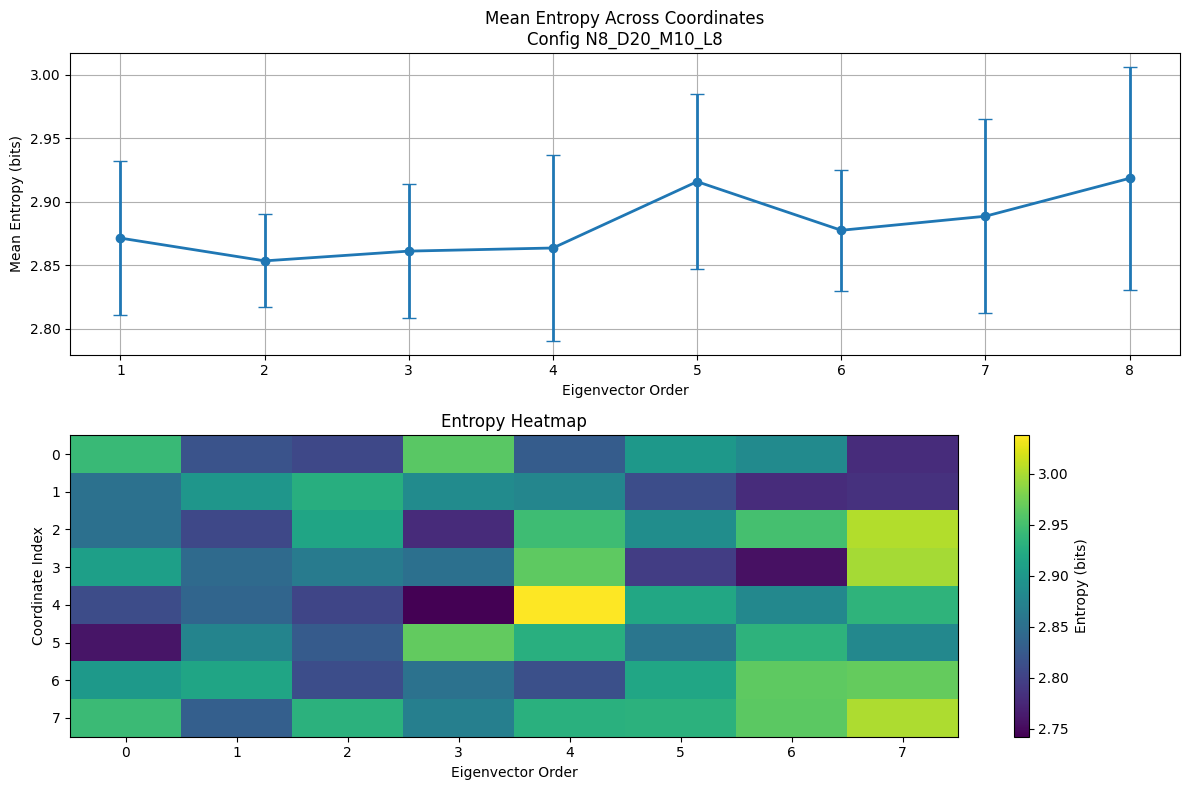

Processing experiment files:   1%|          | 1/97 [00:00<00:57,  1.68it/s]


Entropy Statistics:
  Overall mean entropy: 2.8812 ± 0.0630 bits
  Max entropy: 3.0375 bits
  Min entropy: 2.7422 bits

Most random eigenvector: 8th
  Mean entropy: 2.9184 ± 0.0878 bits

Least random eigenvector: 2nd
  Mean entropy: 2.8533 ± 0.0366 bits
Computing entropy for all eigenvector distributions - N8_D20_M10_L4


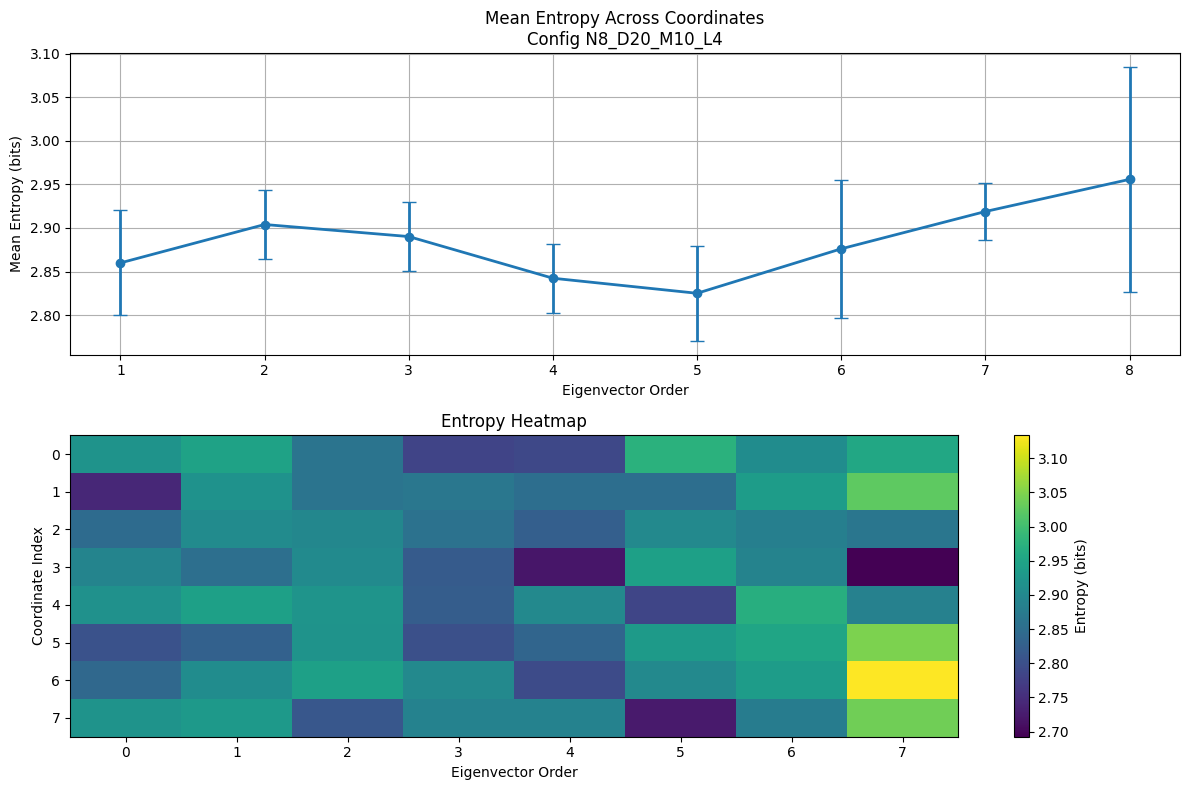

Processing experiment files:   2%|▏         | 2/97 [00:01<00:58,  1.61it/s]


Entropy Statistics:
  Overall mean entropy: 2.8840 ± 0.0593 bits
  Max entropy: 3.1337 bits
  Min entropy: 2.6925 bits

Most random eigenvector: 8th
  Mean entropy: 2.9558 ± 0.1291 bits

Least random eigenvector: 5th
  Mean entropy: 2.8250 ± 0.0547 bits
Computing entropy for all eigenvector distributions - N8_D50_M50_L6


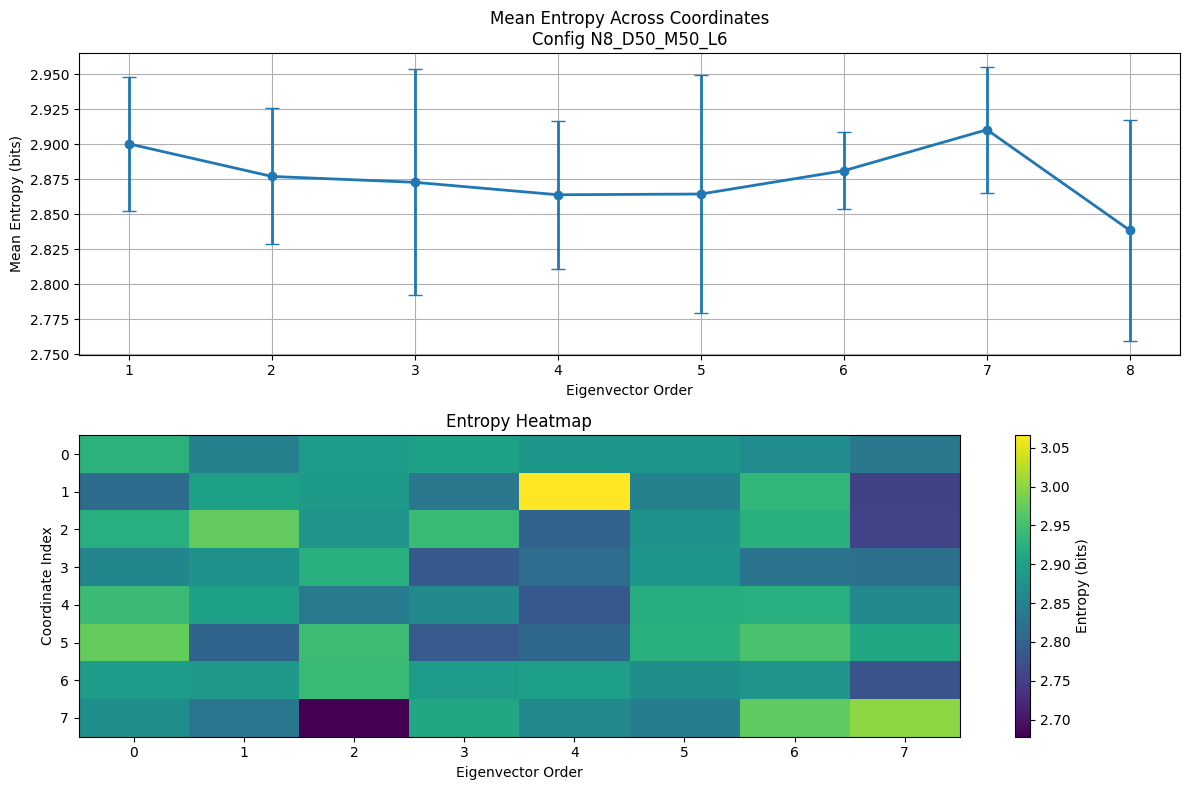

Processing experiment files:   3%|▎         | 3/97 [00:02<01:07,  1.39it/s]


Entropy Statistics:
  Overall mean entropy: 2.8761 ± 0.0584 bits
  Max entropy: 3.0661 bits
  Min entropy: 2.6779 bits

Most random eigenvector: 7th
  Mean entropy: 2.9104 ± 0.0450 bits

Least random eigenvector: 8th
  Mean entropy: 2.8384 ± 0.0790 bits
Computing entropy for all eigenvector distributions - N8_D50_M10_L2


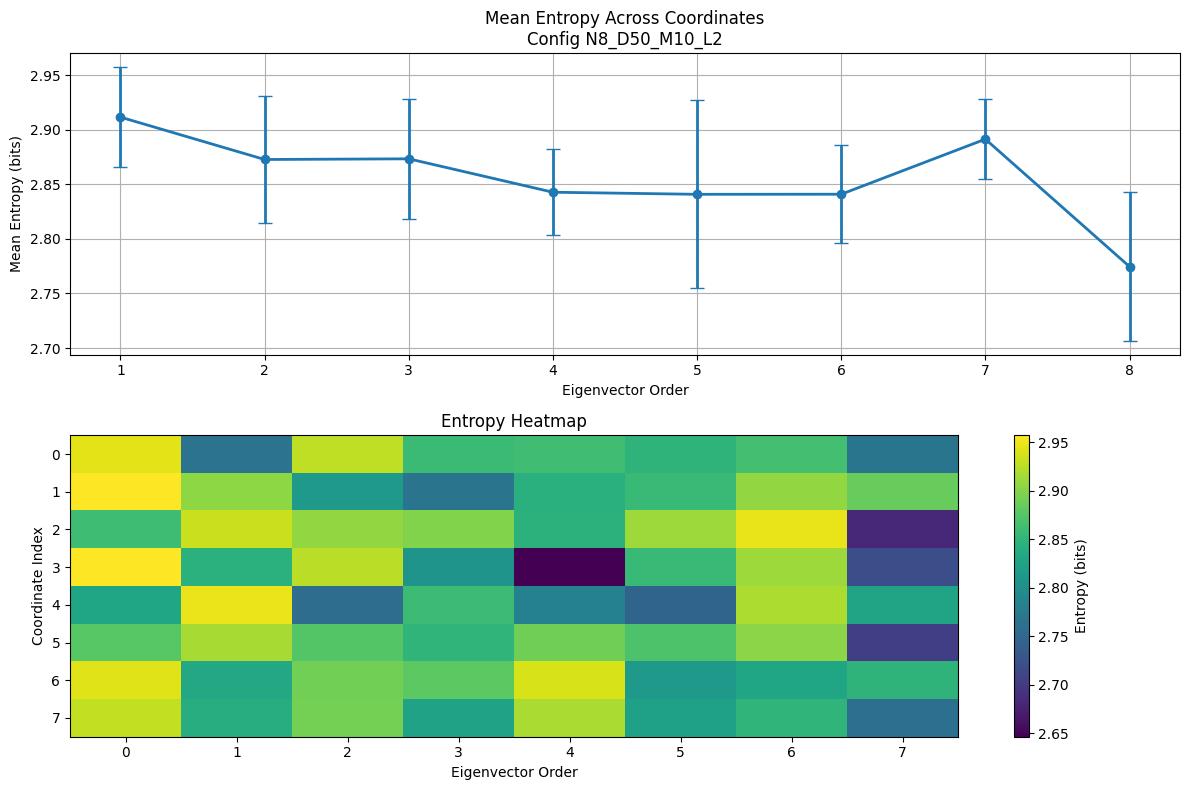

Processing experiment files:   4%|▍         | 4/97 [00:02<01:13,  1.26it/s]


Entropy Statistics:
  Overall mean entropy: 2.8561 ± 0.0544 bits
  Max entropy: 2.9571 bits
  Min entropy: 2.6465 bits

Most random eigenvector: 1st
  Mean entropy: 2.9117 ± 0.0461 bits

Least random eigenvector: 8th
  Mean entropy: 2.7746 ± 0.0681 bits
Computing entropy for all eigenvector distributions - N8_D20_M50_L4


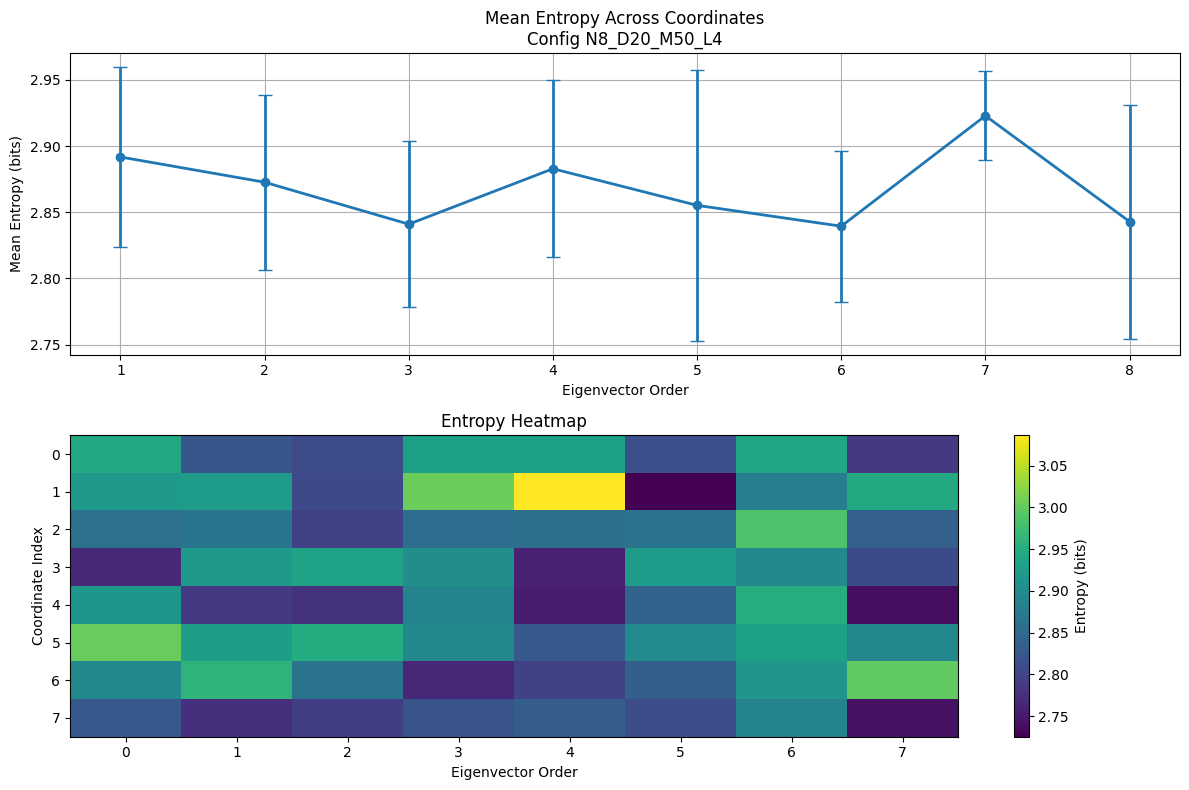

Processing experiment files:   5%|▌         | 5/97 [00:03<01:08,  1.35it/s]


Entropy Statistics:
  Overall mean entropy: 2.8685 ± 0.0681 bits
  Max entropy: 3.0864 bits
  Min entropy: 2.7255 bits

Most random eigenvector: 7th
  Mean entropy: 2.9229 ± 0.0335 bits

Least random eigenvector: 6th
  Mean entropy: 2.8394 ± 0.0571 bits
Computing entropy for all eigenvector distributions - N8_D20_M20_L8


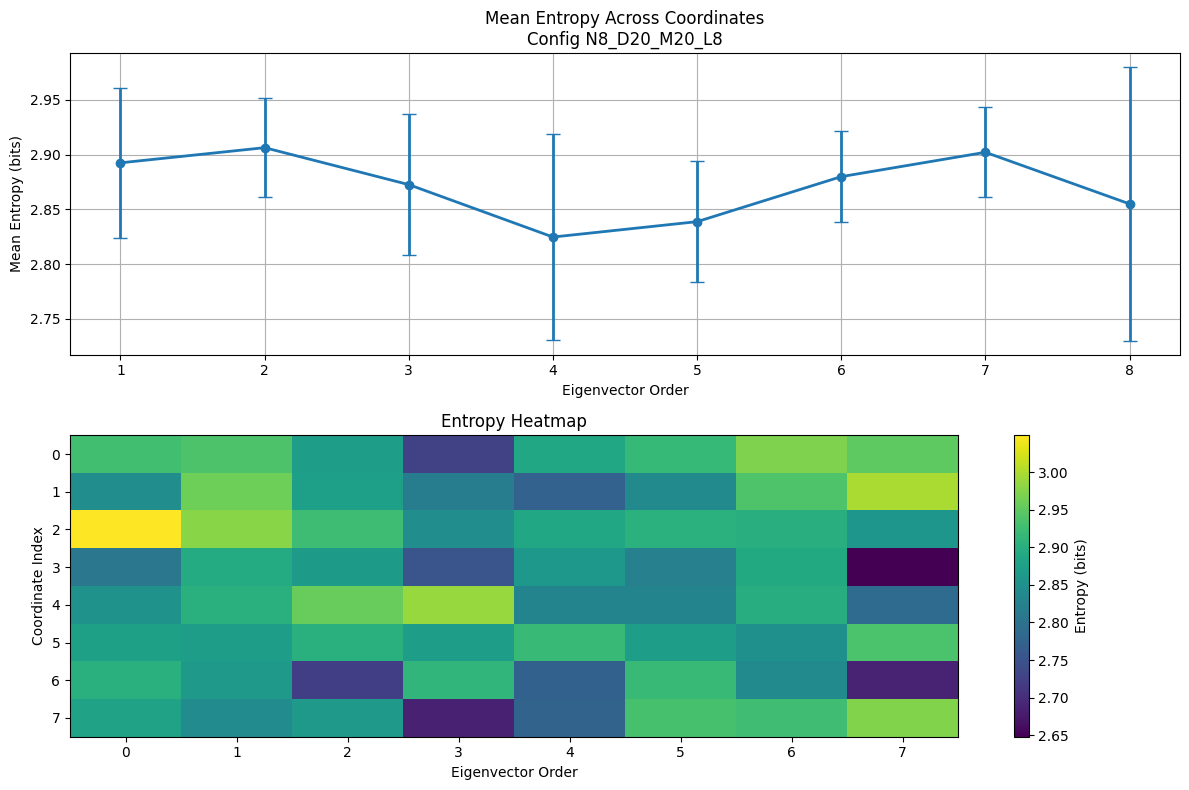

Processing experiment files:   6%|▌         | 6/97 [00:04<01:04,  1.42it/s]


Entropy Statistics:
  Overall mean entropy: 2.8715 ± 0.0670 bits
  Max entropy: 3.0494 bits
  Min entropy: 2.6479 bits

Most random eigenvector: 2nd
  Mean entropy: 2.9063 ± 0.0451 bits

Least random eigenvector: 4th
  Mean entropy: 2.8247 ± 0.0944 bits
Computing entropy for all eigenvector distributions - N8_D200_M50_L2


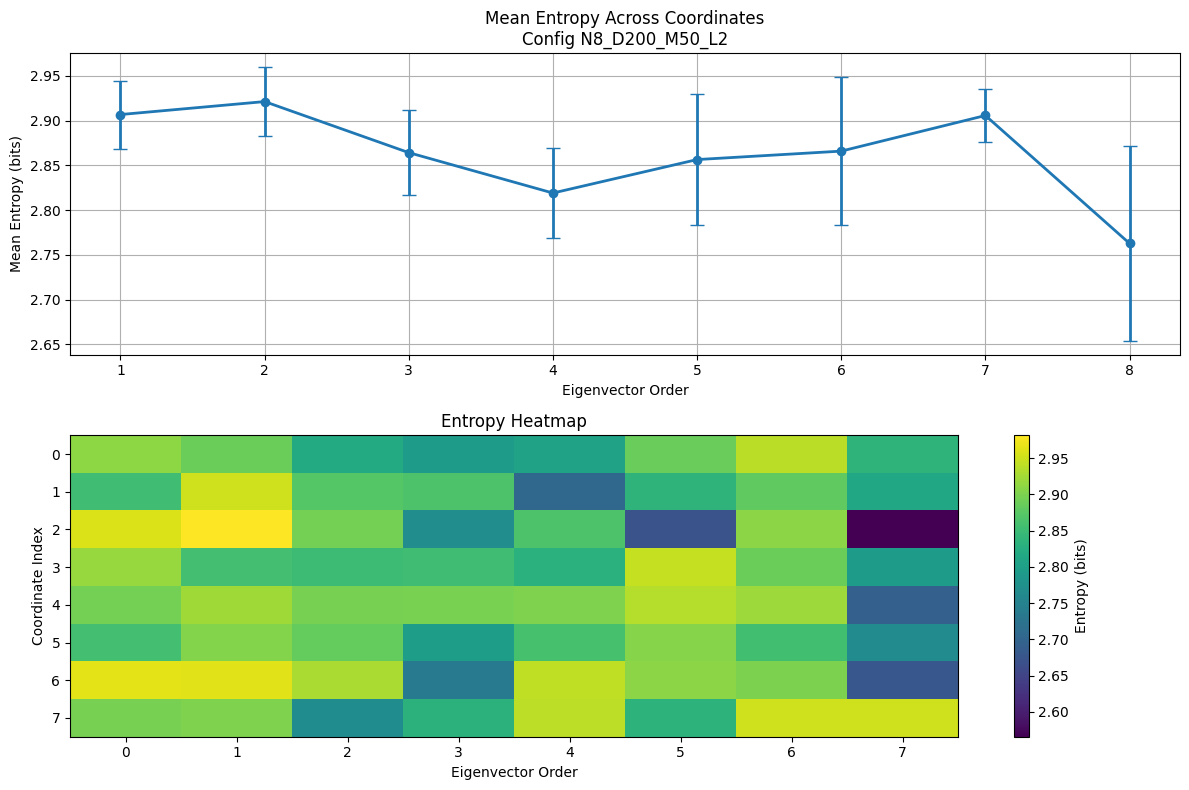

Processing experiment files:   7%|▋         | 7/97 [00:04<01:00,  1.48it/s]


Entropy Statistics:
  Overall mean entropy: 2.8628 ± 0.0585 bits
  Max entropy: 2.9816 bits
  Min entropy: 2.5659 bits

Most random eigenvector: 2nd
  Mean entropy: 2.9213 ± 0.0388 bits

Least random eigenvector: 8th
  Mean entropy: 2.7627 ± 0.1090 bits
Computing entropy for all eigenvector distributions - N8_D100_M20_L6


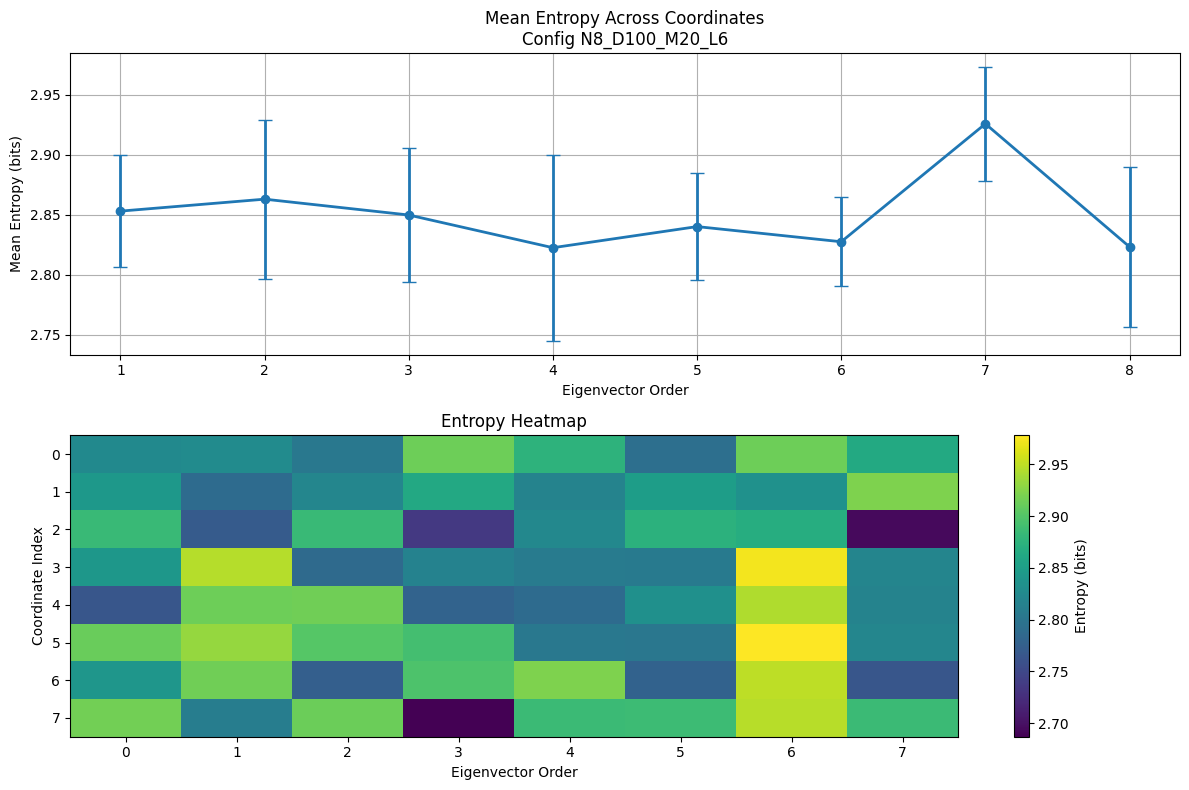

Processing experiment files:   8%|▊         | 8/97 [00:05<00:57,  1.54it/s]


Entropy Statistics:
  Overall mean entropy: 2.8507 ± 0.0551 bits
  Max entropy: 2.9781 bits
  Min entropy: 2.6868 bits

Most random eigenvector: 7th
  Mean entropy: 2.9258 ± 0.0474 bits

Least random eigenvector: 4th
  Mean entropy: 2.8227 ± 0.0776 bits
Computing entropy for all eigenvector distributions - N8_D20_M10_L6


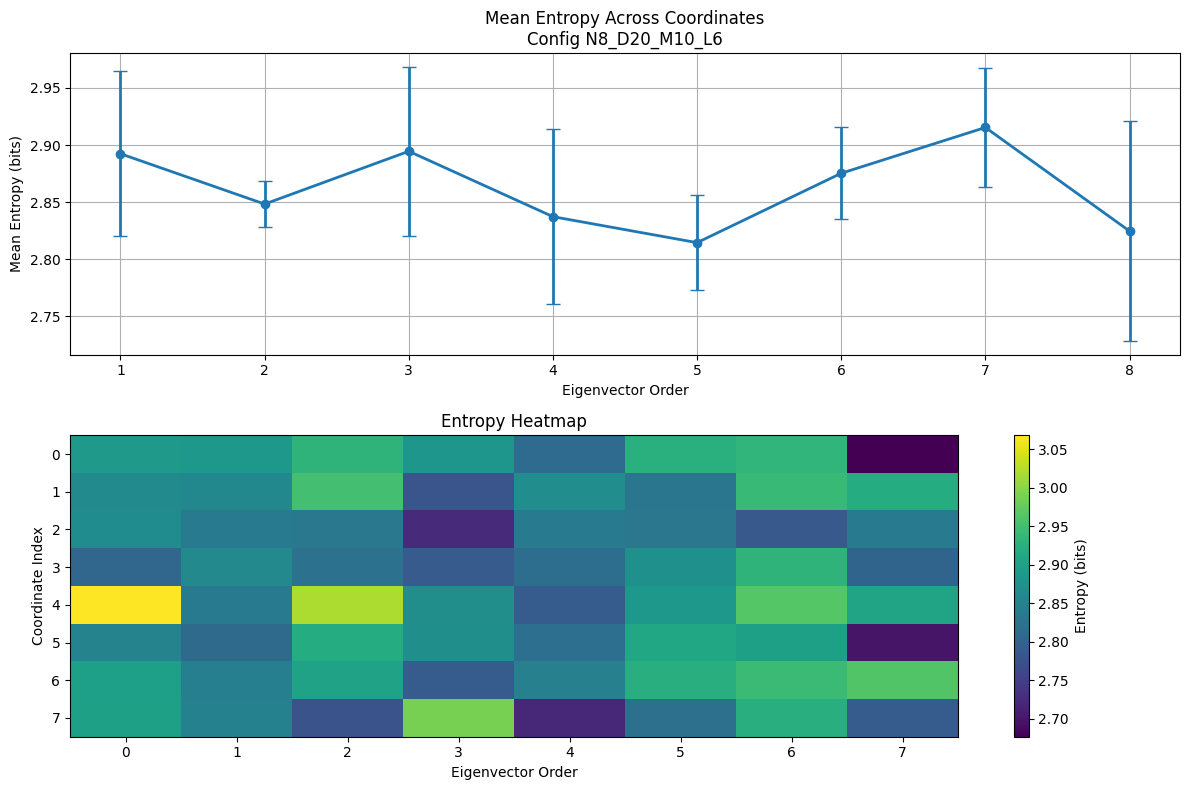

Processing experiment files:   9%|▉         | 9/97 [00:06<00:59,  1.47it/s]


Entropy Statistics:
  Overall mean entropy: 2.8627 ± 0.0592 bits
  Max entropy: 3.0683 bits
  Min entropy: 2.6767 bits

Most random eigenvector: 7th
  Mean entropy: 2.9154 ± 0.0519 bits

Least random eigenvector: 5th
  Mean entropy: 2.8145 ± 0.0419 bits
Computing entropy for all eigenvector distributions - N8_D20_M100_L6


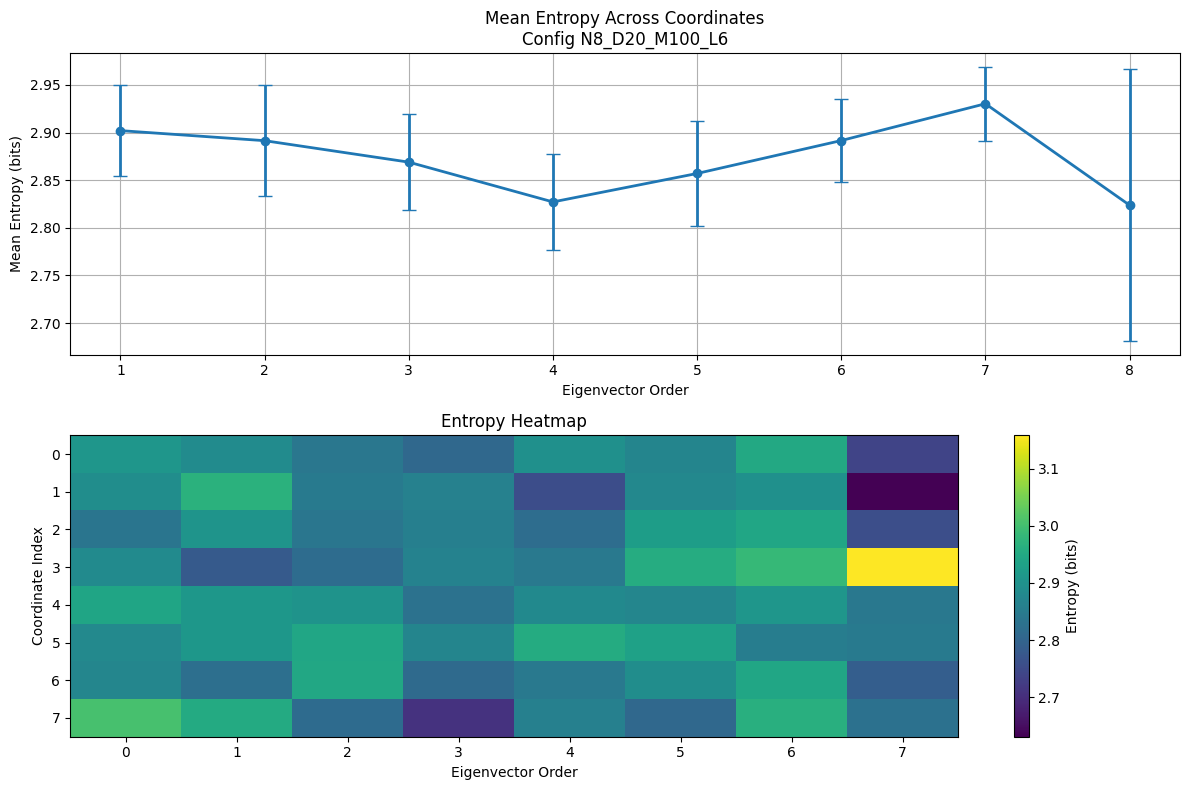

Processing experiment files:  10%|█         | 10/97 [00:06<00:59,  1.46it/s]


Entropy Statistics:
  Overall mean entropy: 2.8740 ± 0.0608 bits
  Max entropy: 3.1581 bits
  Min entropy: 2.6313 bits

Most random eigenvector: 7th
  Mean entropy: 2.9302 ± 0.0387 bits

Least random eigenvector: 8th
  Mean entropy: 2.8238 ± 0.1425 bits
Computing entropy for all eigenvector distributions - N8_D100_M20_L2


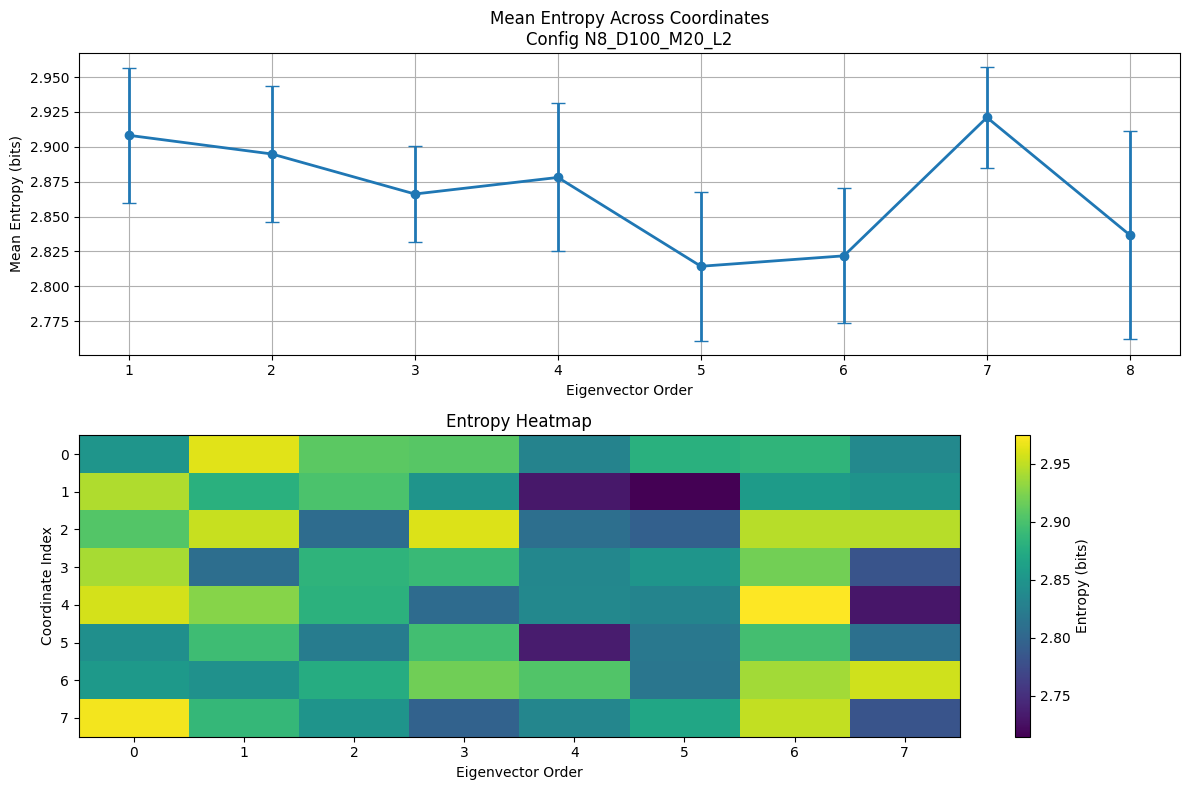

Processing experiment files:  11%|█▏        | 11/97 [00:07<00:56,  1.53it/s]


Entropy Statistics:
  Overall mean entropy: 2.8676 ± 0.0496 bits
  Max entropy: 2.9746 bits
  Min entropy: 2.7145 bits

Most random eigenvector: 7th
  Mean entropy: 2.9210 ± 0.0363 bits

Least random eigenvector: 5th
  Mean entropy: 2.8143 ± 0.0535 bits
Computing entropy for all eigenvector distributions - N8_D200_M10_L2


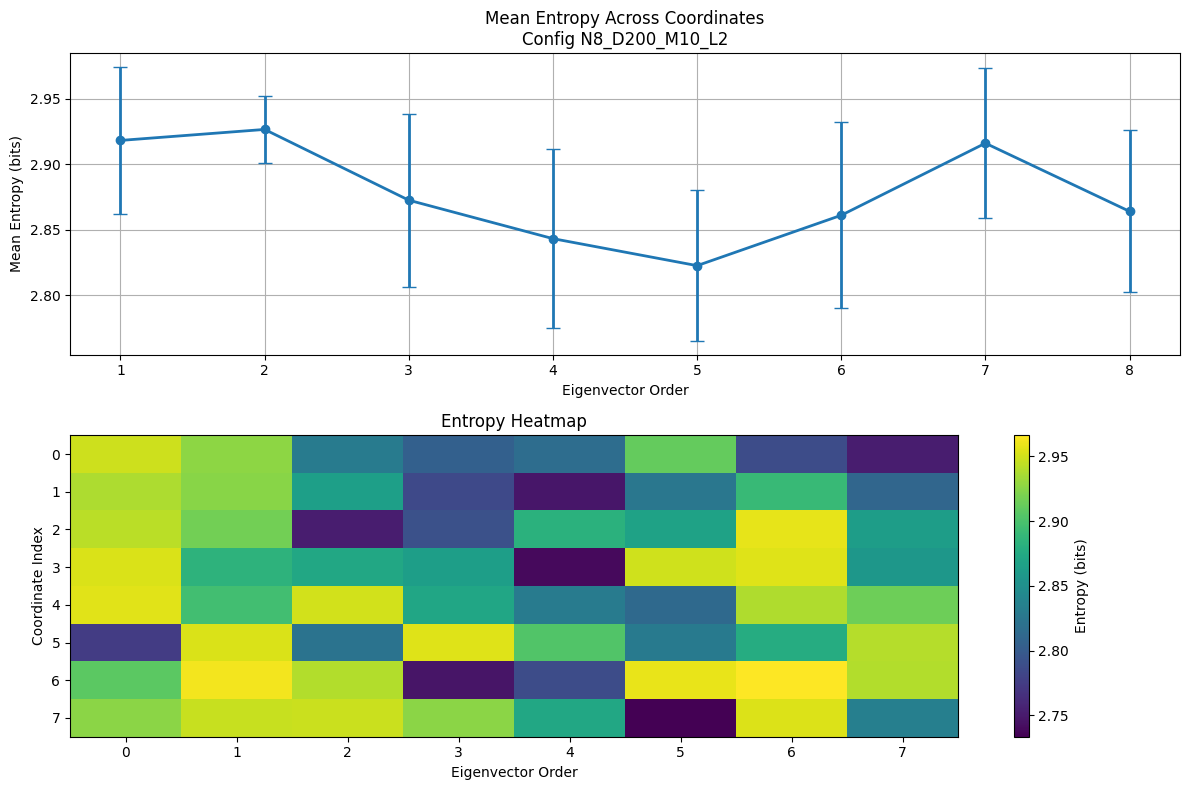

Processing experiment files:  12%|█▏        | 12/97 [00:08<00:52,  1.62it/s]


Entropy Statistics:
  Overall mean entropy: 2.8780 ± 0.0580 bits
  Max entropy: 2.9663 bits
  Min entropy: 2.7336 bits

Most random eigenvector: 2nd
  Mean entropy: 2.9265 ± 0.0255 bits

Least random eigenvector: 5th
  Mean entropy: 2.8226 ± 0.0575 bits
Computing entropy for all eigenvector distributions - N8_D20_M20_L6


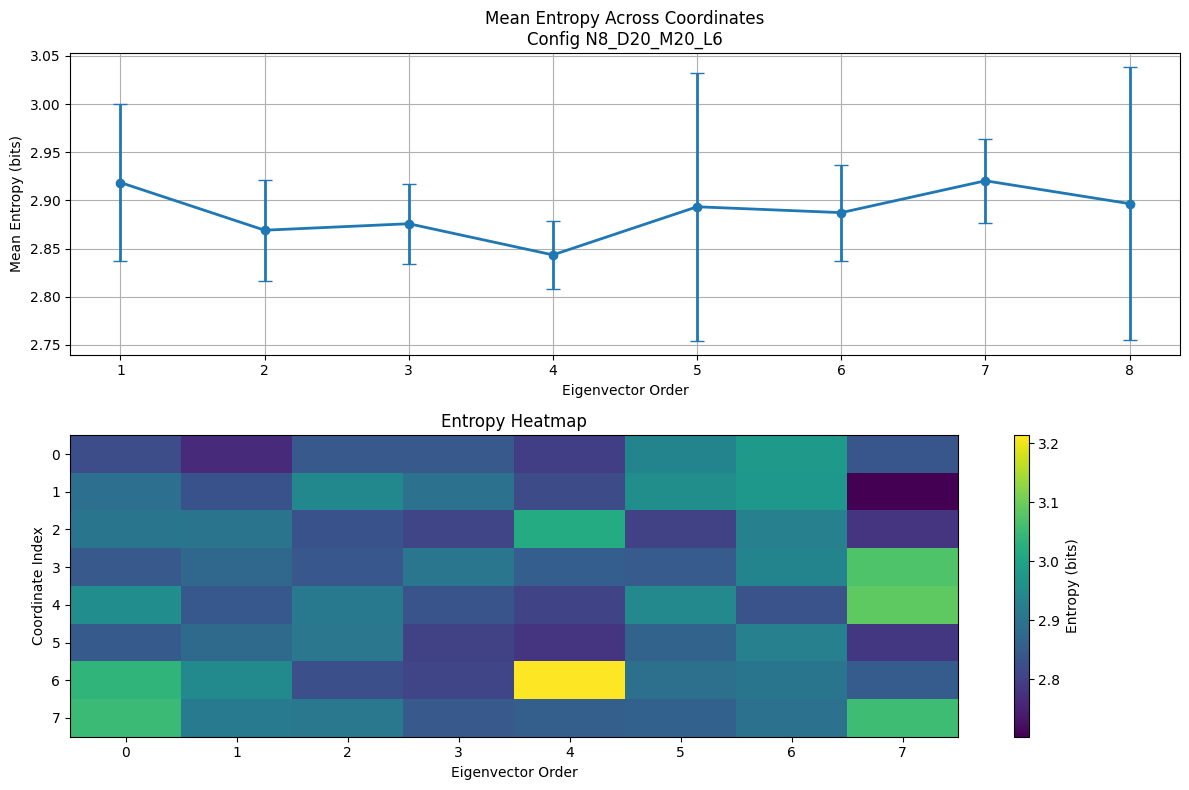

Processing experiment files:  13%|█▎        | 13/97 [00:08<00:51,  1.64it/s]


Entropy Statistics:
  Overall mean entropy: 2.8881 ± 0.0732 bits
  Max entropy: 3.2135 bits
  Min entropy: 2.7028 bits

Most random eigenvector: 7th
  Mean entropy: 2.9204 ± 0.0436 bits

Least random eigenvector: 4th
  Mean entropy: 2.8434 ± 0.0357 bits
Computing entropy for all eigenvector distributions - N8_D50_M50_L2


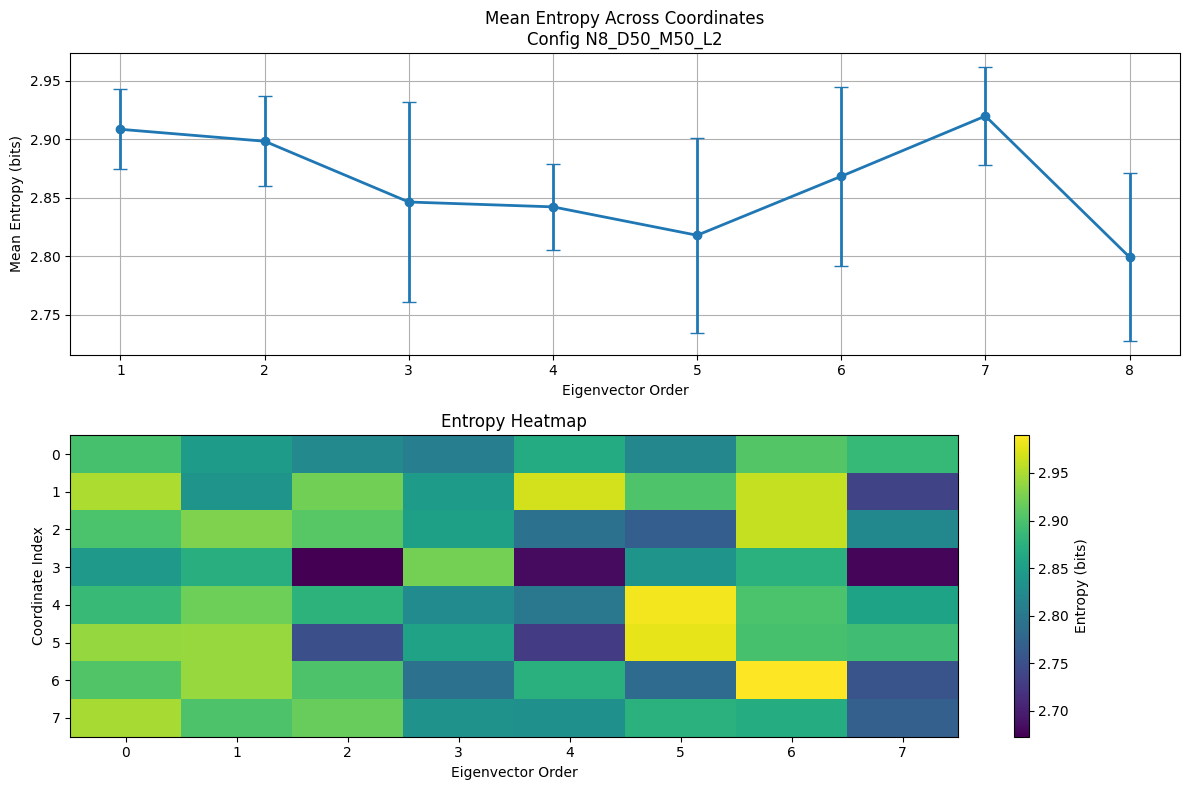

Processing experiment files:  14%|█▍        | 14/97 [00:09<00:51,  1.62it/s]


Entropy Statistics:
  Overall mean entropy: 2.8626 ± 0.0586 bits
  Max entropy: 2.9896 bits
  Min entropy: 2.6729 bits

Most random eigenvector: 7th
  Mean entropy: 2.9199 ± 0.0421 bits

Least random eigenvector: 8th
  Mean entropy: 2.7992 ± 0.0717 bits
Computing entropy for all eigenvector distributions - N8_D50_M50_L4


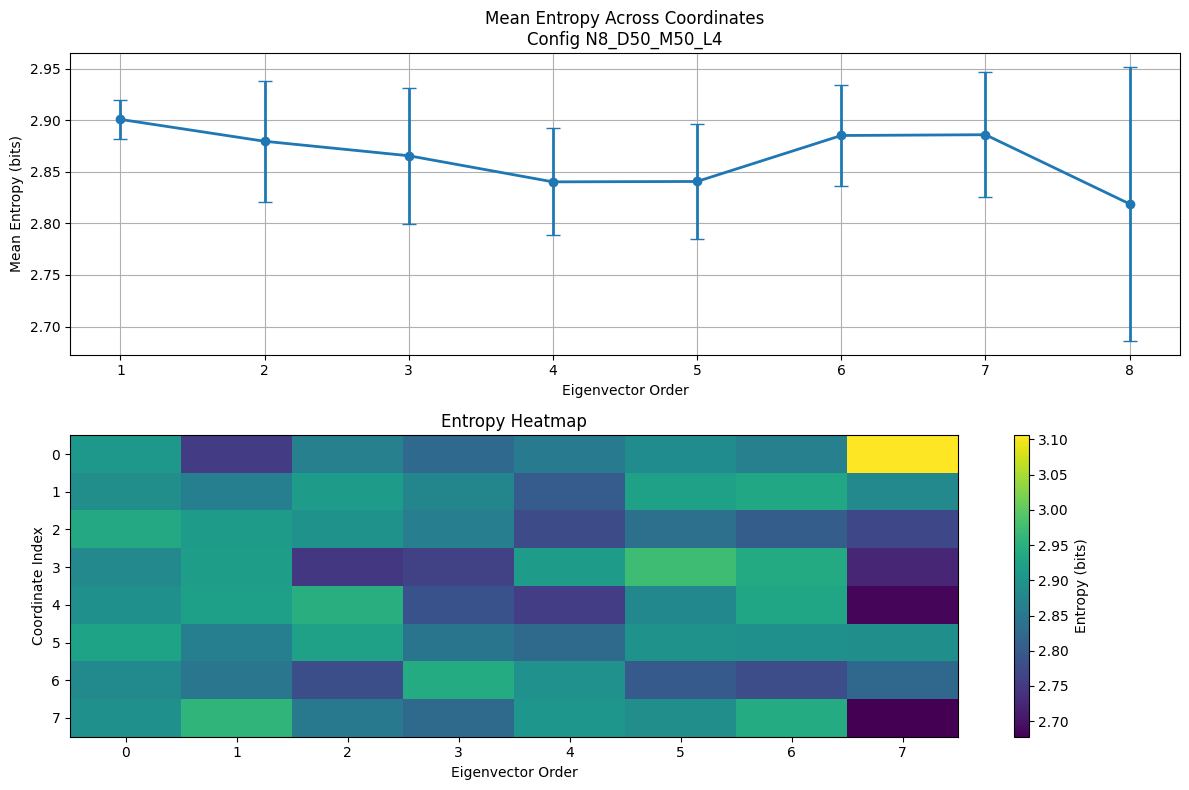

Processing experiment files:  15%|█▌        | 15/97 [00:09<00:50,  1.61it/s]


Entropy Statistics:
  Overall mean entropy: 2.8645 ± 0.0617 bits
  Max entropy: 3.1060 bits
  Min entropy: 2.6779 bits

Most random eigenvector: 1st
  Mean entropy: 2.9007 ± 0.0190 bits

Least random eigenvector: 8th
  Mean entropy: 2.8188 ± 0.1328 bits
Computing entropy for all eigenvector distributions - N8_D100_M10_L6


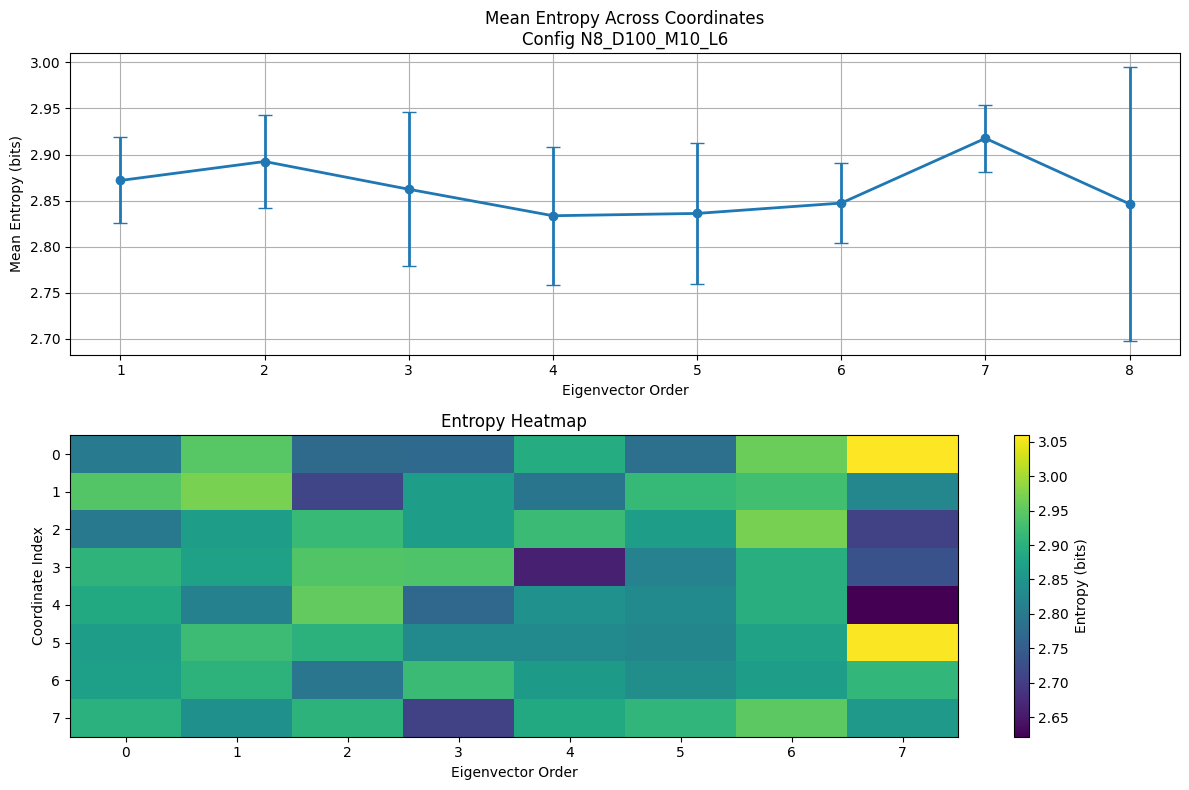

Processing experiment files:  16%|█▋        | 16/97 [00:10<00:55,  1.45it/s]


Entropy Statistics:
  Overall mean entropy: 2.8634 ± 0.0700 bits
  Max entropy: 3.0593 bits
  Min entropy: 2.6219 bits

Most random eigenvector: 7th
  Mean entropy: 2.9176 ± 0.0366 bits

Least random eigenvector: 4th
  Mean entropy: 2.8336 ± 0.0747 bits
Computing entropy for all eigenvector distributions - N8_D50_M20_L6


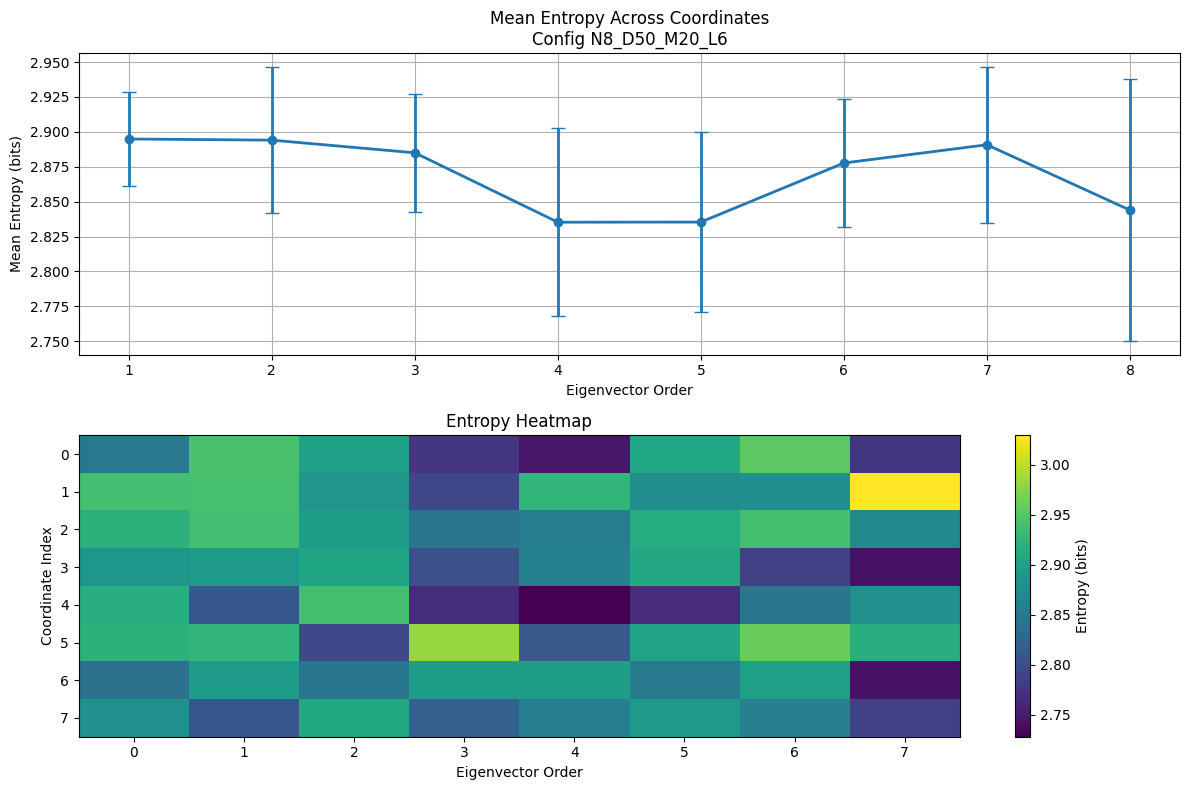

Processing experiment files:  18%|█▊        | 17/97 [00:11<00:53,  1.49it/s]


Entropy Statistics:
  Overall mean entropy: 2.8696 ± 0.0570 bits
  Max entropy: 3.0294 bits
  Min entropy: 2.7280 bits

Most random eigenvector: 1st
  Mean entropy: 2.8949 ± 0.0336 bits

Least random eigenvector: 4th
  Mean entropy: 2.8353 ± 0.0674 bits
Computing entropy for all eigenvector distributions - N8_D1000_M10_L2


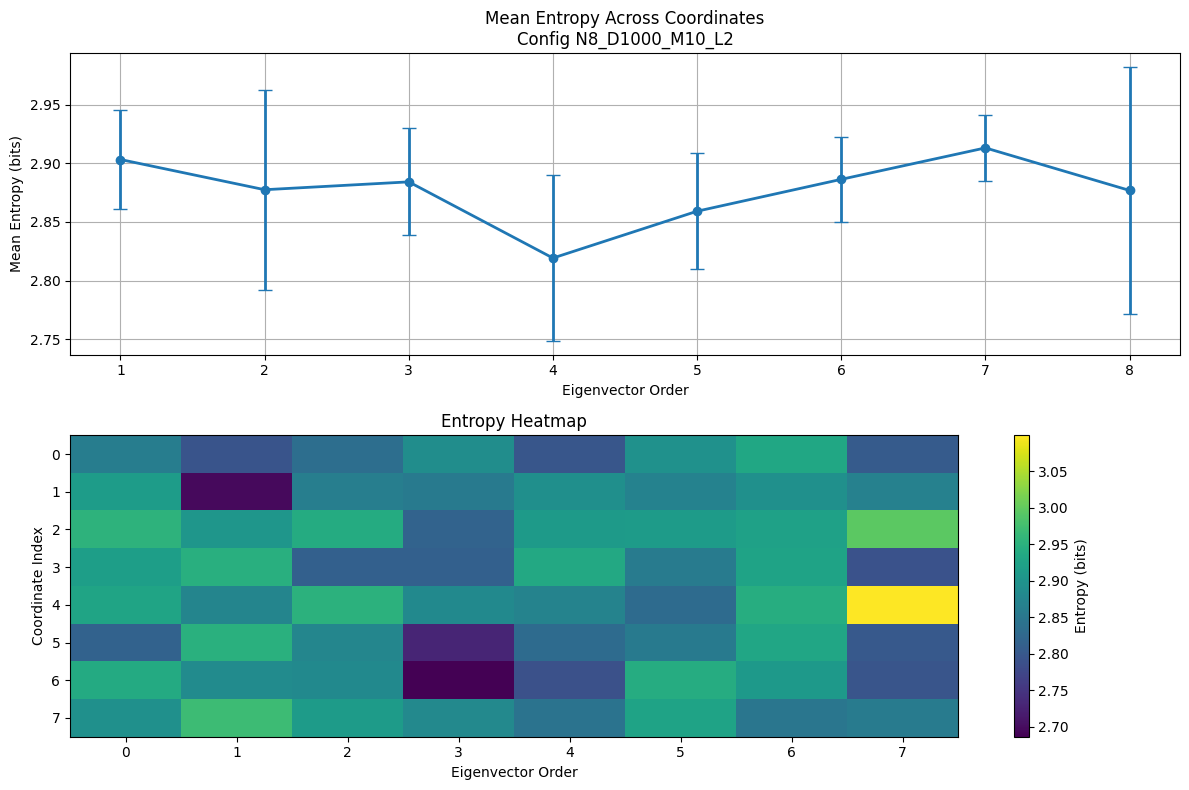

Processing experiment files:  19%|█▊        | 18/97 [00:11<00:50,  1.55it/s]


Entropy Statistics:
  Overall mean entropy: 2.8774 ± 0.0579 bits
  Max entropy: 3.0991 bits
  Min entropy: 2.6866 bits

Most random eigenvector: 7th
  Mean entropy: 2.9131 ± 0.0284 bits

Least random eigenvector: 4th
  Mean entropy: 2.8192 ± 0.0706 bits
Computing entropy for all eigenvector distributions - N8_D20_M50_L6


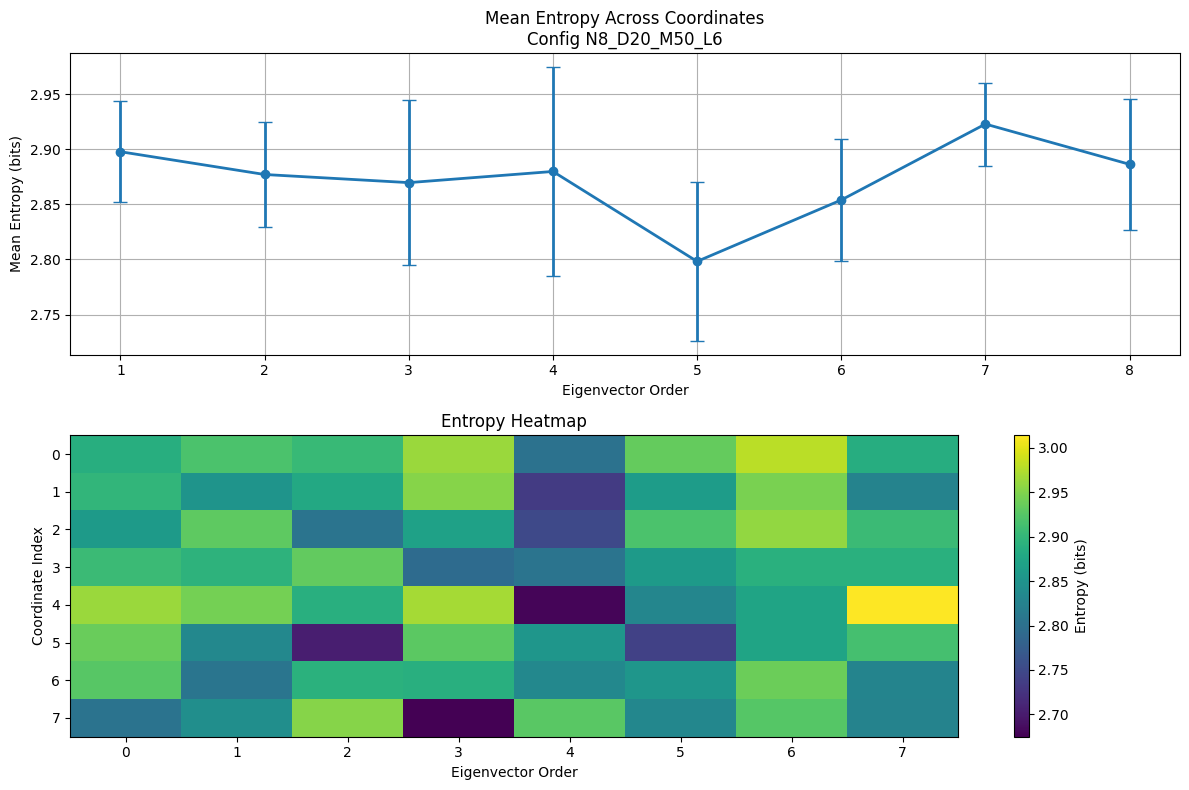

Processing experiment files:  20%|█▉        | 19/97 [00:12<00:48,  1.59it/s]


Entropy Statistics:
  Overall mean entropy: 2.8734 ± 0.0610 bits
  Max entropy: 3.0144 bits
  Min entropy: 2.6748 bits

Most random eigenvector: 7th
  Mean entropy: 2.9231 ± 0.0377 bits

Least random eigenvector: 5th
  Mean entropy: 2.7983 ± 0.0722 bits
Computing entropy for all eigenvector distributions - N8_D50_M20_L4


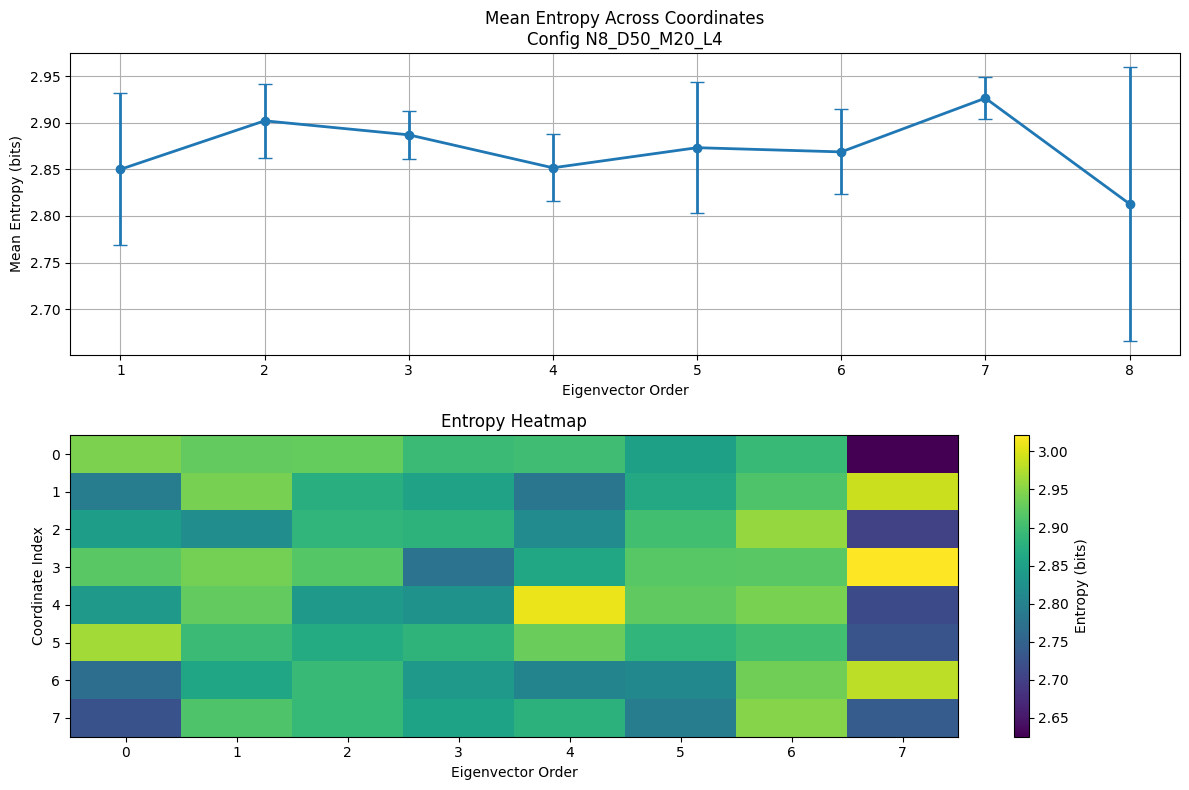

Processing experiment files:  21%|██        | 20/97 [00:13<00:47,  1.62it/s]


Entropy Statistics:
  Overall mean entropy: 2.8714 ± 0.0585 bits
  Max entropy: 3.0212 bits
  Min entropy: 2.6254 bits

Most random eigenvector: 7th
  Mean entropy: 2.9263 ± 0.0223 bits

Least random eigenvector: 8th
  Mean entropy: 2.8129 ± 0.1469 bits
Computing entropy for all eigenvector distributions - N8_D50_M200_L2


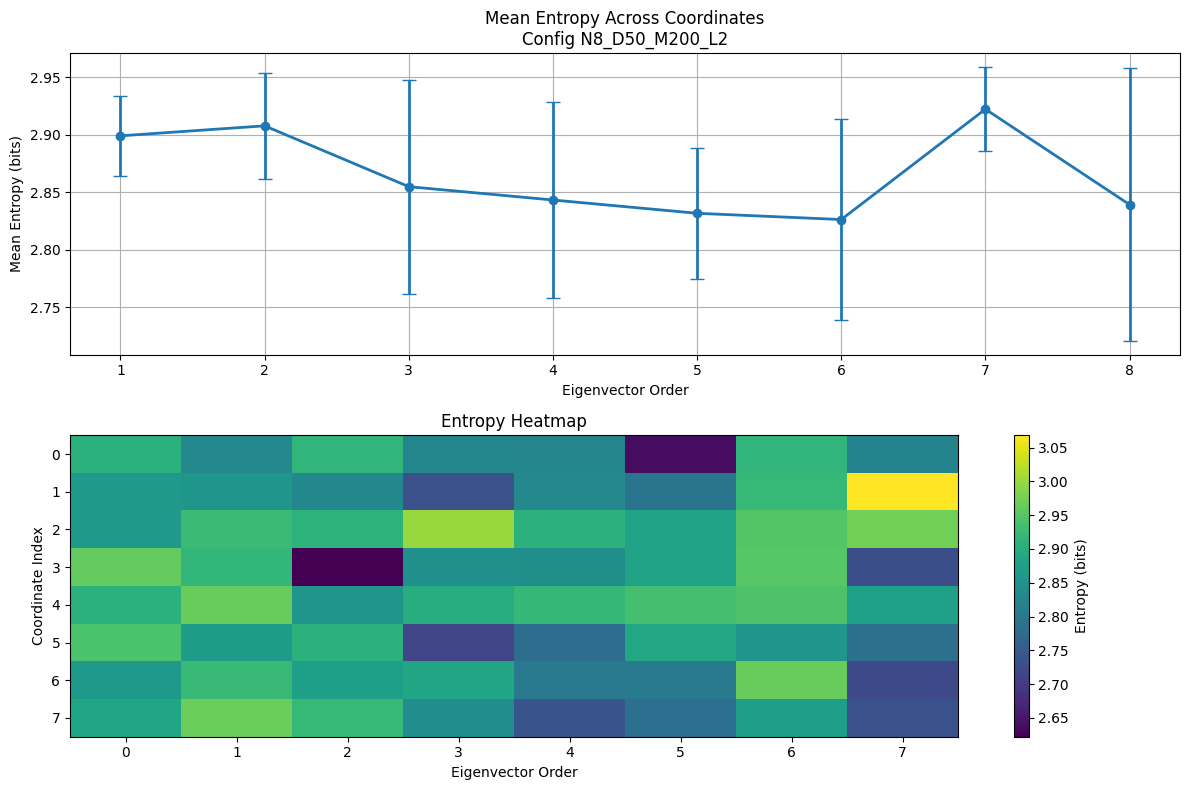

Processing experiment files:  22%|██▏       | 21/97 [00:13<00:46,  1.62it/s]


Entropy Statistics:
  Overall mean entropy: 2.8654 ± 0.0698 bits
  Max entropy: 3.0683 bits
  Min entropy: 2.6221 bits

Most random eigenvector: 7th
  Mean entropy: 2.9221 ± 0.0368 bits

Least random eigenvector: 6th
  Mean entropy: 2.8261 ± 0.0870 bits
Computing entropy for all eigenvector distributions - N8_D500_M20_L2


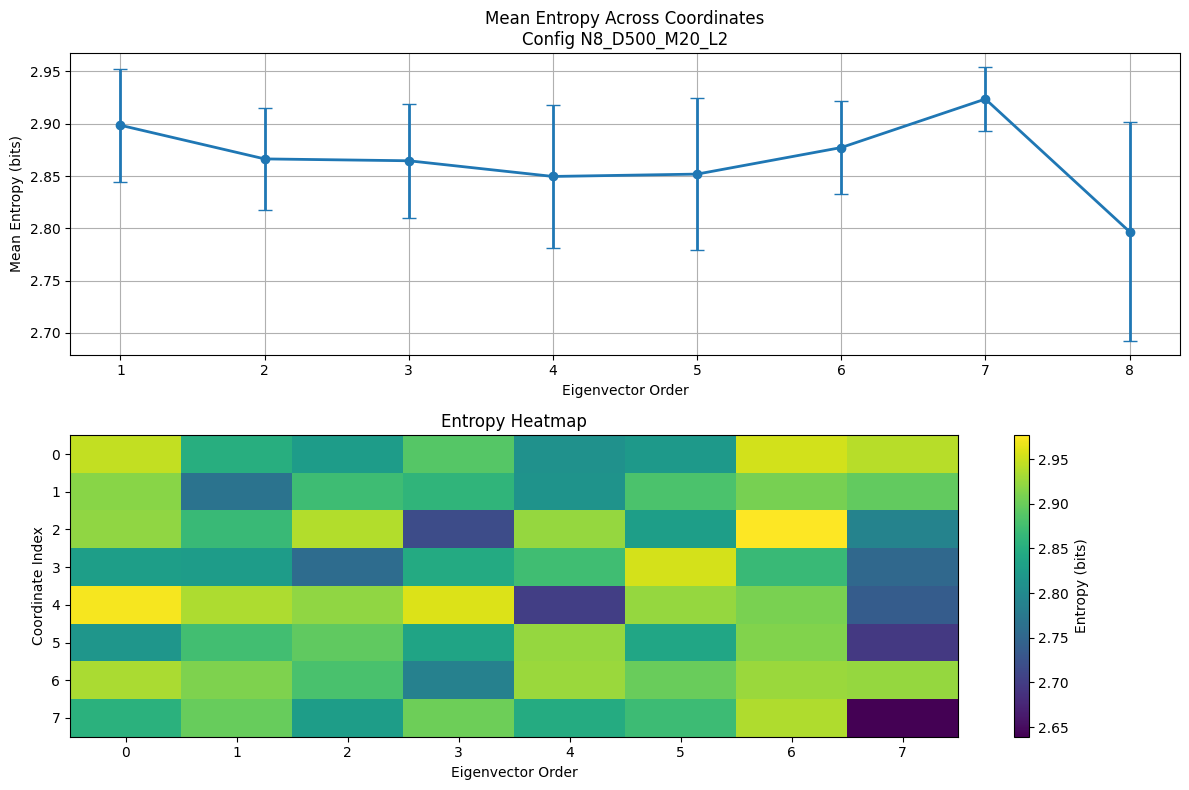

Processing experiment files:  23%|██▎       | 22/97 [00:14<00:47,  1.58it/s]


Entropy Statistics:
  Overall mean entropy: 2.8661 ± 0.0598 bits
  Max entropy: 2.9766 bits
  Min entropy: 2.6392 bits

Most random eigenvector: 7th
  Mean entropy: 2.9236 ± 0.0308 bits

Least random eigenvector: 8th
  Mean entropy: 2.7968 ± 0.1044 bits
Computing entropy for all eigenvector distributions - N8_D50_M10_L8


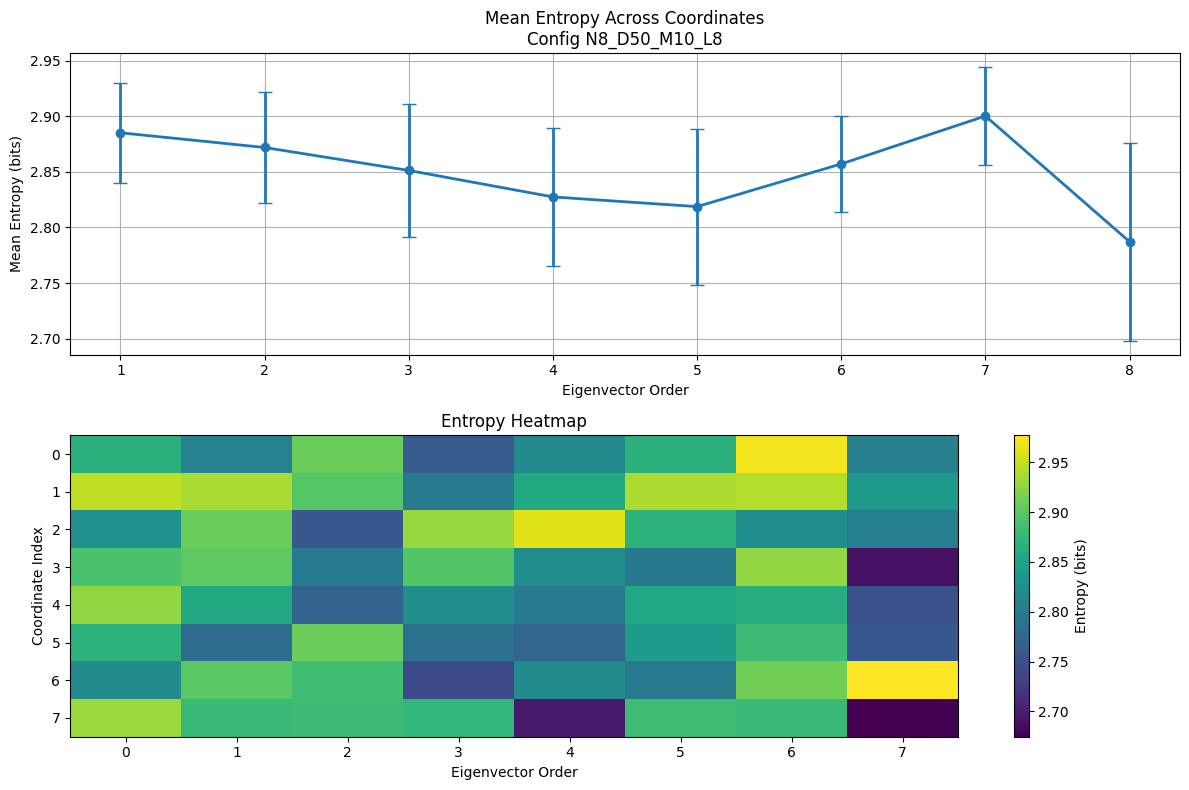

Processing experiment files:  24%|██▎       | 23/97 [00:14<00:45,  1.63it/s]


Entropy Statistics:
  Overall mean entropy: 2.8500 ± 0.0580 bits
  Max entropy: 2.9771 bits
  Min entropy: 2.6747 bits

Most random eigenvector: 7th
  Mean entropy: 2.9004 ± 0.0443 bits

Least random eigenvector: 8th
  Mean entropy: 2.7872 ± 0.0893 bits
Computing entropy for all eigenvector distributions - N8_D200_M20_L2


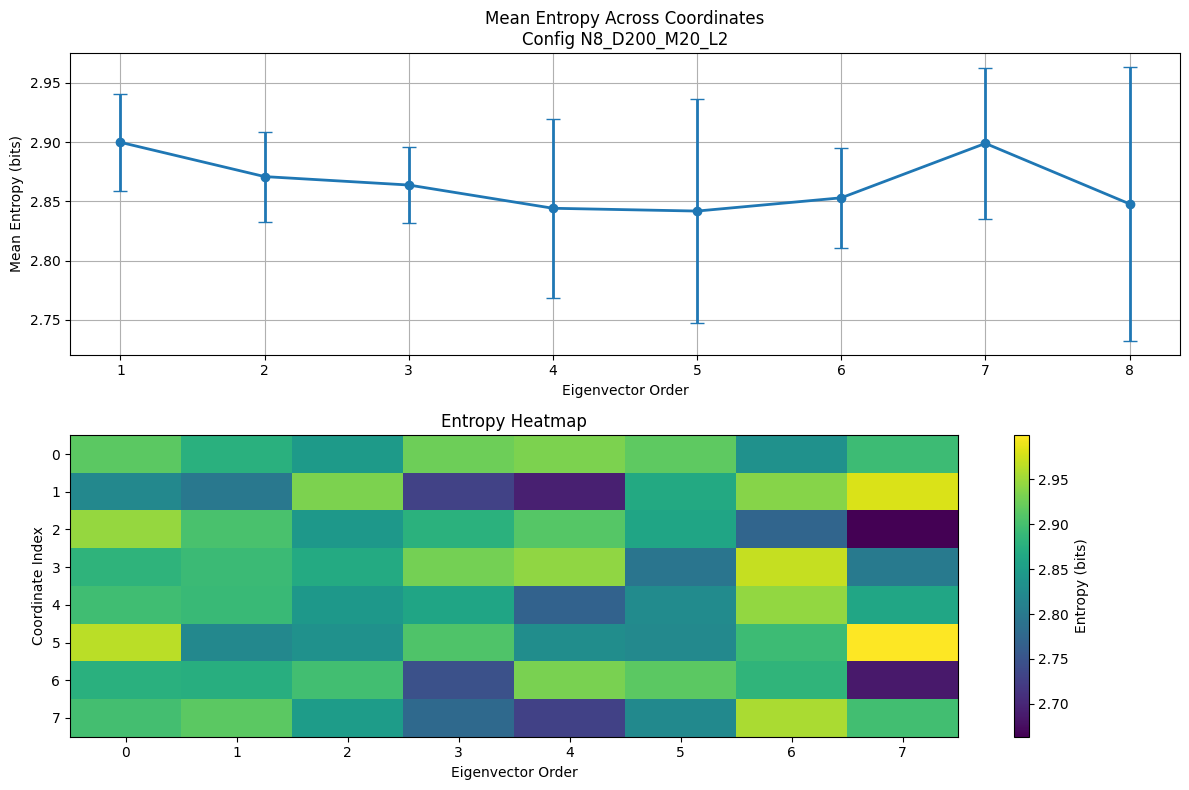

Processing experiment files:  25%|██▍       | 24/97 [00:15<00:44,  1.63it/s]


Entropy Statistics:
  Overall mean entropy: 2.8650 ± 0.0629 bits
  Max entropy: 2.9988 bits
  Min entropy: 2.6636 bits

Most random eigenvector: 1st
  Mean entropy: 2.8998 ± 0.0412 bits

Least random eigenvector: 5th
  Mean entropy: 2.8418 ± 0.0948 bits
Computing entropy for all eigenvector distributions - N8_D20_M50_L2


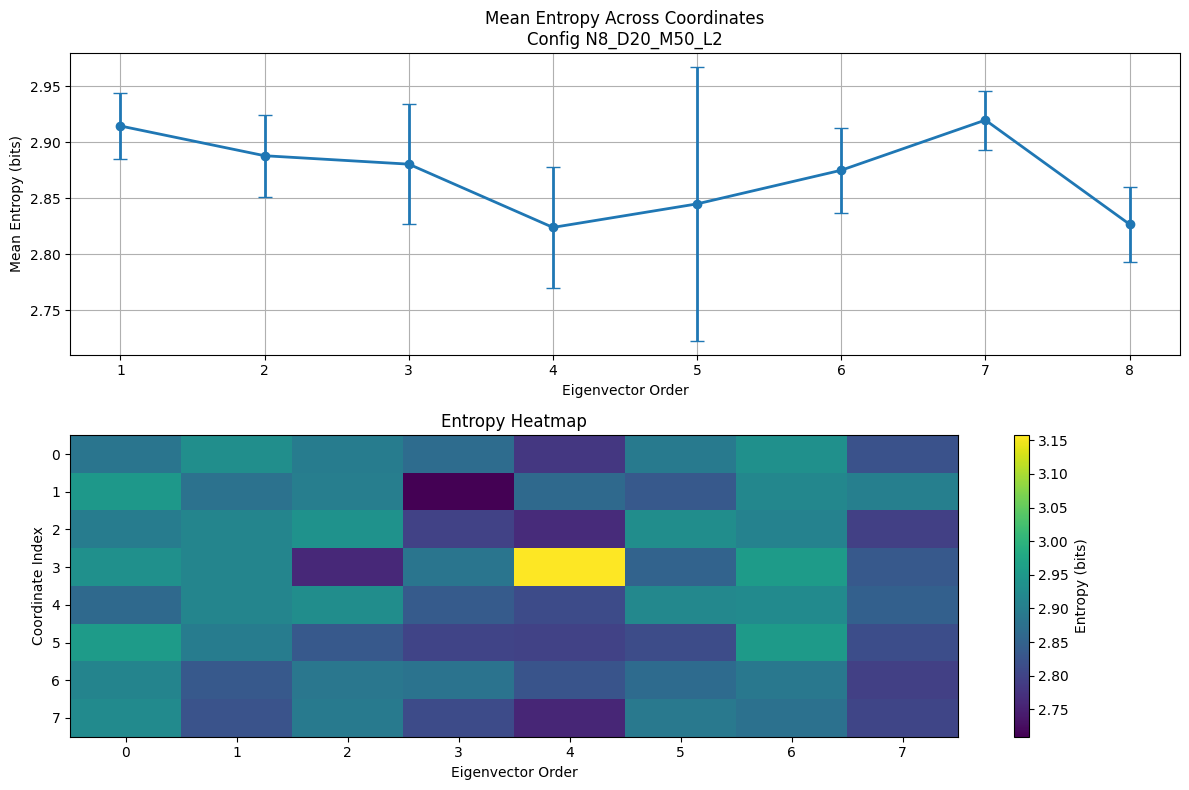

Processing experiment files:  26%|██▌       | 25/97 [00:16<00:43,  1.64it/s]


Entropy Statistics:
  Overall mean entropy: 2.8715 ± 0.0493 bits
  Max entropy: 3.1574 bits
  Min entropy: 2.7094 bits

Most random eigenvector: 7th
  Mean entropy: 2.9197 ± 0.0264 bits

Least random eigenvector: 4th
  Mean entropy: 2.8238 ± 0.0538 bits
Computing entropy for all eigenvector distributions - N8_D20_M100_L2


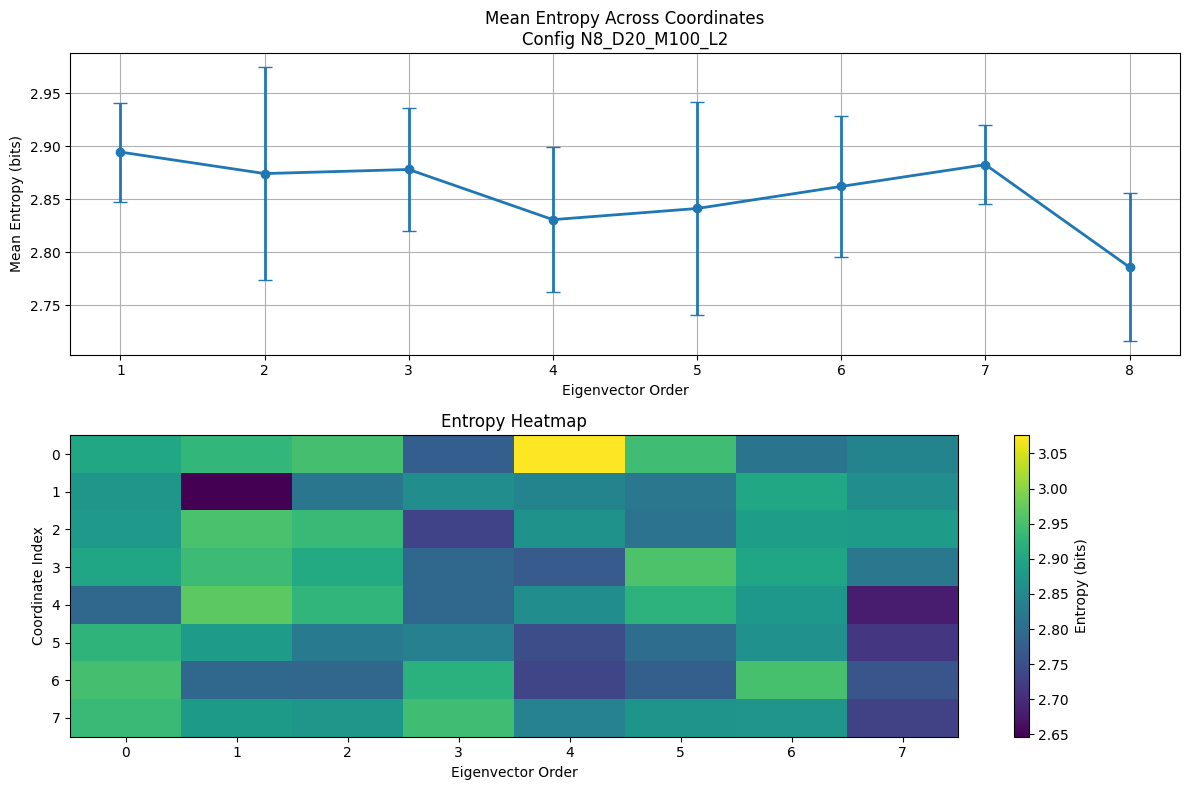

Processing experiment files:  27%|██▋       | 26/97 [00:16<00:43,  1.62it/s]


Entropy Statistics:
  Overall mean entropy: 2.8562 ± 0.0684 bits
  Max entropy: 3.0759 bits
  Min entropy: 2.6468 bits

Most random eigenvector: 1st
  Mean entropy: 2.8945 ± 0.0467 bits

Least random eigenvector: 8th
  Mean entropy: 2.7859 ± 0.0695 bits
Computing entropy for all eigenvector distributions - N8_D50_M10_L10


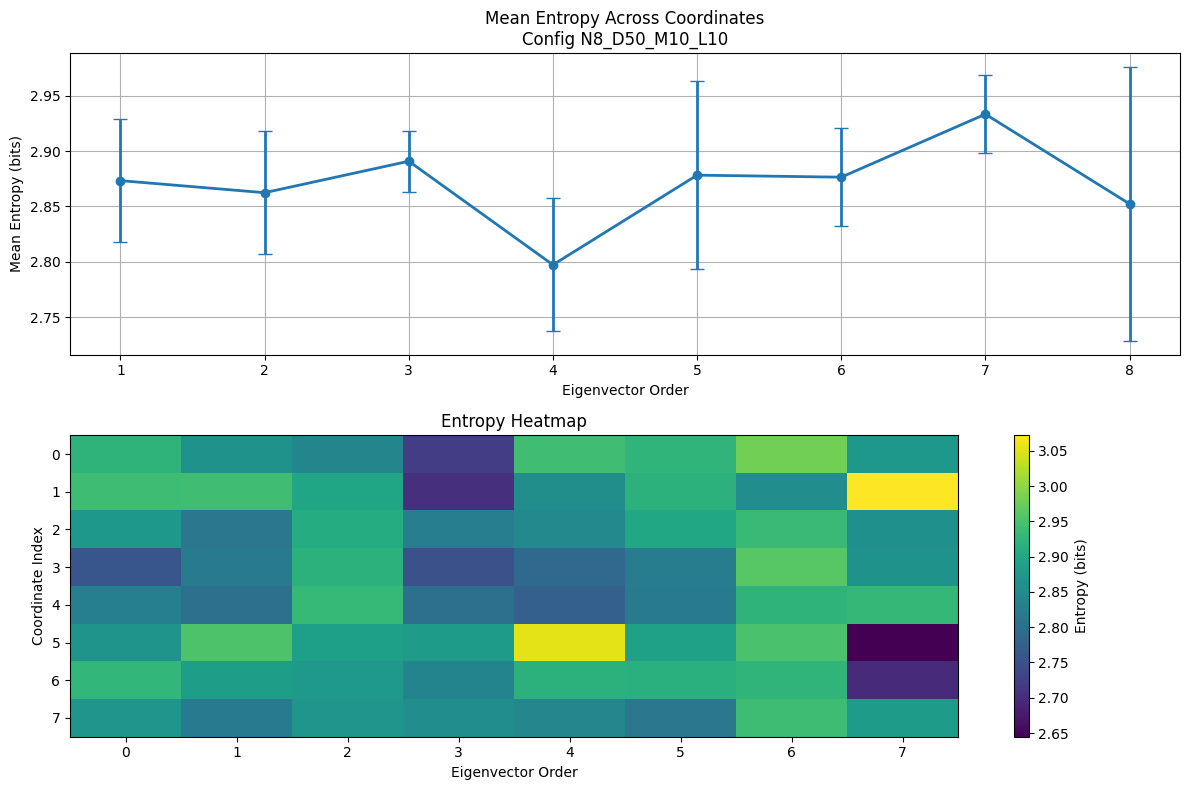

Processing experiment files:  28%|██▊       | 27/97 [00:17<00:49,  1.40it/s]


Entropy Statistics:
  Overall mean entropy: 2.8705 ± 0.0608 bits
  Max entropy: 3.0720 bits
  Min entropy: 2.6448 bits

Most random eigenvector: 7th
  Mean entropy: 2.9332 ± 0.0351 bits

Least random eigenvector: 4th
  Mean entropy: 2.7973 ± 0.0601 bits
Computing entropy for all eigenvector distributions - N8_D100_M50_L4


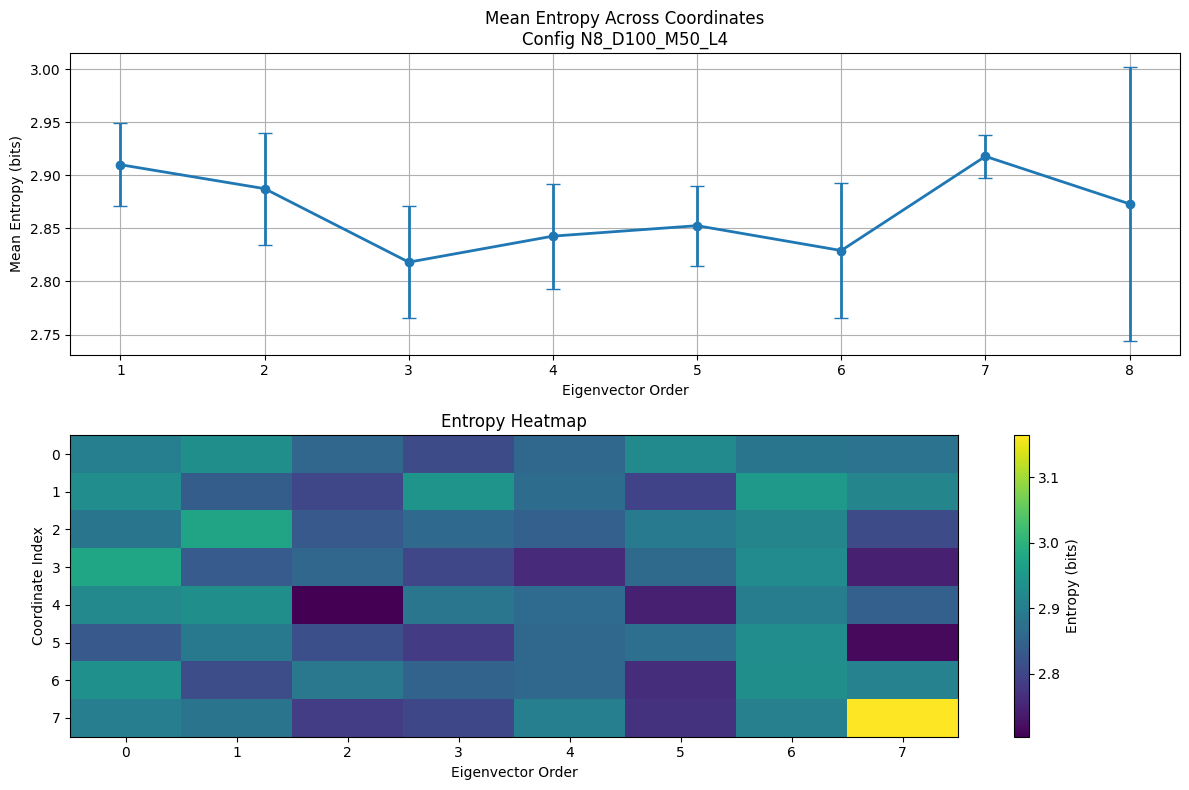

Processing experiment files:  29%|██▉       | 28/97 [00:18<00:46,  1.47it/s]


Entropy Statistics:
  Overall mean entropy: 2.8663 ± 0.0556 bits
  Max entropy: 3.1641 bits
  Min entropy: 2.7043 bits

Most random eigenvector: 7th
  Mean entropy: 2.9178 ± 0.0204 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8182 ± 0.0526 bits
Computing entropy for all eigenvector distributions - N8_D20_M10_L12


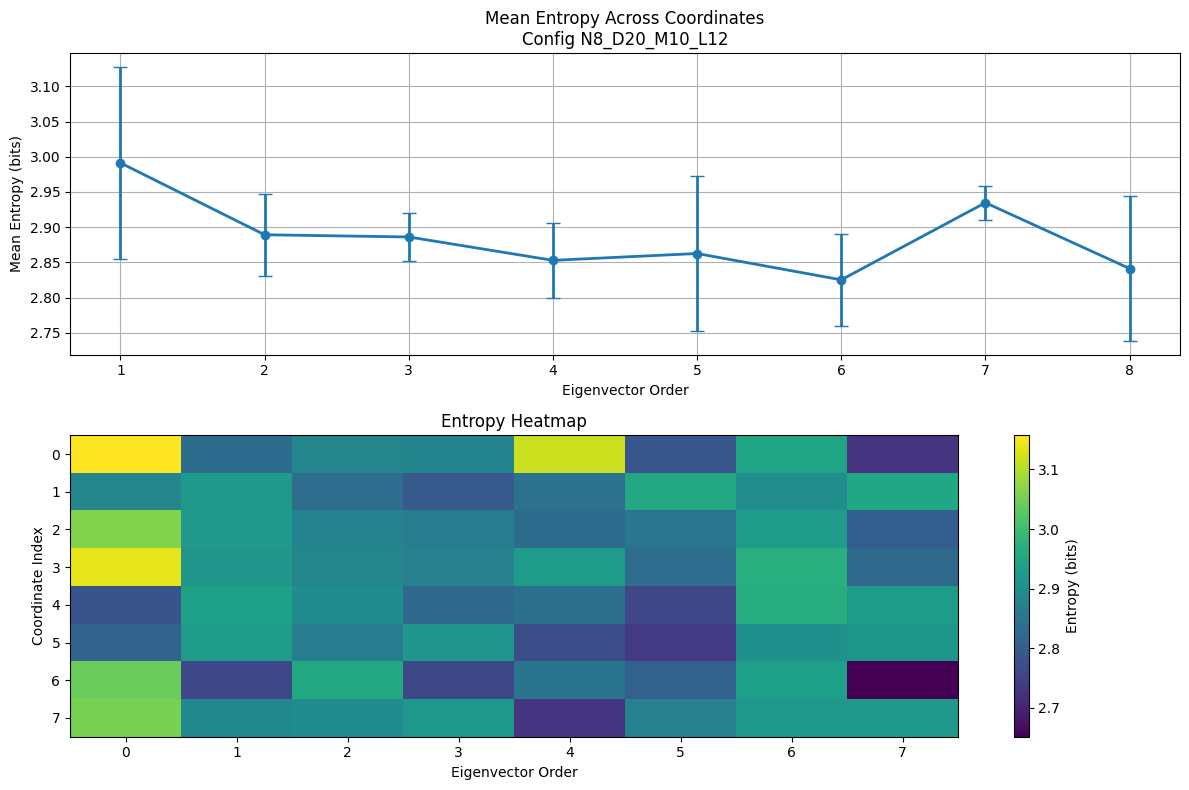

Processing experiment files:  30%|██▉       | 29/97 [00:18<00:44,  1.54it/s]


Entropy Statistics:
  Overall mean entropy: 2.8855 ± 0.0731 bits
  Max entropy: 3.1576 bits
  Min entropy: 2.6510 bits

Most random eigenvector: 1st
  Mean entropy: 2.9912 ± 0.1363 bits

Least random eigenvector: 6th
  Mean entropy: 2.8254 ± 0.0653 bits
Computing entropy for all eigenvector distributions - N8_D20_M200_L2


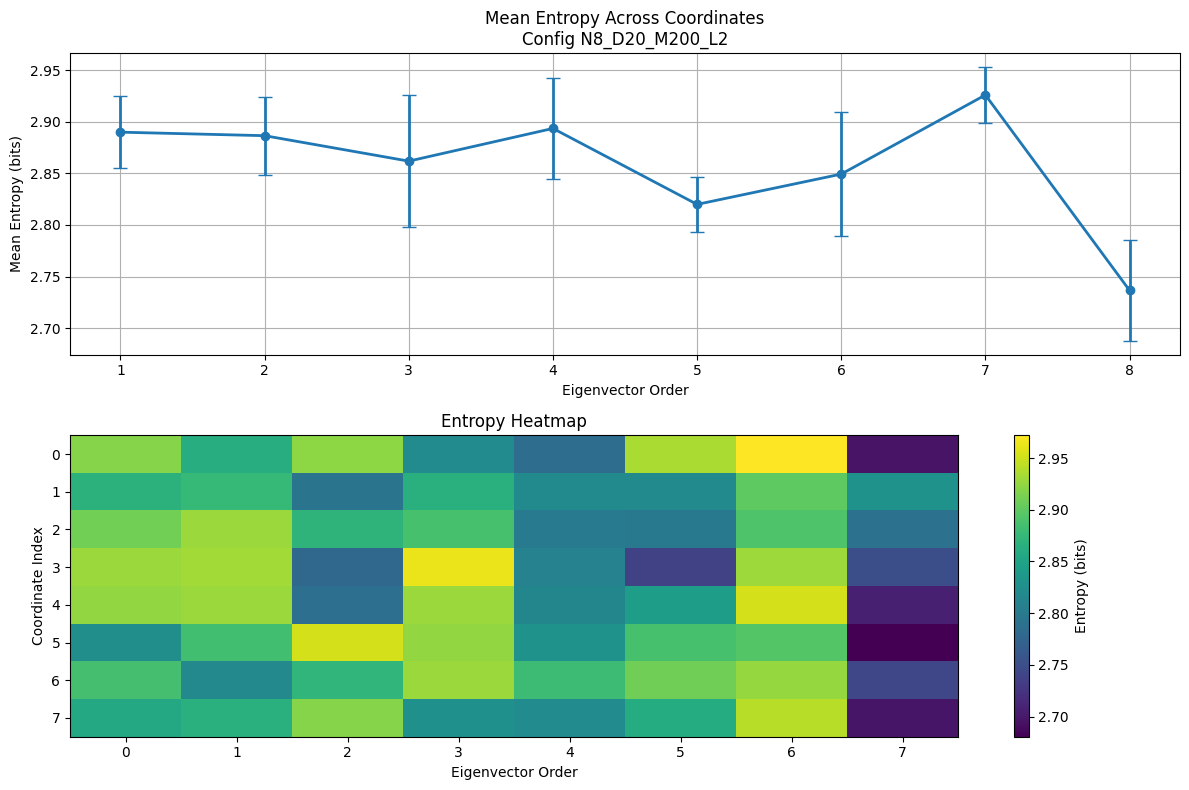

Processing experiment files:  31%|███       | 30/97 [00:19<00:42,  1.59it/s]


Entropy Statistics:
  Overall mean entropy: 2.8579 ± 0.0435 bits
  Max entropy: 2.9721 bits
  Min entropy: 2.6805 bits

Most random eigenvector: 7th
  Mean entropy: 2.9258 ± 0.0272 bits

Least random eigenvector: 8th
  Mean entropy: 2.7366 ± 0.0489 bits
Computing entropy for all eigenvector distributions - N8_D20_M10_L2


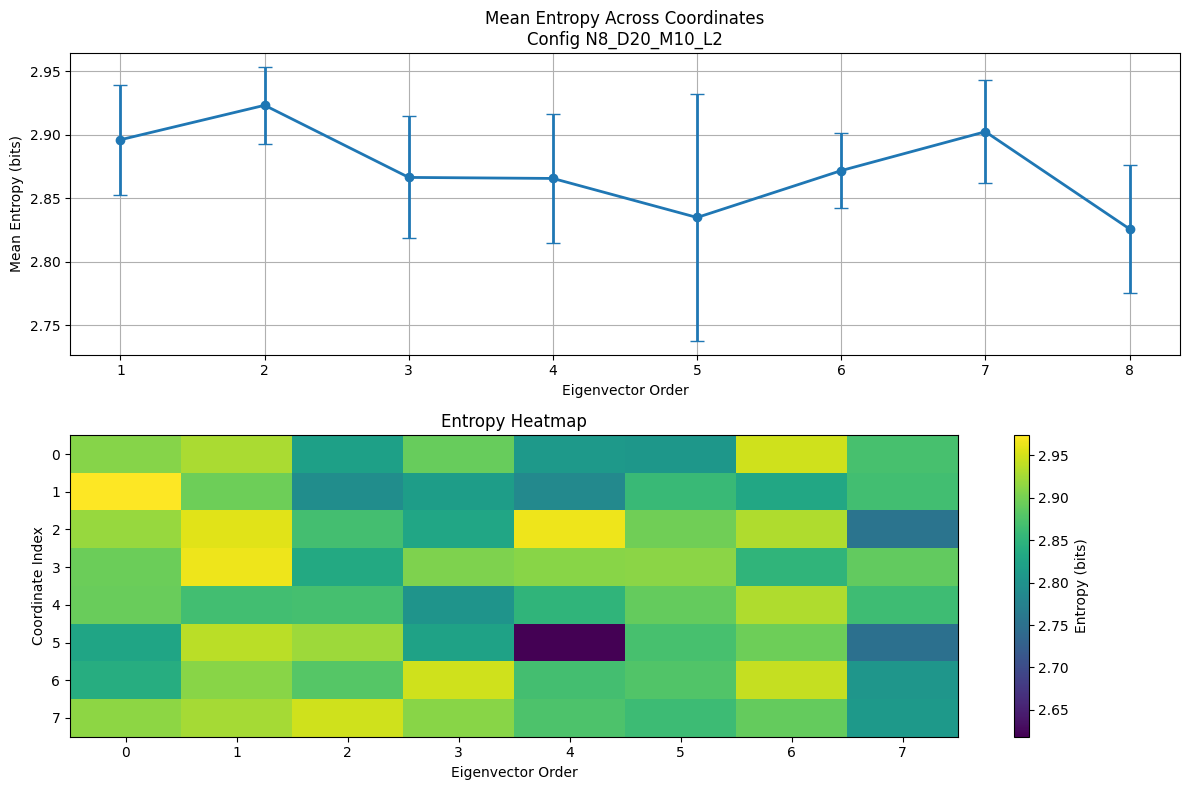

Processing experiment files:  32%|███▏      | 31/97 [00:20<00:41,  1.59it/s]


Entropy Statistics:
  Overall mean entropy: 2.8732 ± 0.0487 bits
  Max entropy: 2.9735 bits
  Min entropy: 2.6184 bits

Most random eigenvector: 2nd
  Mean entropy: 2.9231 ± 0.0302 bits

Least random eigenvector: 8th
  Mean entropy: 2.8259 ± 0.0502 bits
Computing entropy for all eigenvector distributions - N8_D100_M10_L4


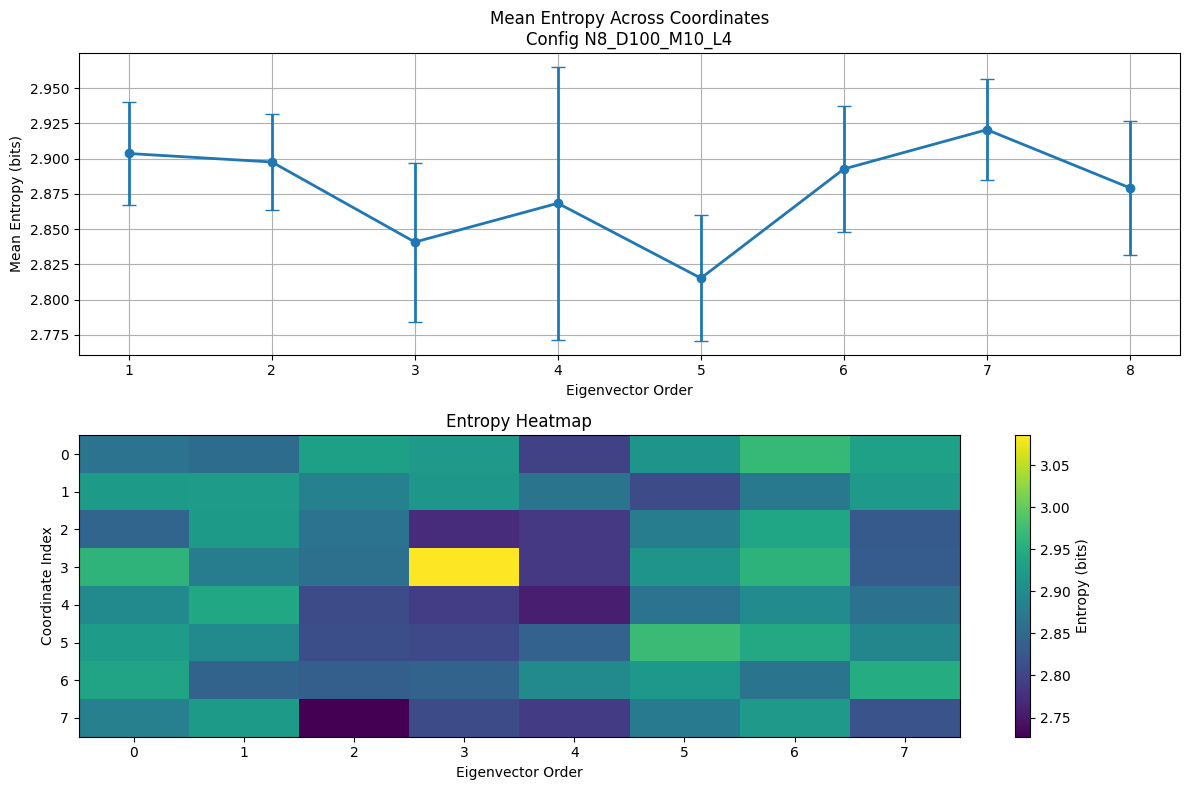


Entropy Statistics:
  Overall mean entropy: 2.8772 ± 0.0496 bits
  Max entropy: 3.0855 bits
  Min entropy: 2.7272 bits

Most random eigenvector: 7th
  Mean entropy: 2.9205 ± 0.0358 bits

Least random eigenvector: 5th
  Mean entropy: 2.8151 ± 0.0445 bits
Computing entropy for all eigenvector distributions - N8_D50_M10_L4


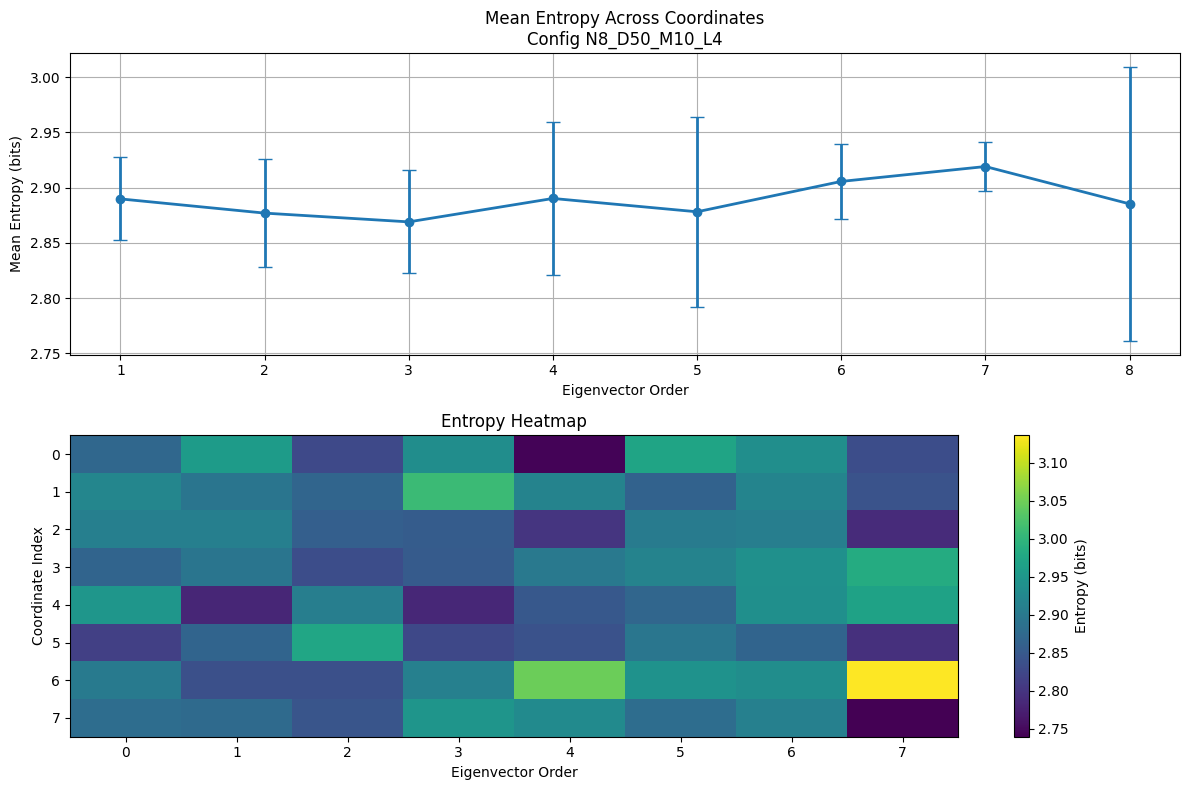

Processing experiment files:  34%|███▍      | 33/97 [00:20<00:25,  2.54it/s]


Entropy Statistics:
  Overall mean entropy: 2.8893 ± 0.0586 bits
  Max entropy: 3.1364 bits
  Min entropy: 2.7394 bits

Most random eigenvector: 7th
  Mean entropy: 2.9192 ± 0.0222 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8690 ± 0.0466 bits
Computing entropy for all eigenvector distributions - N8_D100_M20_L4


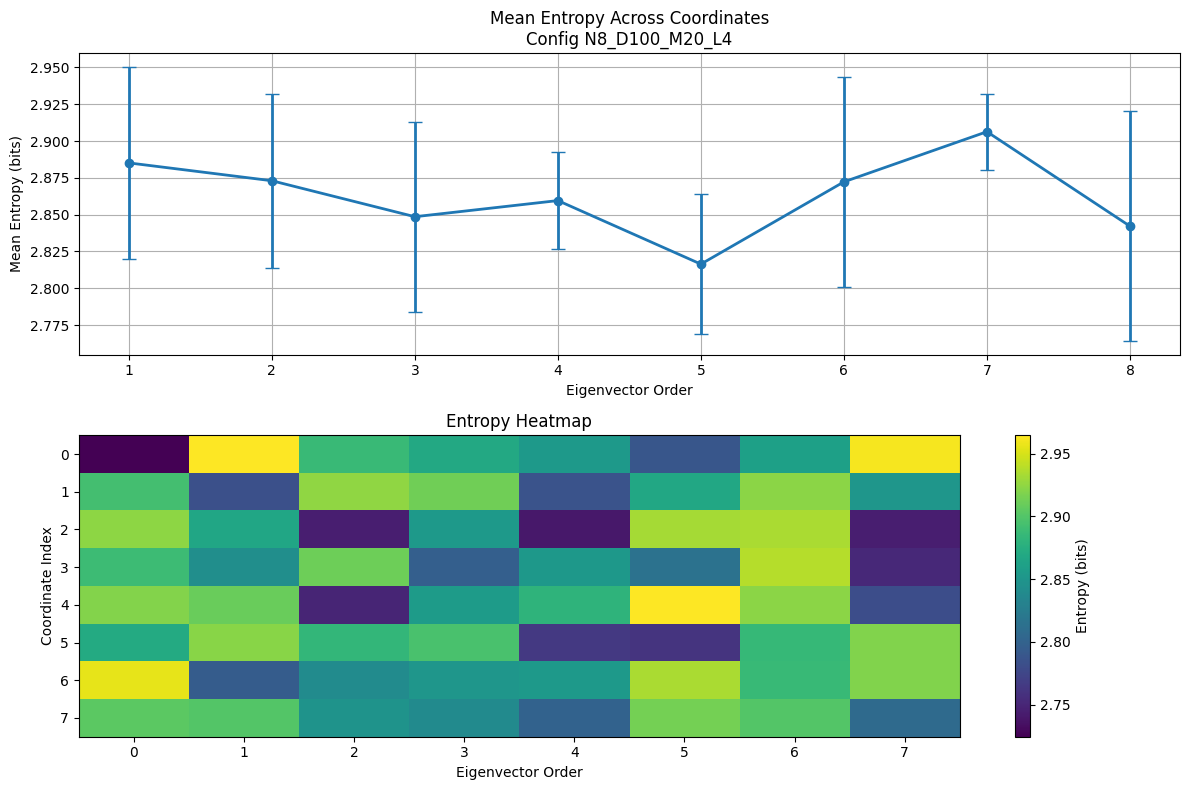

Processing experiment files:  35%|███▌      | 34/97 [00:21<00:28,  2.22it/s]


Entropy Statistics:
  Overall mean entropy: 2.8629 ± 0.0555 bits
  Max entropy: 2.9647 bits
  Min entropy: 2.7245 bits

Most random eigenvector: 7th
  Mean entropy: 2.9063 ± 0.0258 bits

Least random eigenvector: 5th
  Mean entropy: 2.8164 ± 0.0474 bits
Computing entropy for all eigenvector distributions - N8_D50_M100_L4


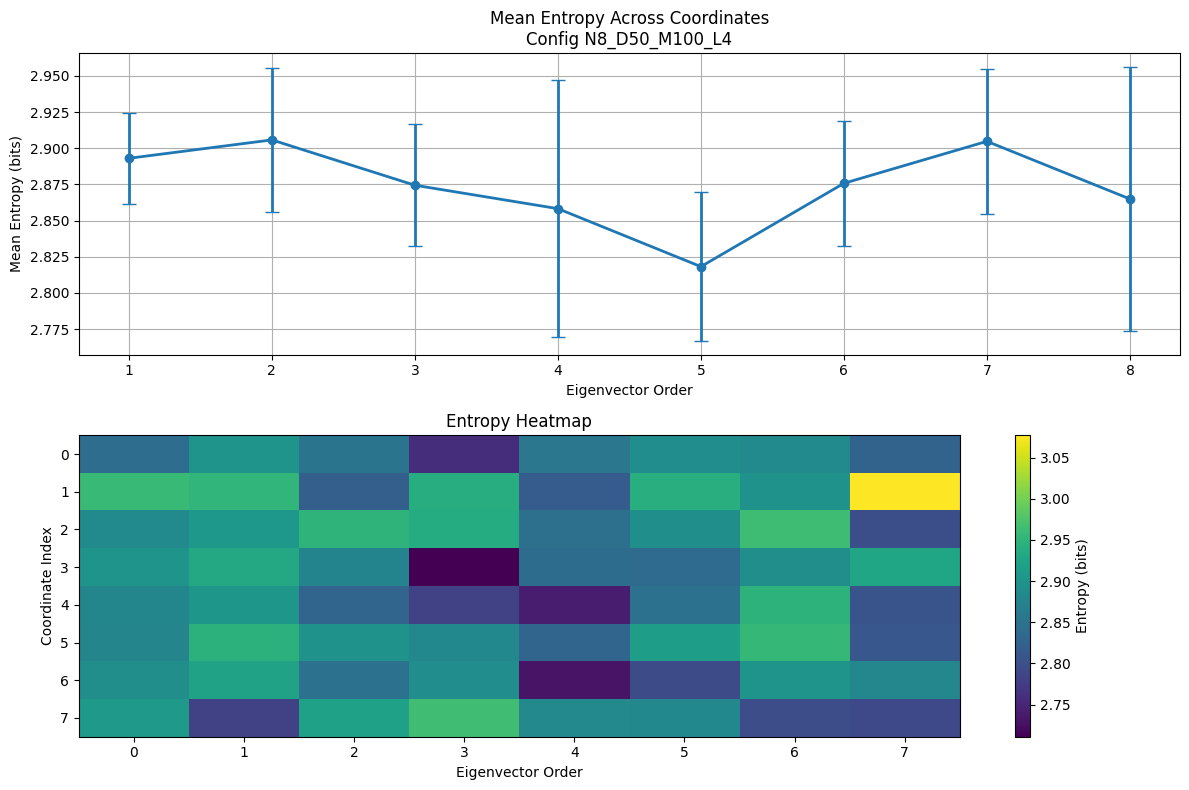

Processing experiment files:  36%|███▌      | 35/97 [00:21<00:31,  1.98it/s]


Entropy Statistics:
  Overall mean entropy: 2.8744 ± 0.0560 bits
  Max entropy: 3.0771 bits
  Min entropy: 2.7110 bits

Most random eigenvector: 2nd
  Mean entropy: 2.9057 ± 0.0499 bits

Least random eigenvector: 5th
  Mean entropy: 2.8181 ± 0.0514 bits
Computing entropy for all eigenvector distributions - N8_D20_M200_L4


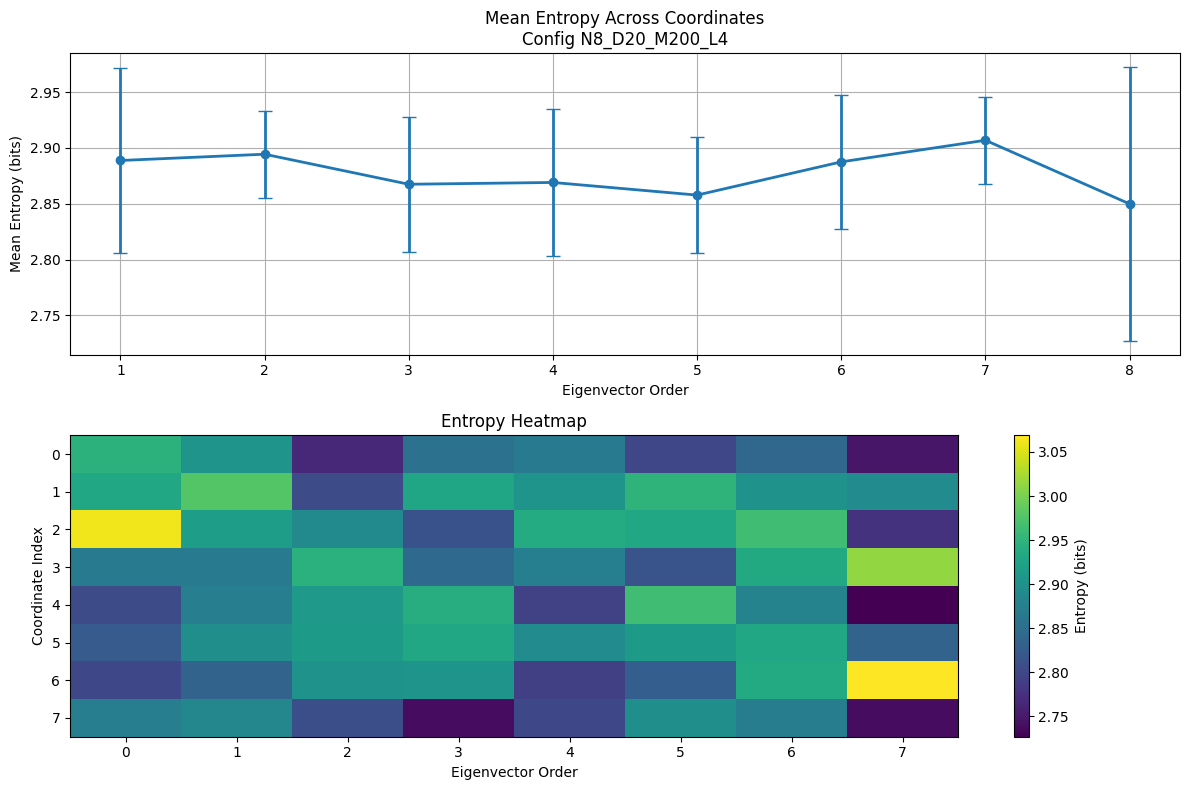

Processing experiment files:  37%|███▋      | 36/97 [00:22<00:32,  1.88it/s]


Entropy Statistics:
  Overall mean entropy: 2.8777 ± 0.0652 bits
  Max entropy: 3.0690 bits
  Min entropy: 2.7268 bits

Most random eigenvector: 7th
  Mean entropy: 2.9068 ± 0.0388 bits

Least random eigenvector: 8th
  Mean entropy: 2.8499 ± 0.1228 bits
Computing entropy for all eigenvector distributions - N8_D100_M10_L2


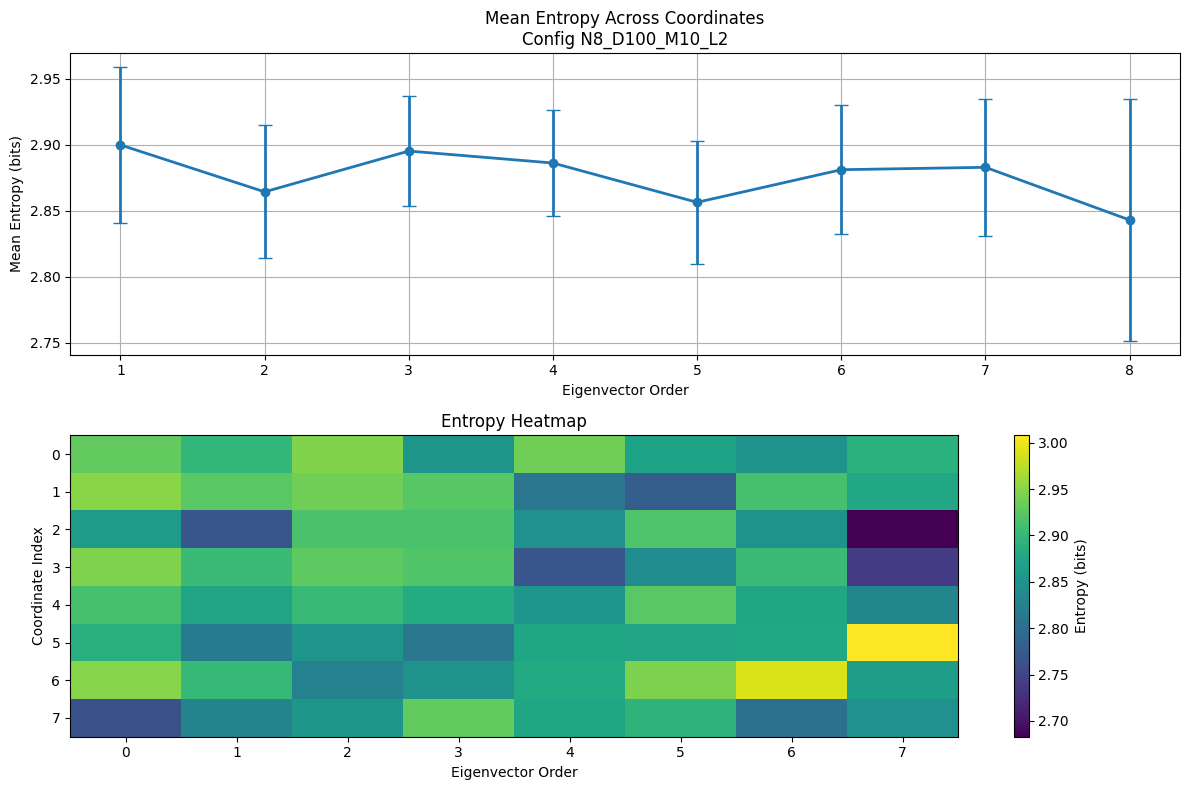

Processing experiment files:  38%|███▊      | 37/97 [00:22<00:33,  1.80it/s]


Entropy Statistics:
  Overall mean entropy: 2.8762 ± 0.0539 bits
  Max entropy: 3.0081 bits
  Min entropy: 2.6830 bits

Most random eigenvector: 1st
  Mean entropy: 2.9000 ± 0.0592 bits

Least random eigenvector: 8th
  Mean entropy: 2.8430 ± 0.0917 bits
Computing entropy for all eigenvector distributions - N8_D50_M10_L6


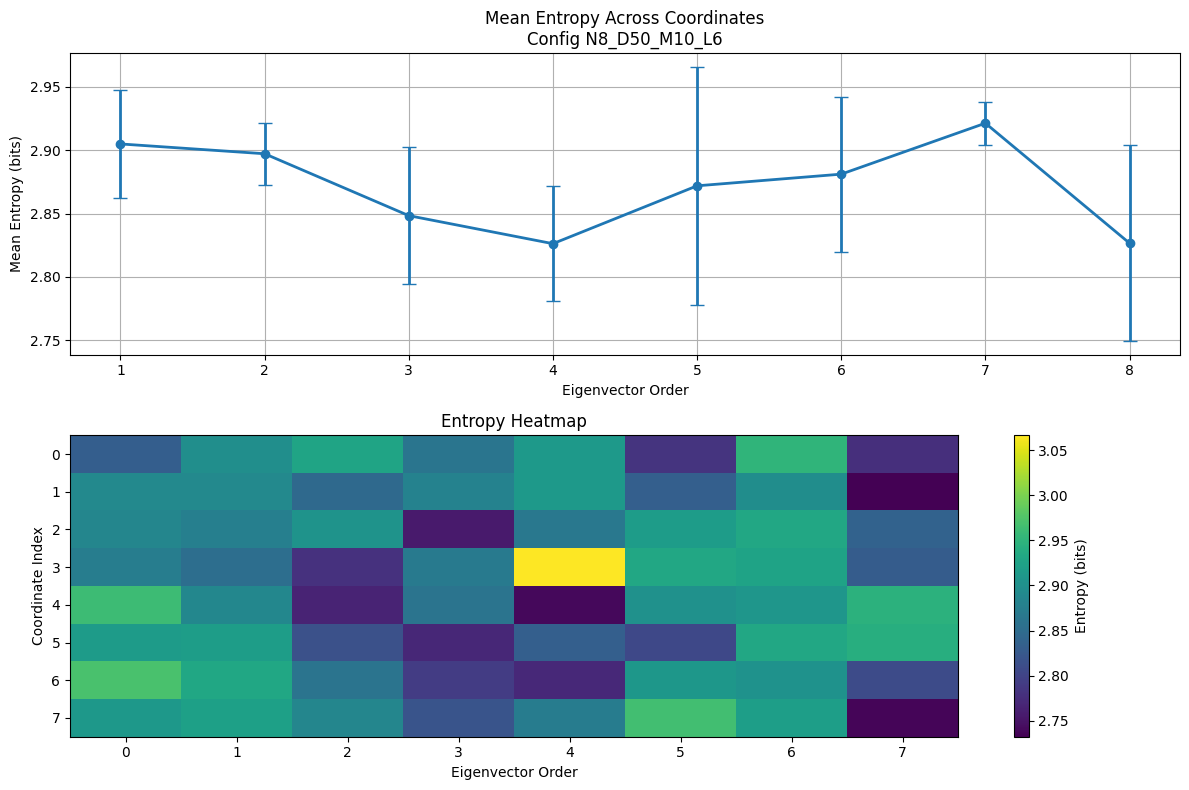

Processing experiment files:  39%|███▉      | 38/97 [00:23<00:34,  1.70it/s]


Entropy Statistics:
  Overall mean entropy: 2.8722 ± 0.0520 bits
  Max entropy: 3.0666 bits
  Min entropy: 2.7323 bits

Most random eigenvector: 7th
  Mean entropy: 2.9213 ± 0.0171 bits

Least random eigenvector: 4th
  Mean entropy: 2.8262 ± 0.0455 bits
Computing entropy for all eigenvector distributions - N8_D20_M20_L4


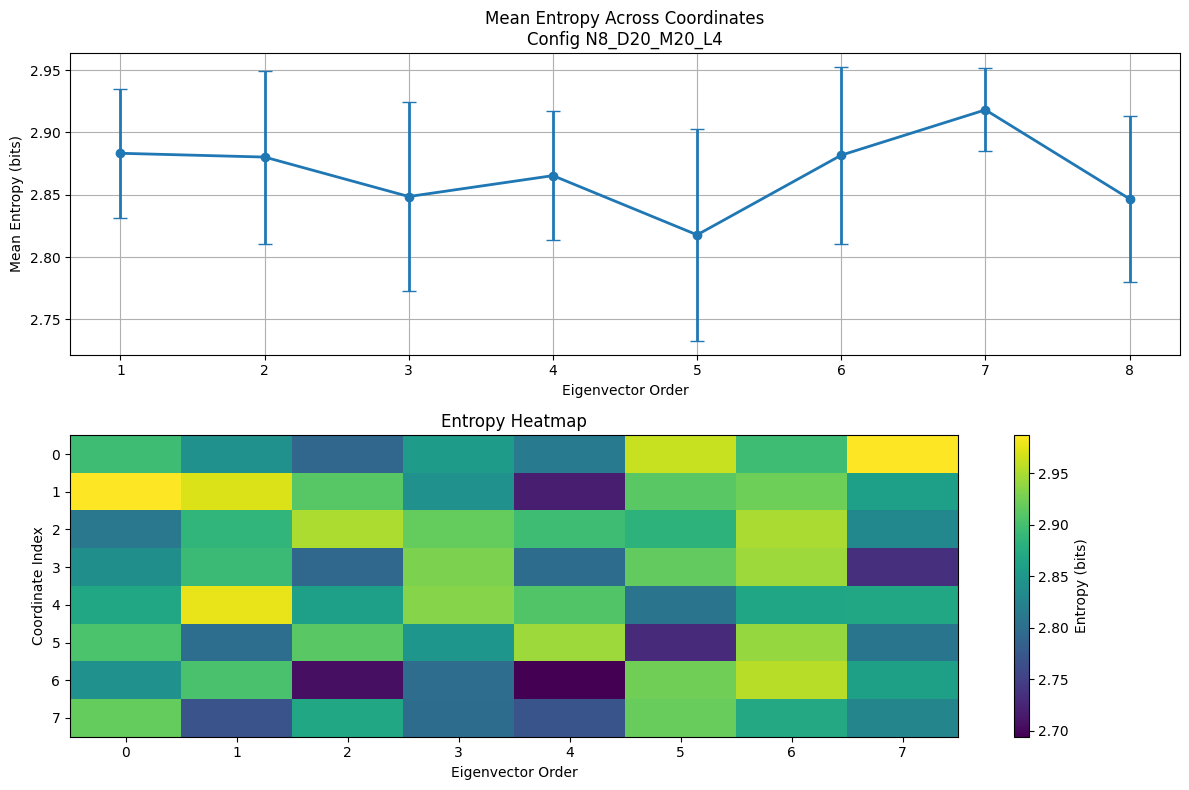

Processing experiment files:  40%|████      | 39/97 [00:24<00:39,  1.46it/s]


Entropy Statistics:
  Overall mean entropy: 2.8677 ± 0.0630 bits
  Max entropy: 2.9868 bits
  Min entropy: 2.6940 bits

Most random eigenvector: 7th
  Mean entropy: 2.9181 ± 0.0334 bits

Least random eigenvector: 5th
  Mean entropy: 2.8178 ± 0.0851 bits
Computing entropy for all eigenvector distributions - N8_D200_M10_L4


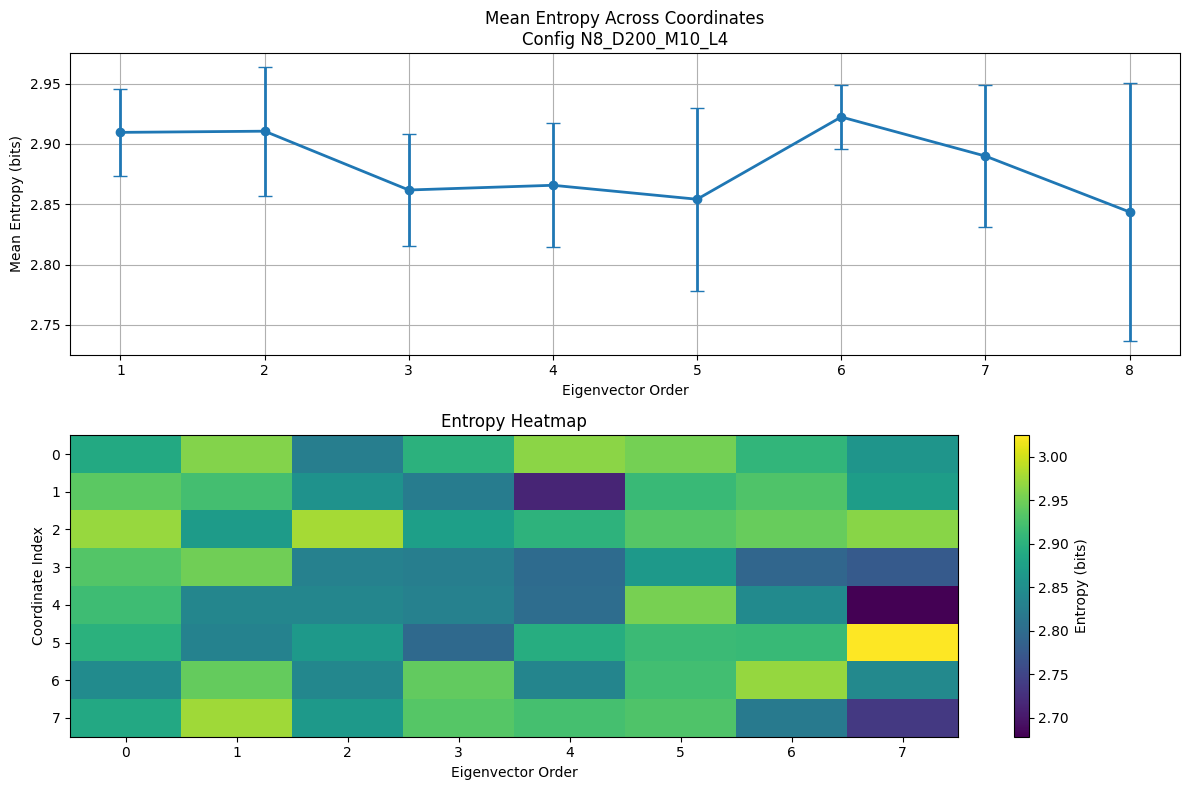

Processing experiment files:  41%|████      | 40/97 [00:25<00:37,  1.51it/s]


Entropy Statistics:
  Overall mean entropy: 2.8822 ± 0.0568 bits
  Max entropy: 3.0247 bits
  Min entropy: 2.6780 bits

Most random eigenvector: 6th
  Mean entropy: 2.9223 ± 0.0263 bits

Least random eigenvector: 8th
  Mean entropy: 2.8437 ± 0.1069 bits
Computing entropy for all eigenvector distributions - N8_D100_M100_L2


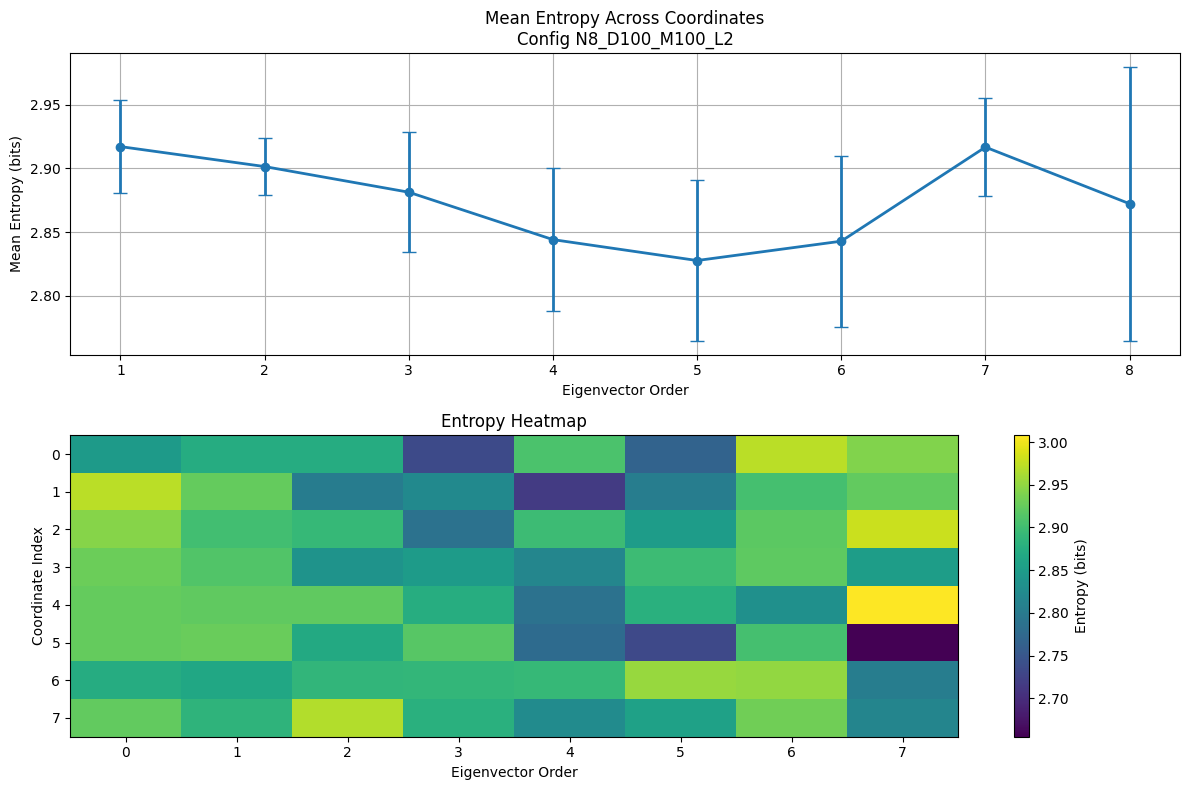

Processing experiment files:  42%|████▏     | 41/97 [00:25<00:36,  1.55it/s]


Entropy Statistics:
  Overall mean entropy: 2.8754 ± 0.0548 bits
  Max entropy: 3.0079 bits
  Min entropy: 2.6550 bits

Most random eigenvector: 1st
  Mean entropy: 2.9171 ± 0.0365 bits

Least random eigenvector: 5th
  Mean entropy: 2.8276 ± 0.0632 bits
Computing entropy for all eigenvector distributions - N8_D20_M50_L8


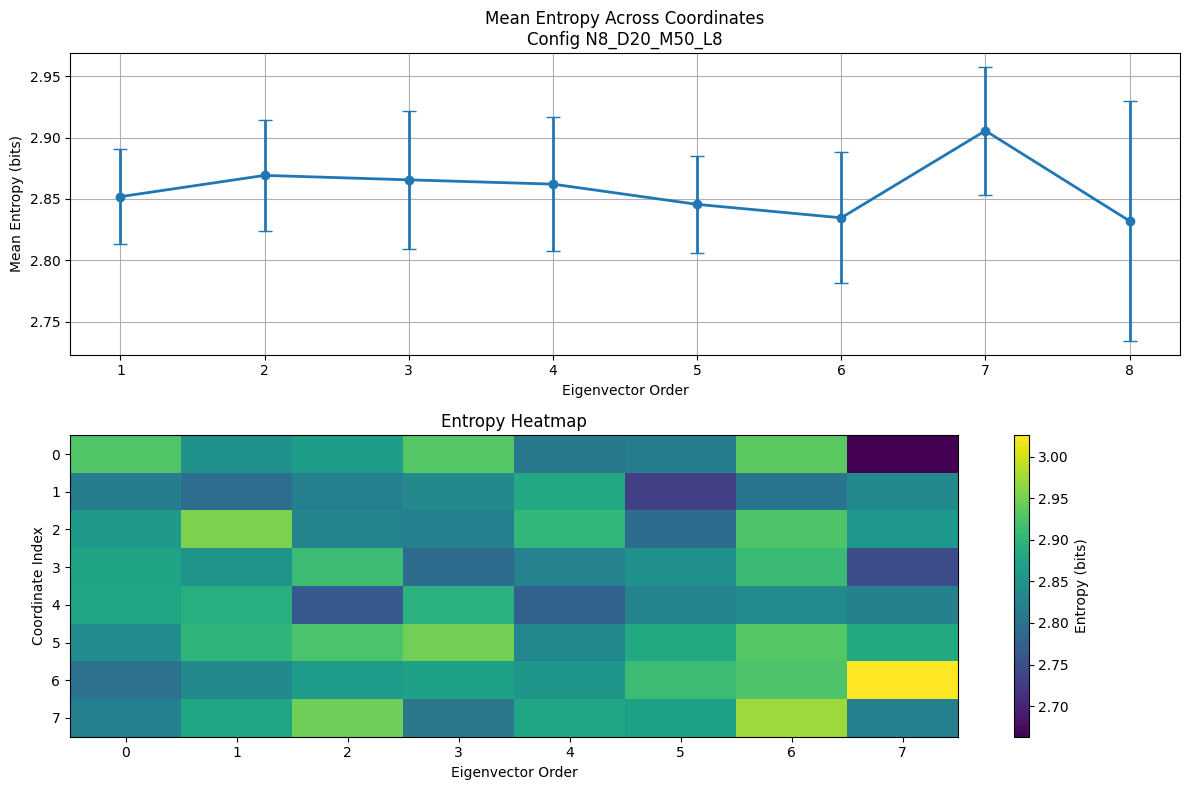

Processing experiment files:  43%|████▎     | 42/97 [00:26<00:34,  1.60it/s]


Entropy Statistics:
  Overall mean entropy: 2.8583 ± 0.0547 bits
  Max entropy: 3.0261 bits
  Min entropy: 2.6630 bits

Most random eigenvector: 7th
  Mean entropy: 2.9056 ± 0.0521 bits

Least random eigenvector: 8th
  Mean entropy: 2.8320 ± 0.0978 bits
Computing entropy for all eigenvector distributions - N8_D500_M10_L2


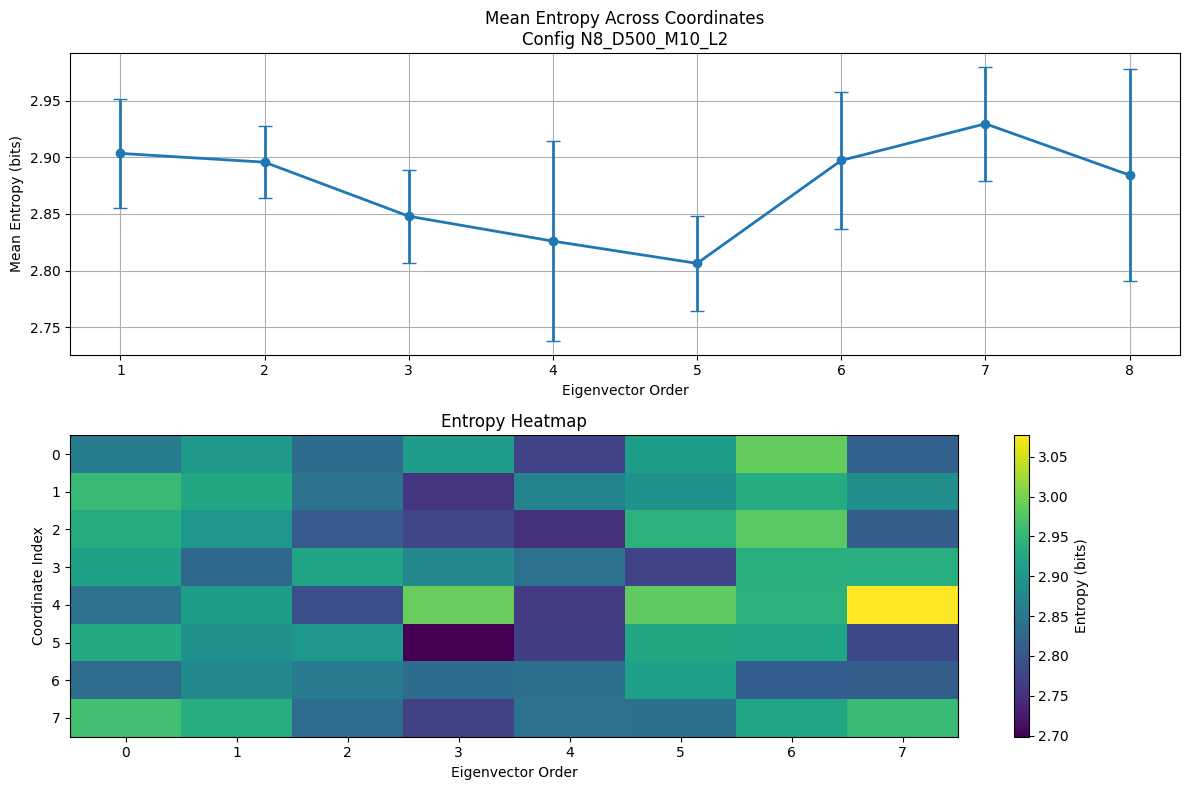

Processing experiment files:  44%|████▍     | 43/97 [00:26<00:33,  1.60it/s]


Entropy Statistics:
  Overall mean entropy: 2.8738 ± 0.0569 bits
  Max entropy: 3.0769 bits
  Min entropy: 2.6987 bits

Most random eigenvector: 7th
  Mean entropy: 2.9296 ± 0.0502 bits

Least random eigenvector: 5th
  Mean entropy: 2.8064 ± 0.0422 bits
Computing entropy for all eigenvector distributions - N8_D100_M10_L8


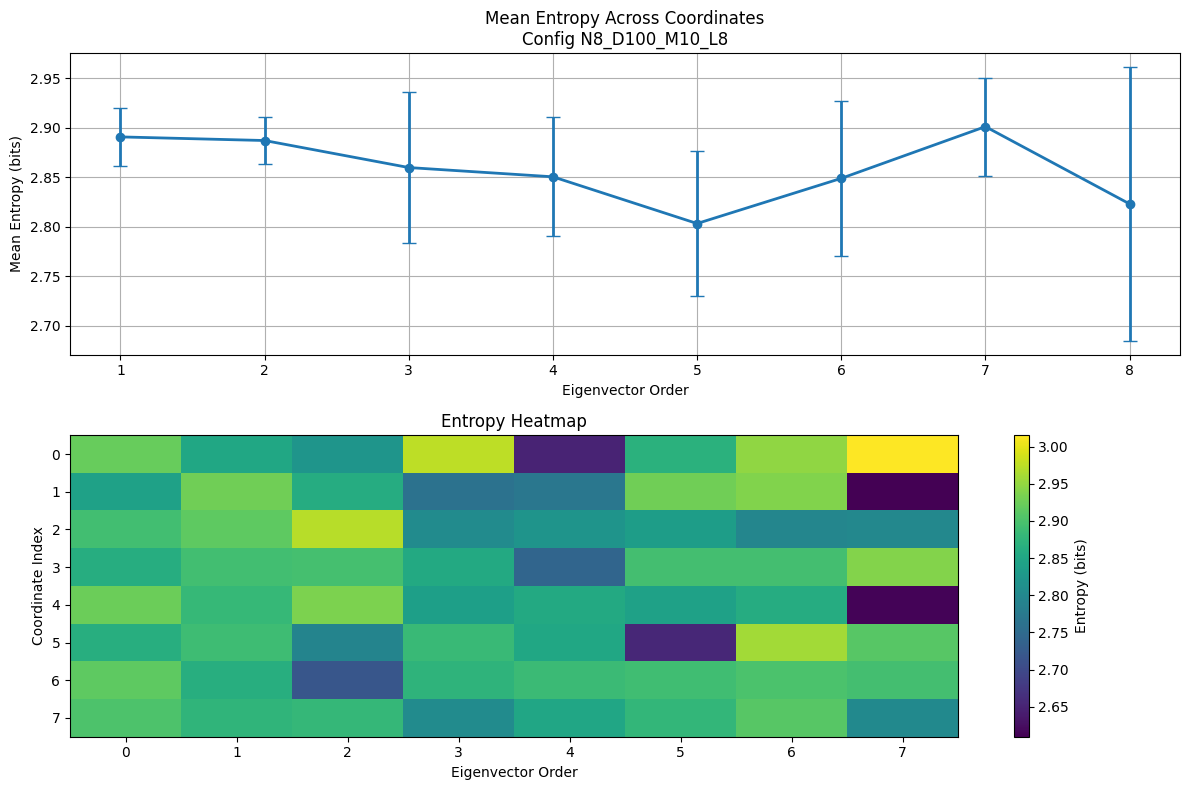

Processing experiment files:  45%|████▌     | 44/97 [00:27<00:32,  1.61it/s]


Entropy Statistics:
  Overall mean entropy: 2.8579 ± 0.0660 bits
  Max entropy: 3.0154 bits
  Min entropy: 2.6097 bits

Most random eigenvector: 7th
  Mean entropy: 2.9010 ± 0.0495 bits

Least random eigenvector: 5th
  Mean entropy: 2.8031 ± 0.0731 bits
Computing entropy for all eigenvector distributions - N8_D20_M20_L10


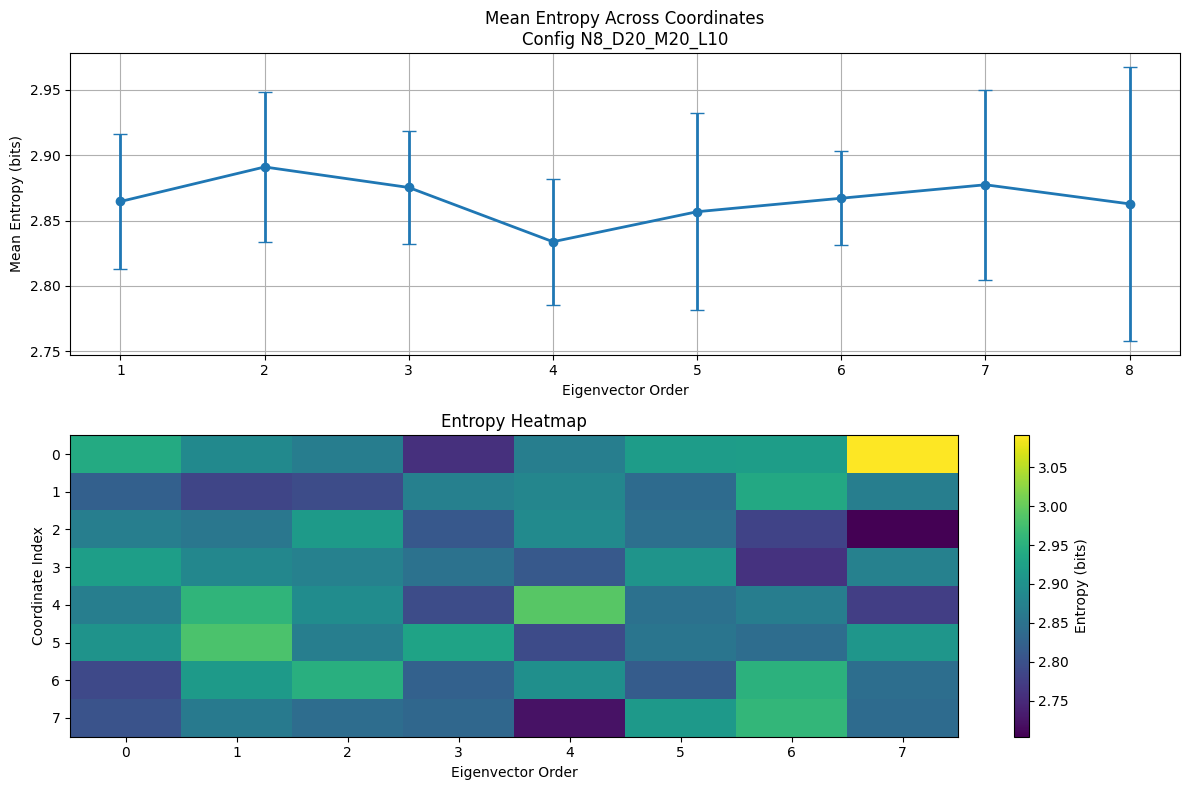

Processing experiment files:  46%|████▋     | 45/97 [00:28<00:32,  1.59it/s]


Entropy Statistics:
  Overall mean entropy: 2.8661 ± 0.0612 bits
  Max entropy: 3.0910 bits
  Min entropy: 2.7037 bits

Most random eigenvector: 2nd
  Mean entropy: 2.8910 ± 0.0573 bits

Least random eigenvector: 4th
  Mean entropy: 2.8337 ± 0.0484 bits
Computing entropy for all eigenvector distributions - N8_D20_M500_L2


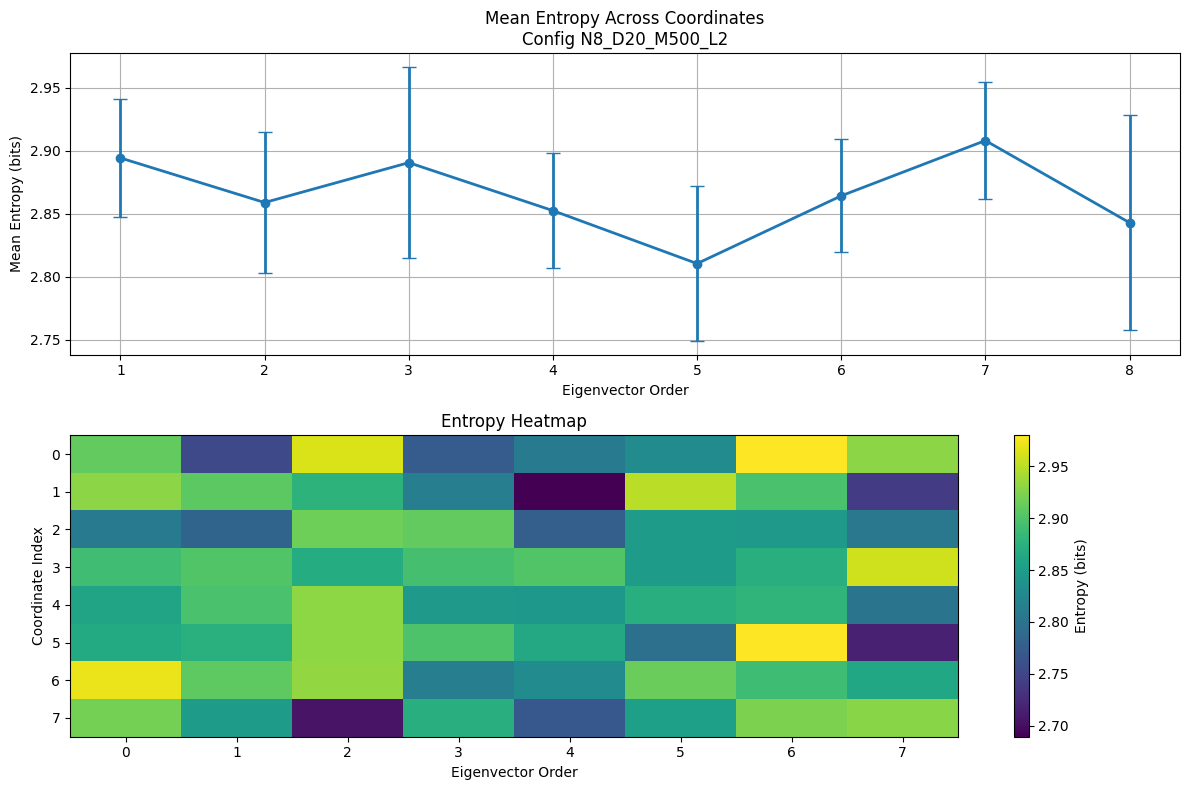

Processing experiment files:  47%|████▋     | 46/97 [00:28<00:30,  1.65it/s]


Entropy Statistics:
  Overall mean entropy: 2.8653 ± 0.0578 bits
  Max entropy: 2.9800 bits
  Min entropy: 2.6893 bits

Most random eigenvector: 7th
  Mean entropy: 2.9082 ± 0.0461 bits

Least random eigenvector: 5th
  Mean entropy: 2.8105 ± 0.0614 bits
Computing entropy for all eigenvector distributions - N8_D200_M20_L4


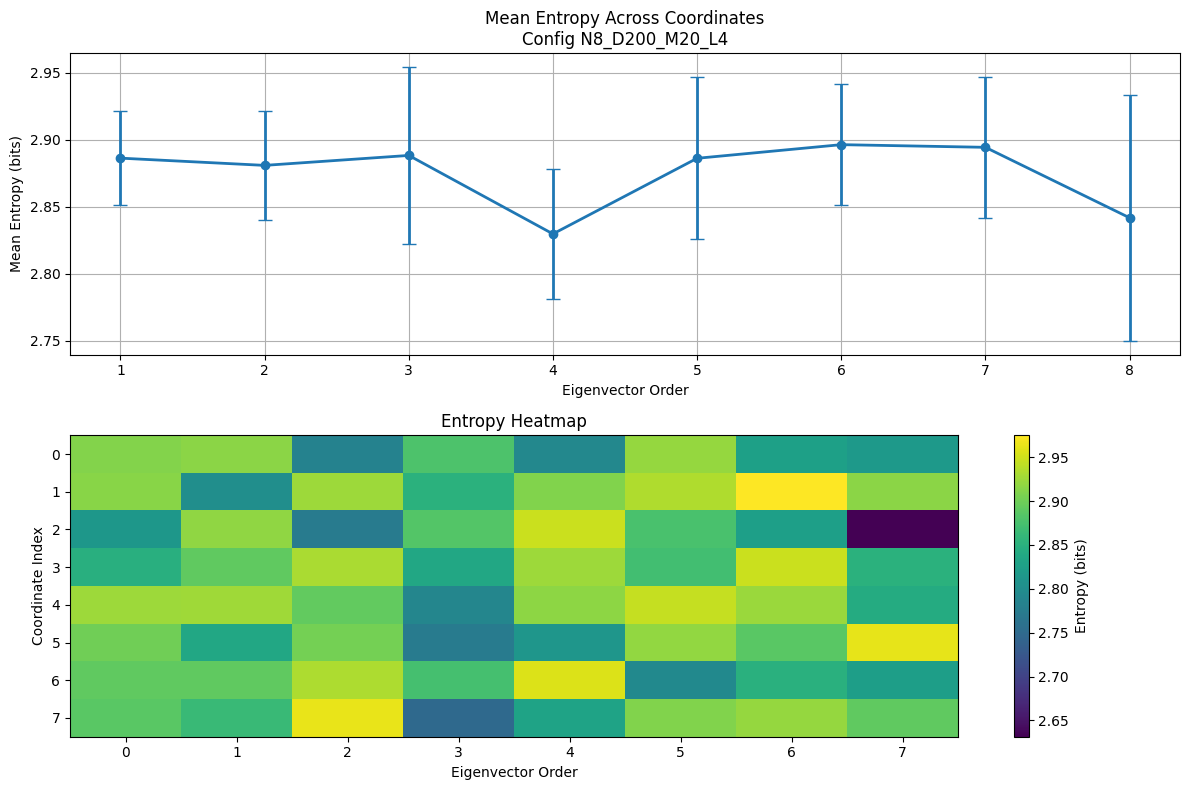

Processing experiment files:  48%|████▊     | 47/97 [00:29<00:30,  1.65it/s]


Entropy Statistics:
  Overall mean entropy: 2.8755 ± 0.0551 bits
  Max entropy: 2.9751 bits
  Min entropy: 2.6313 bits

Most random eigenvector: 6th
  Mean entropy: 2.8964 ± 0.0452 bits

Least random eigenvector: 4th
  Mean entropy: 2.8297 ± 0.0487 bits
Computing entropy for all eigenvector distributions - N8_D20_M20_L2


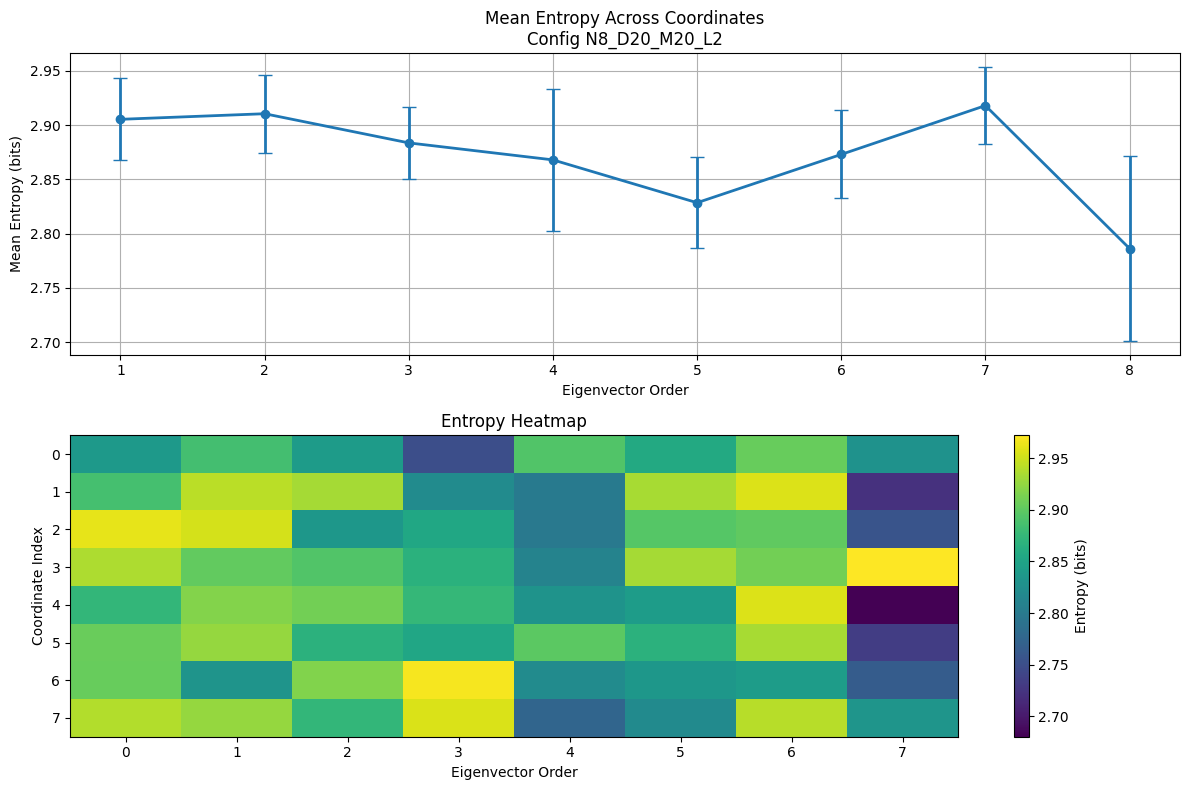

Processing experiment files:  49%|████▉     | 48/97 [00:29<00:30,  1.63it/s]


Entropy Statistics:
  Overall mean entropy: 2.8716 ± 0.0470 bits
  Max entropy: 2.9720 bits
  Min entropy: 2.6803 bits

Most random eigenvector: 7th
  Mean entropy: 2.9179 ± 0.0357 bits

Least random eigenvector: 8th
  Mean entropy: 2.7862 ± 0.0852 bits
Computing entropy for all eigenvector distributions - N8_D20_M100_L4


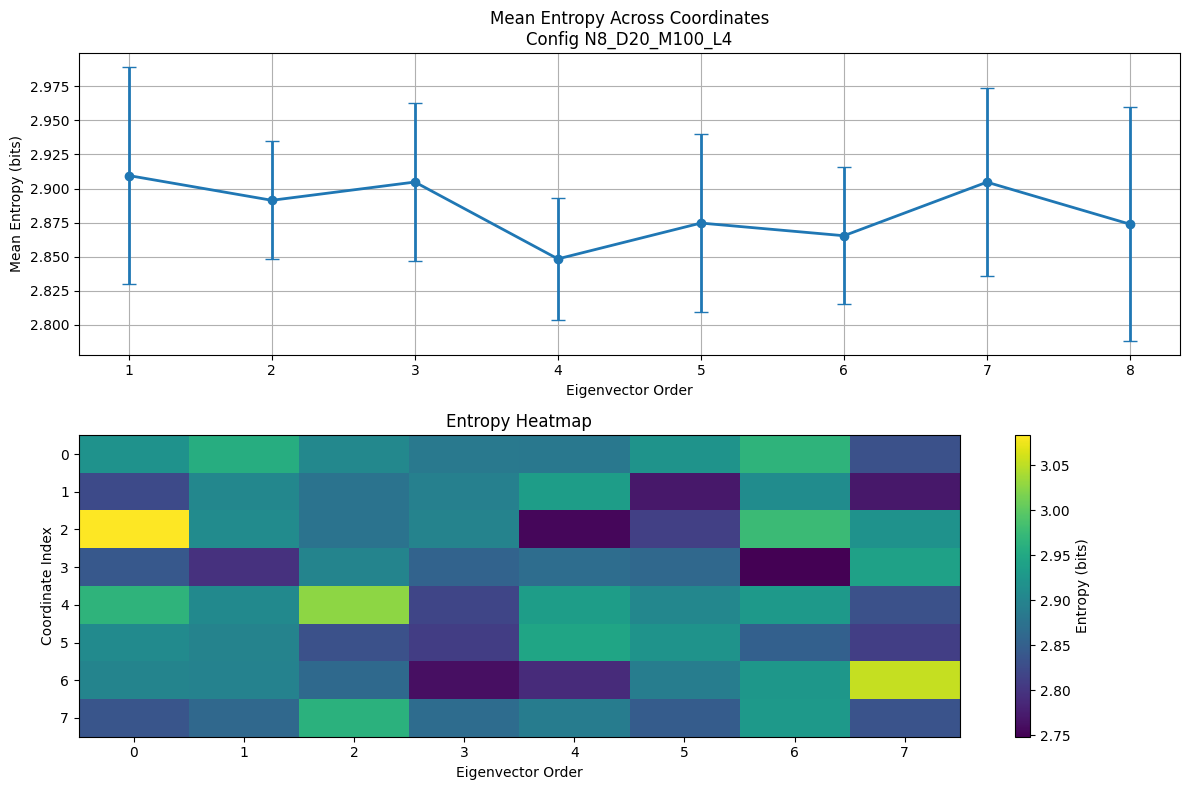

Processing experiment files:  51%|█████     | 49/97 [00:30<00:29,  1.61it/s]


Entropy Statistics:
  Overall mean entropy: 2.8840 ± 0.0621 bits
  Max entropy: 3.0832 bits
  Min entropy: 2.7481 bits

Most random eigenvector: 1st
  Mean entropy: 2.9095 ± 0.0798 bits

Least random eigenvector: 4th
  Mean entropy: 2.8483 ± 0.0449 bits
Computing entropy for all eigenvector distributions - N8_D100_M50_L2


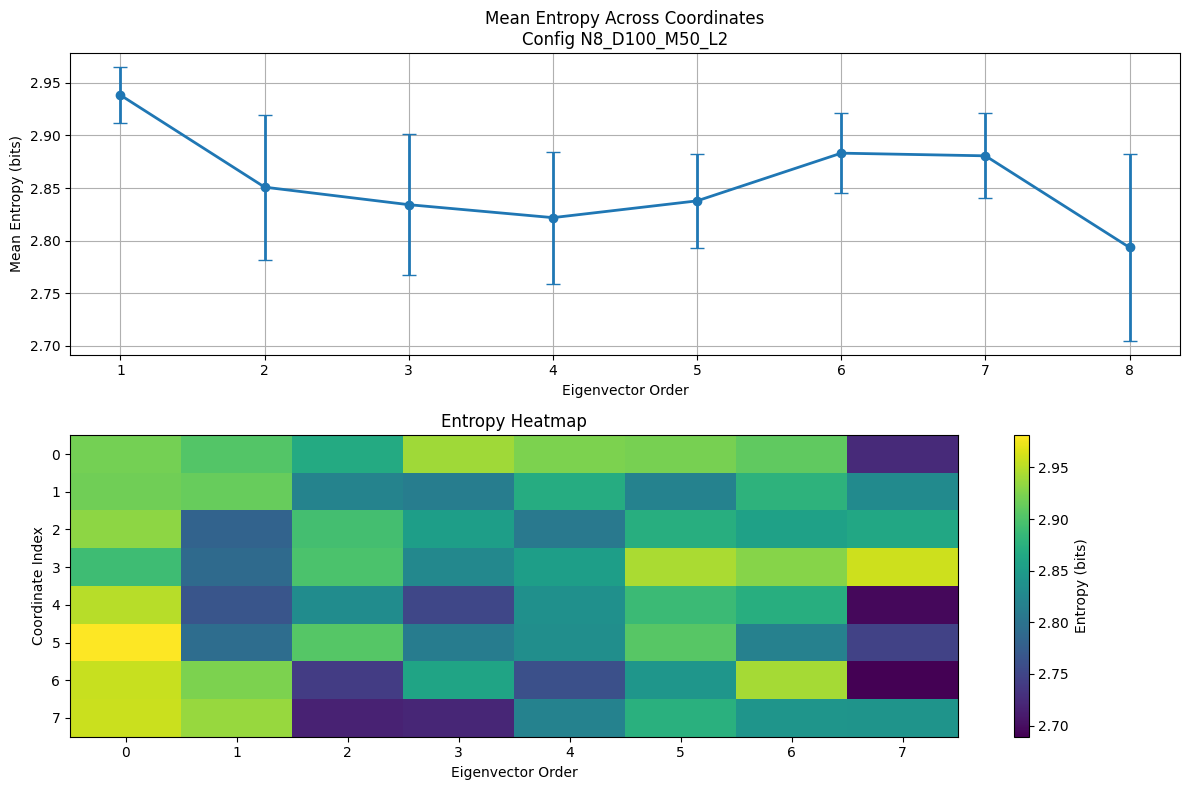

Processing experiment files:  52%|█████▏    | 50/97 [00:31<00:32,  1.45it/s]


Entropy Statistics:
  Overall mean entropy: 2.8551 ± 0.0548 bits
  Max entropy: 2.9812 bits
  Min entropy: 2.6892 bits

Most random eigenvector: 1st
  Mean entropy: 2.9384 ± 0.0269 bits

Least random eigenvector: 8th
  Mean entropy: 2.7935 ± 0.0889 bits
Computing entropy for all eigenvector distributions - N8_D200_M10_L6


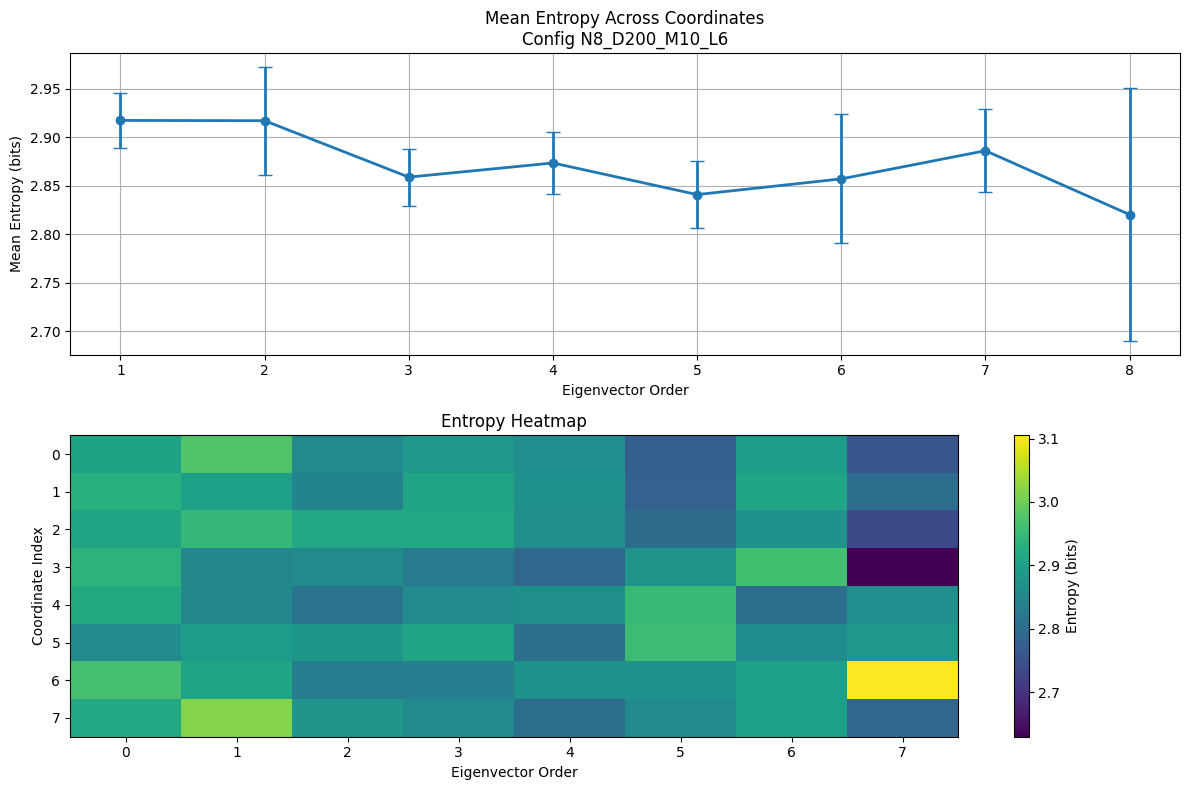

Processing experiment files:  53%|█████▎    | 51/97 [00:32<00:30,  1.51it/s]


Entropy Statistics:
  Overall mean entropy: 2.8715 ± 0.0524 bits
  Max entropy: 3.1054 bits
  Min entropy: 2.6295 bits

Most random eigenvector: 1st
  Mean entropy: 2.9175 ± 0.0287 bits

Least random eigenvector: 8th
  Mean entropy: 2.8204 ± 0.1303 bits
Computing entropy for all eigenvector distributions - N8_D20_M10_L10


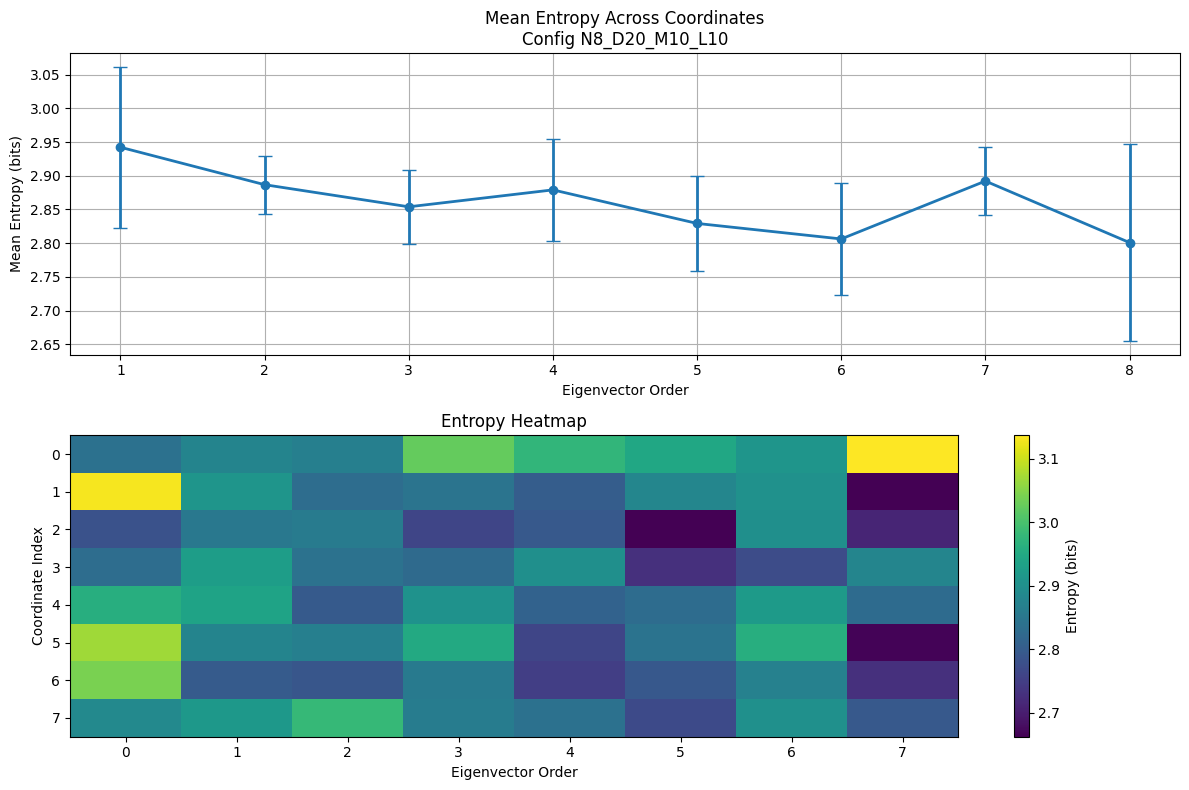

Processing experiment files:  54%|█████▎    | 52/97 [00:32<00:29,  1.54it/s]


Entropy Statistics:
  Overall mean entropy: 2.8612 ± 0.0804 bits
  Max entropy: 3.1372 bits
  Min entropy: 2.6619 bits

Most random eigenvector: 1st
  Mean entropy: 2.9422 ± 0.1193 bits

Least random eigenvector: 8th
  Mean entropy: 2.8008 ± 0.1459 bits
Computing entropy for all eigenvector distributions - N8_D500_M10_L4


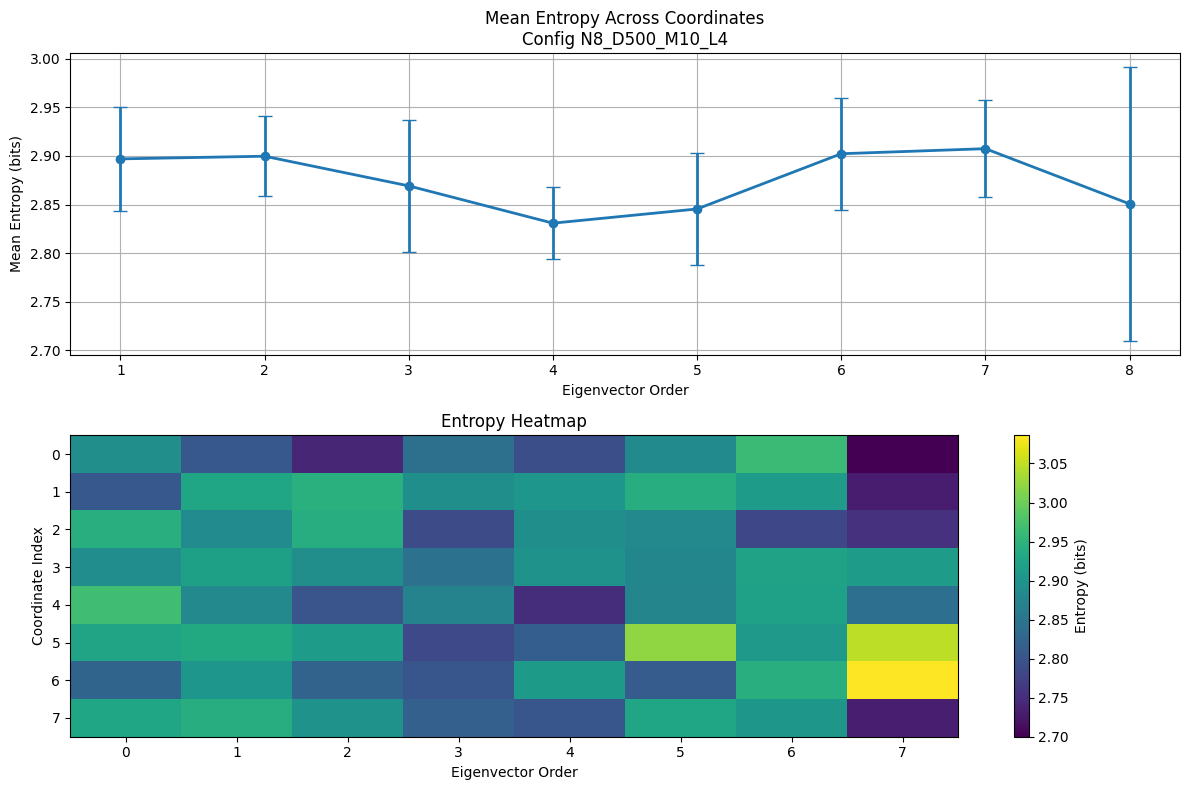

Processing experiment files:  55%|█████▍    | 53/97 [00:33<00:27,  1.59it/s]


Entropy Statistics:
  Overall mean entropy: 2.8753 ± 0.0633 bits
  Max entropy: 3.0862 bits
  Min entropy: 2.6998 bits

Most random eigenvector: 7th
  Mean entropy: 2.9074 ± 0.0500 bits

Least random eigenvector: 4th
  Mean entropy: 2.8308 ± 0.0367 bits
Computing entropy for all eigenvector distributions - N8_D50_M20_L2


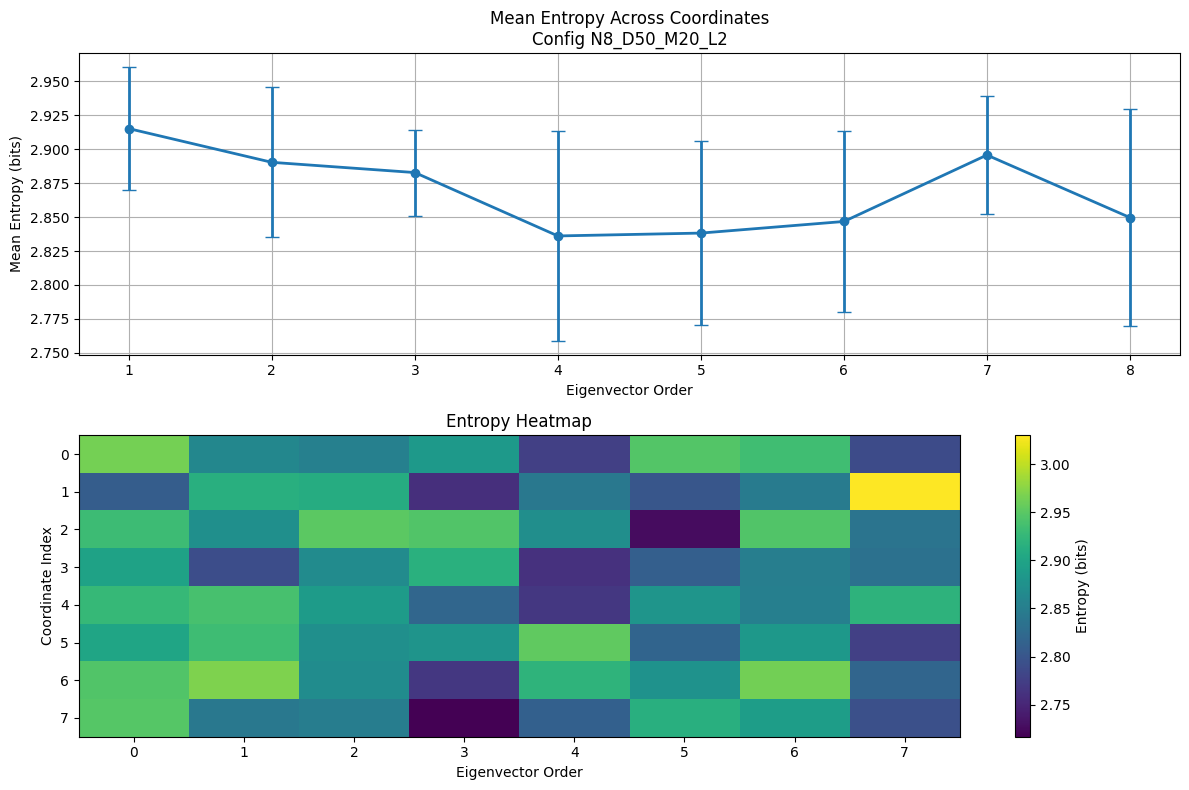

Processing experiment files:  56%|█████▌    | 54/97 [00:33<00:26,  1.61it/s]


Entropy Statistics:
  Overall mean entropy: 2.8694 ± 0.0584 bits
  Max entropy: 3.0303 bits
  Min entropy: 2.7165 bits

Most random eigenvector: 1st
  Mean entropy: 2.9152 ± 0.0455 bits

Least random eigenvector: 4th
  Mean entropy: 2.8361 ± 0.0774 bits
Computing entropy for all eigenvector distributions - N8_D50_M20_L8


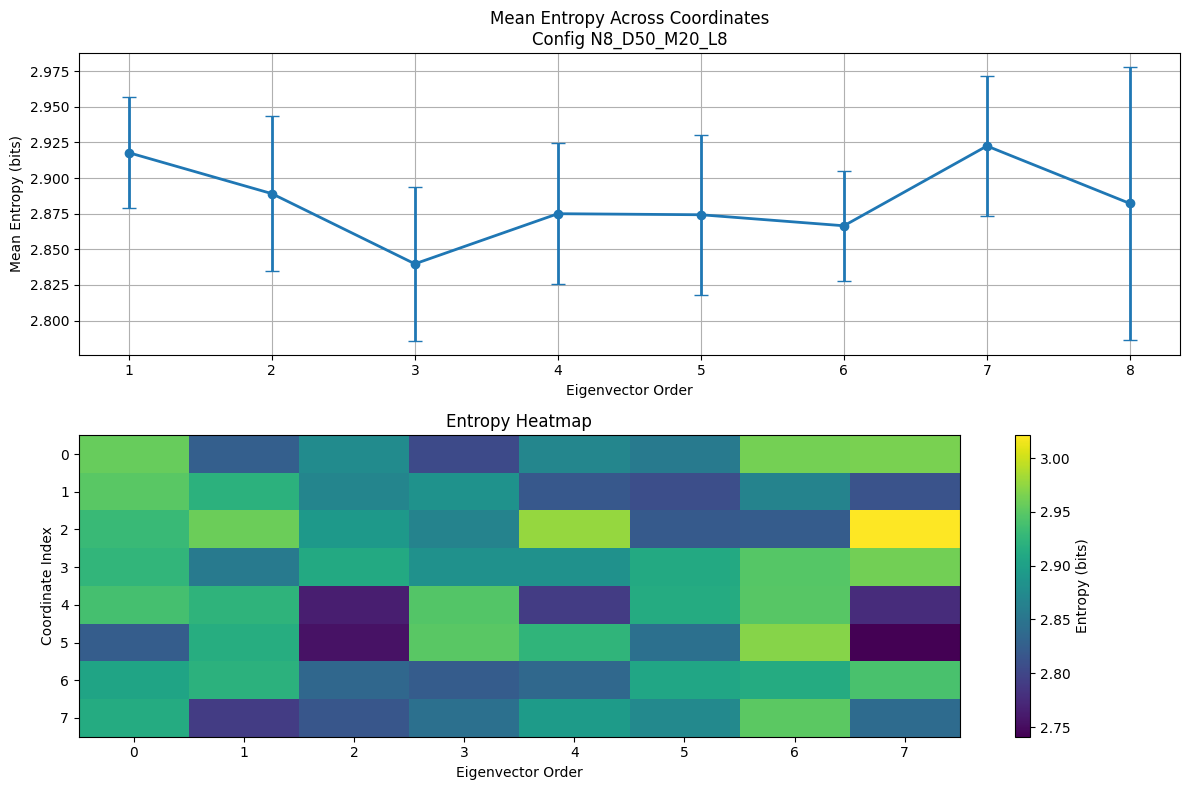

Processing experiment files:  57%|█████▋    | 55/97 [00:34<00:25,  1.62it/s]


Entropy Statistics:
  Overall mean entropy: 2.8834 ± 0.0546 bits
  Max entropy: 3.0212 bits
  Min entropy: 2.7410 bits

Most random eigenvector: 7th
  Mean entropy: 2.9225 ± 0.0491 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8398 ± 0.0541 bits
Computing entropy for all eigenvector distributions - N8_D50_M100_L2


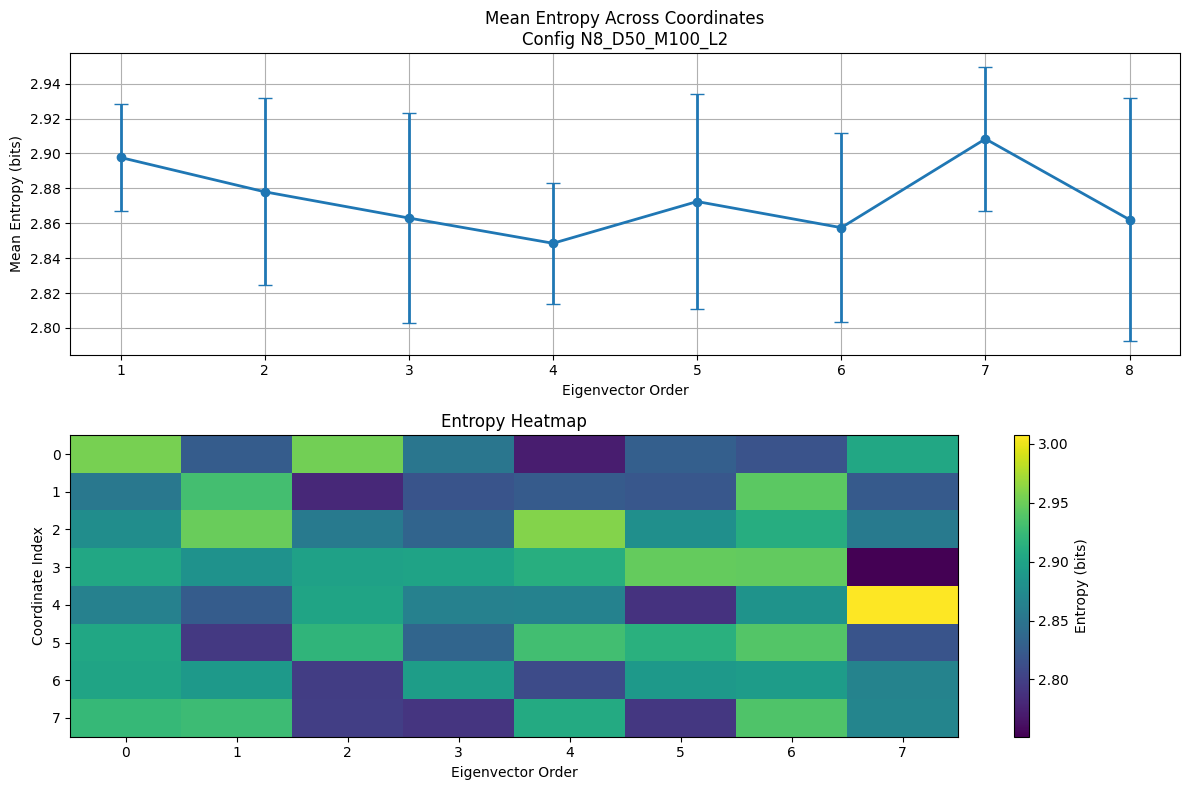

Processing experiment files:  58%|█████▊    | 56/97 [00:35<00:25,  1.58it/s]


Entropy Statistics:
  Overall mean entropy: 2.8734 ± 0.0507 bits
  Max entropy: 3.0073 bits
  Min entropy: 2.7513 bits

Most random eigenvector: 7th
  Mean entropy: 2.9083 ± 0.0413 bits

Least random eigenvector: 4th
  Mean entropy: 2.8485 ± 0.0347 bits
Computing entropy for all eigenvector distributions - N10_D20_M10_L2


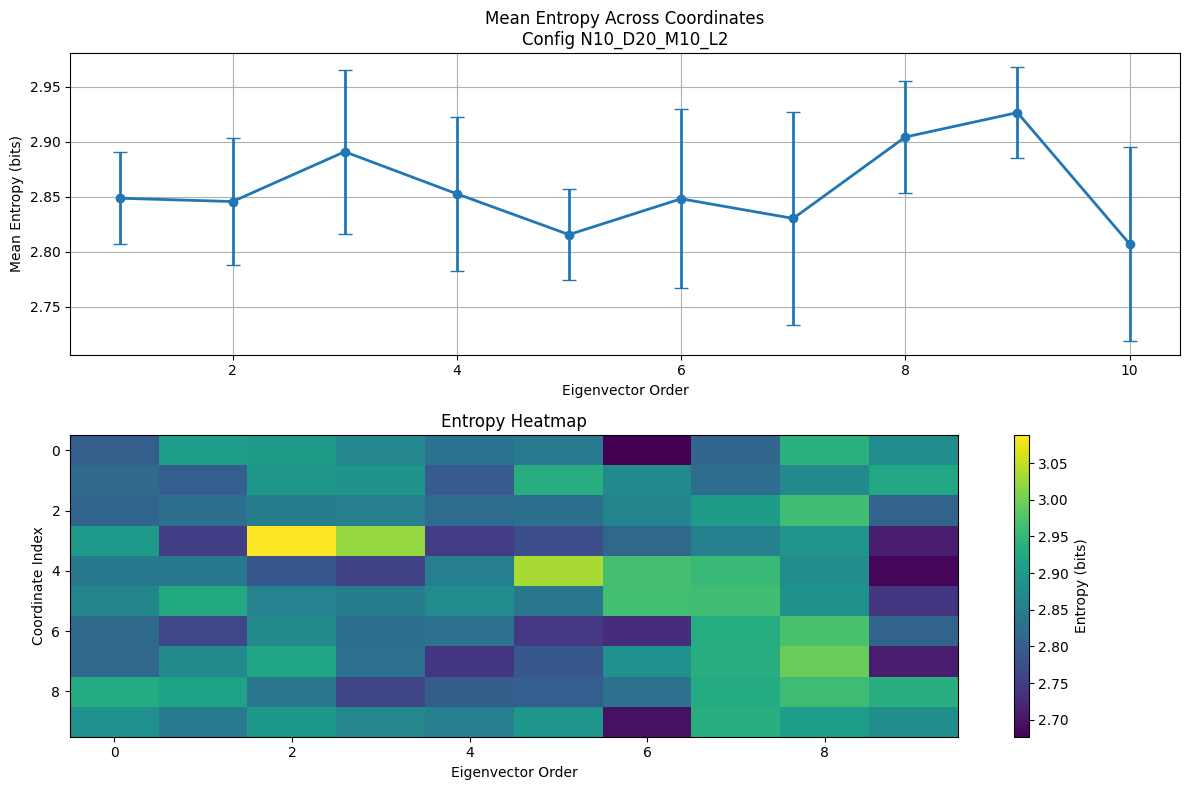

Processing experiment files:  59%|█████▉    | 57/97 [00:35<00:26,  1.48it/s]


Entropy Statistics:
  Overall mean entropy: 2.8570 ± 0.0645 bits
  Max entropy: 3.0879 bits
  Min entropy: 2.6768 bits

Most random eigenvector: 9th
  Mean entropy: 2.9265 ± 0.0416 bits

Least random eigenvector: 10th
  Mean entropy: 2.8072 ± 0.0882 bits
Computing entropy for all eigenvector distributions - N10_D20_M50_L6


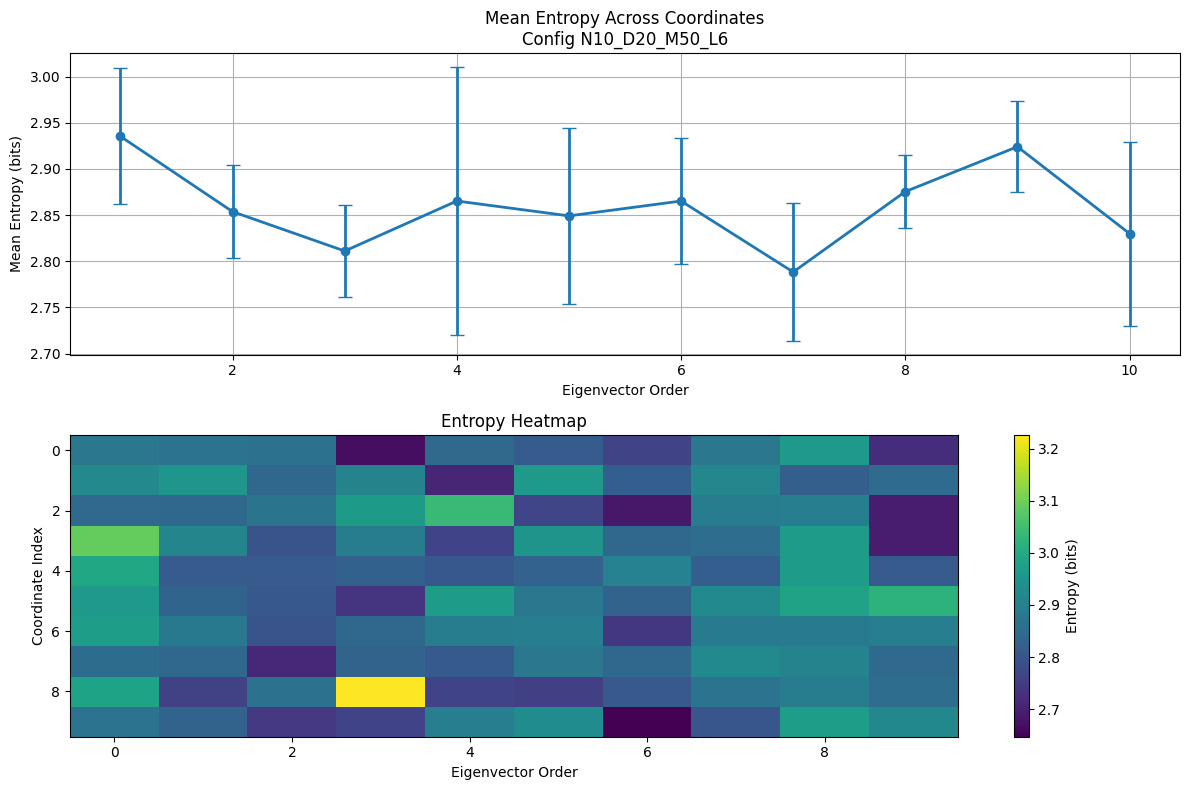

Processing experiment files:  60%|█████▉    | 58/97 [00:36<00:25,  1.51it/s]


Entropy Statistics:
  Overall mean entropy: 2.8597 ± 0.0745 bits
  Max entropy: 3.2260 bits
  Min entropy: 2.6469 bits

Most random eigenvector: 1st
  Mean entropy: 2.9352 ± 0.0736 bits

Least random eigenvector: 7th
  Mean entropy: 2.7883 ± 0.0746 bits
Computing entropy for all eigenvector distributions - N10_D20_M50_L4


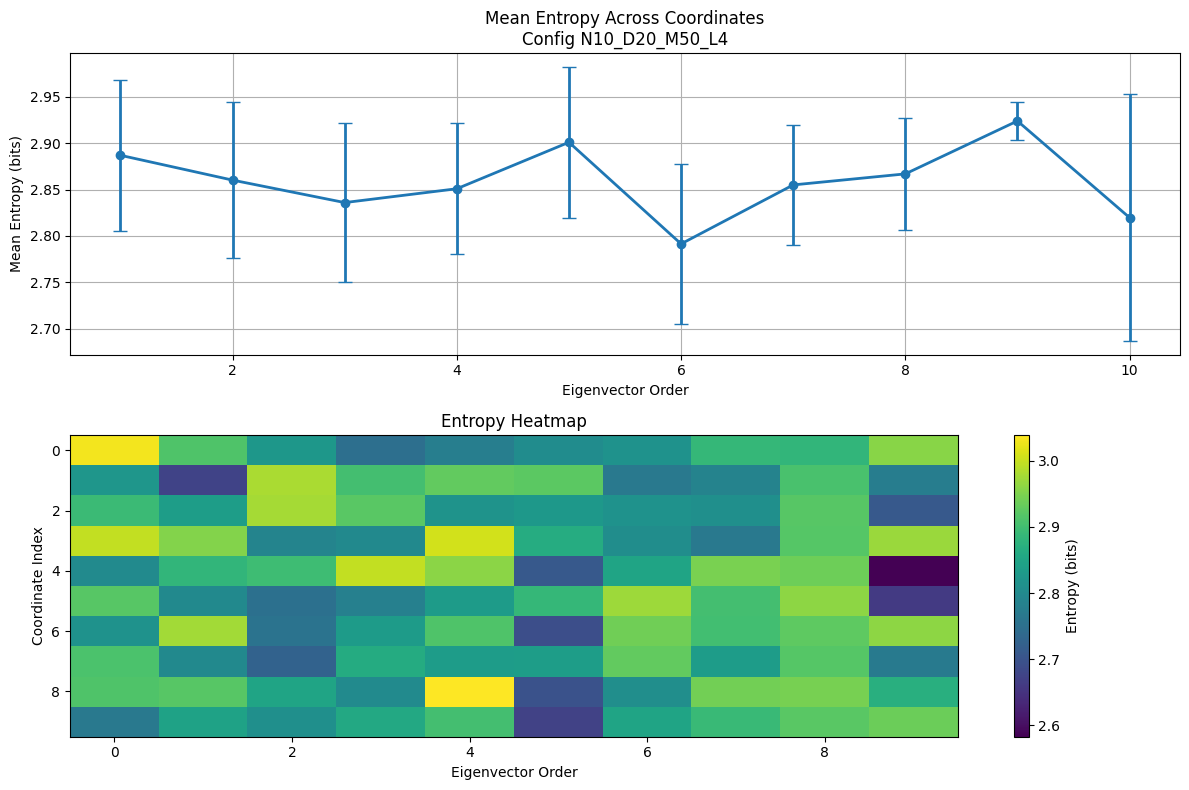

Processing experiment files:  61%|██████    | 59/97 [00:37<00:24,  1.53it/s]


Entropy Statistics:
  Overall mean entropy: 2.8591 ± 0.0767 bits
  Max entropy: 3.0384 bits
  Min entropy: 2.5828 bits

Most random eigenvector: 9th
  Mean entropy: 2.9239 ± 0.0203 bits

Least random eigenvector: 6th
  Mean entropy: 2.7914 ± 0.0865 bits
Computing entropy for all eigenvector distributions - N10_D20_M100_L2


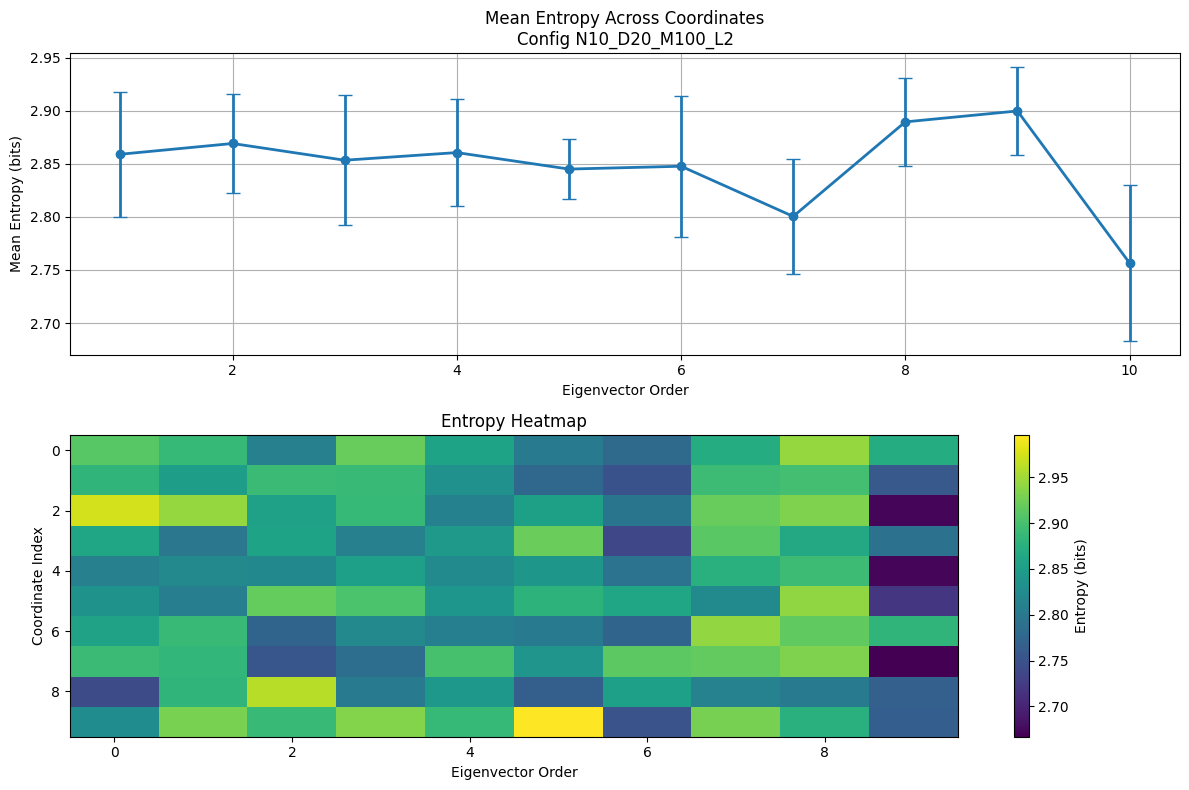

Processing experiment files:  62%|██████▏   | 60/97 [00:37<00:23,  1.55it/s]


Entropy Statistics:
  Overall mean entropy: 2.8481 ± 0.0523 bits
  Max entropy: 2.9958 bits
  Min entropy: 2.6670 bits

Most random eigenvector: 9th
  Mean entropy: 2.8997 ± 0.0416 bits

Least random eigenvector: 10th
  Mean entropy: 2.7565 ± 0.0734 bits
Computing entropy for all eigenvector distributions - N10_D20_M10_L10


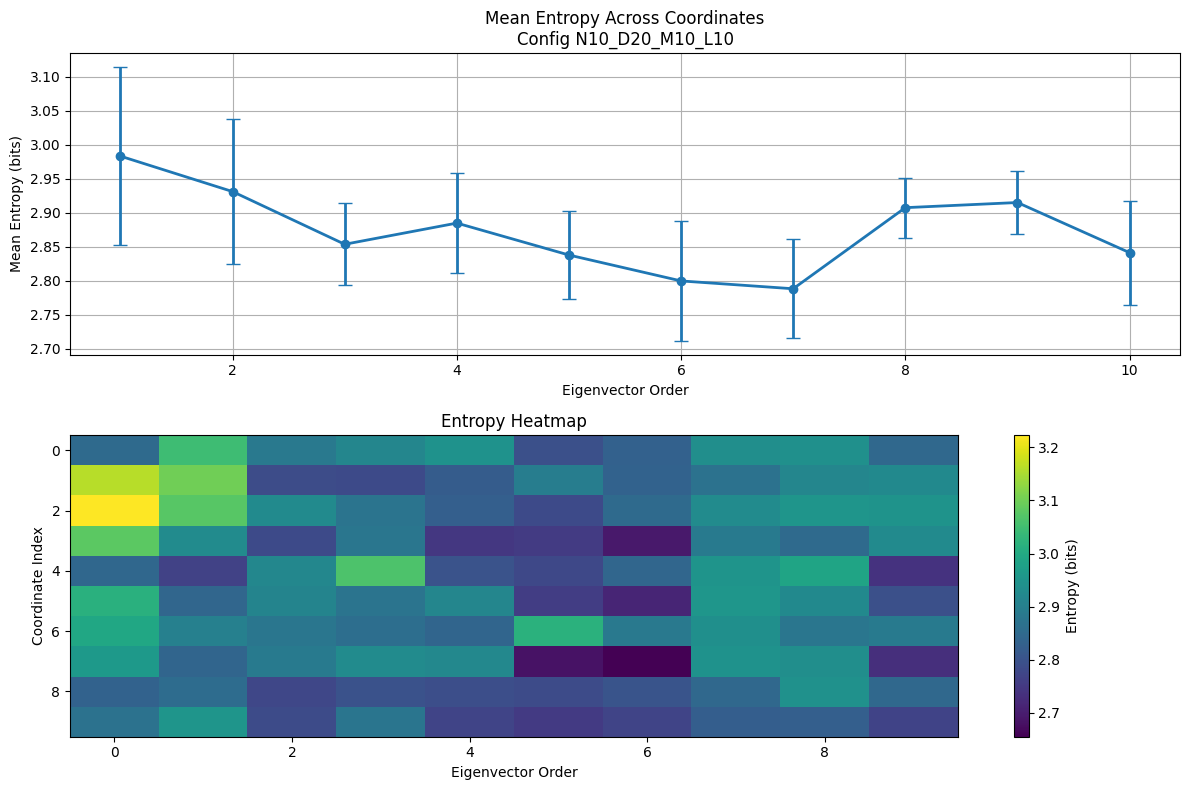

Processing experiment files:  63%|██████▎   | 61/97 [00:38<00:23,  1.52it/s]


Entropy Statistics:
  Overall mean entropy: 2.8741 ± 0.0764 bits
  Max entropy: 3.2229 bits
  Min entropy: 2.6548 bits

Most random eigenvector: 1st
  Mean entropy: 2.9831 ± 0.1313 bits

Least random eigenvector: 7th
  Mean entropy: 2.7881 ± 0.0730 bits
Computing entropy for all eigenvector distributions - N10_D20_M20_L2


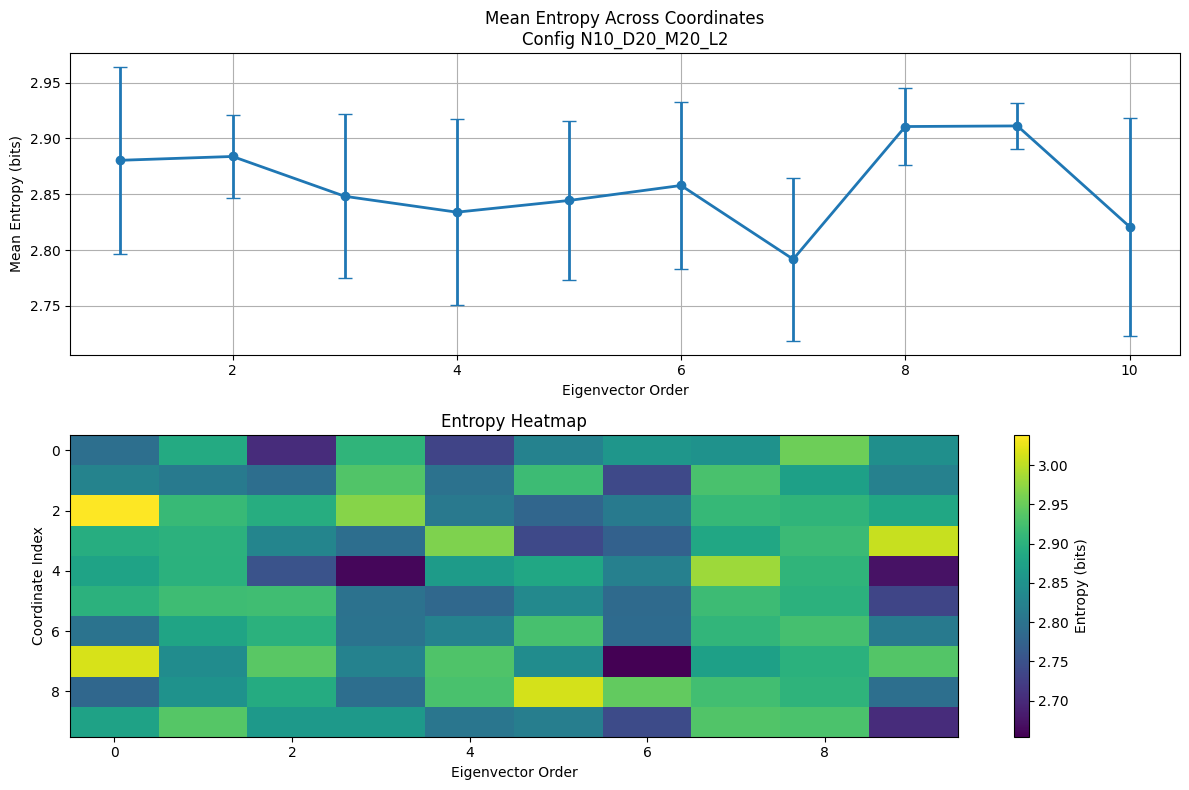

Processing experiment files:  64%|██████▍   | 62/97 [00:39<00:23,  1.48it/s]


Entropy Statistics:
  Overall mean entropy: 2.8583 ± 0.0650 bits
  Max entropy: 3.0382 bits
  Min entropy: 2.6541 bits

Most random eigenvector: 9th
  Mean entropy: 2.9112 ± 0.0204 bits

Least random eigenvector: 7th
  Mean entropy: 2.7918 ± 0.0732 bits
Computing entropy for all eigenvector distributions - N10_D20_M10_L4


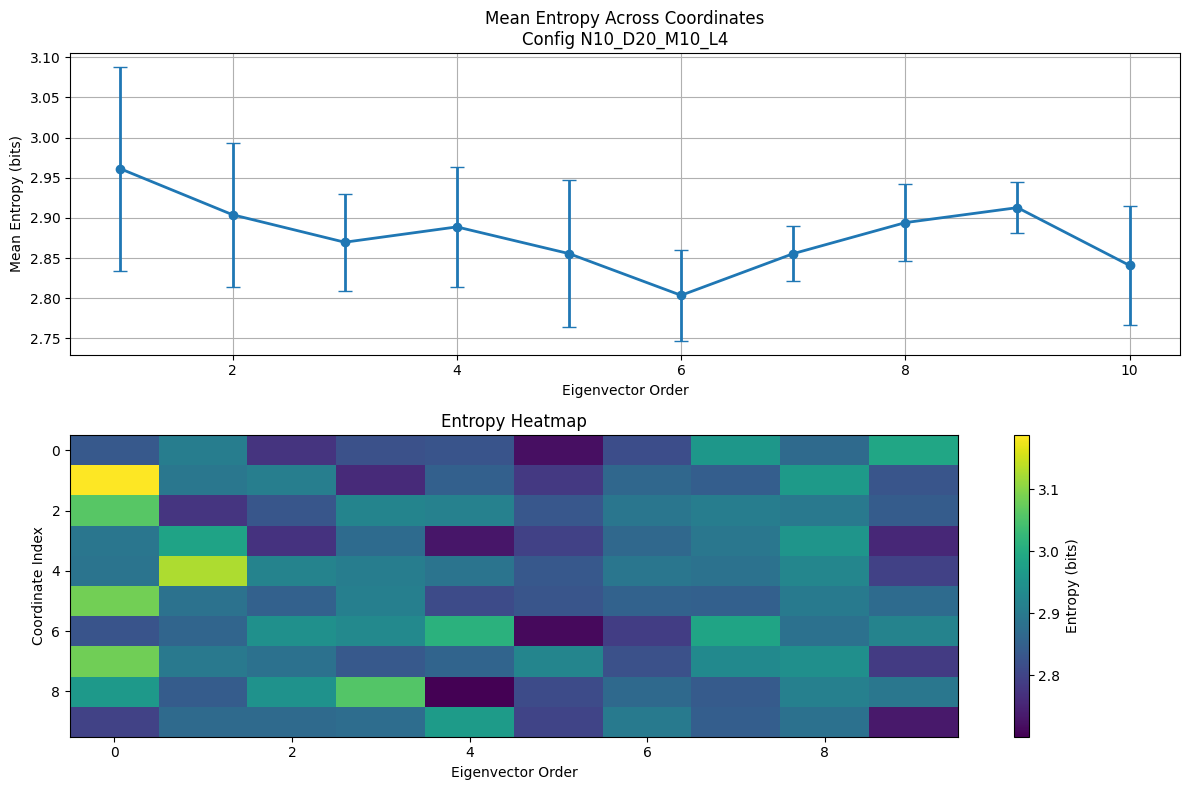

Processing experiment files:  65%|██████▍   | 63/97 [00:40<00:26,  1.29it/s]


Entropy Statistics:
  Overall mean entropy: 2.8786 ± 0.0689 bits
  Max entropy: 3.1868 bits
  Min entropy: 2.7006 bits

Most random eigenvector: 1st
  Mean entropy: 2.9610 ± 0.1269 bits

Least random eigenvector: 6th
  Mean entropy: 2.8036 ± 0.0567 bits
Computing entropy for all eigenvector distributions - N10_D20_M20_L6


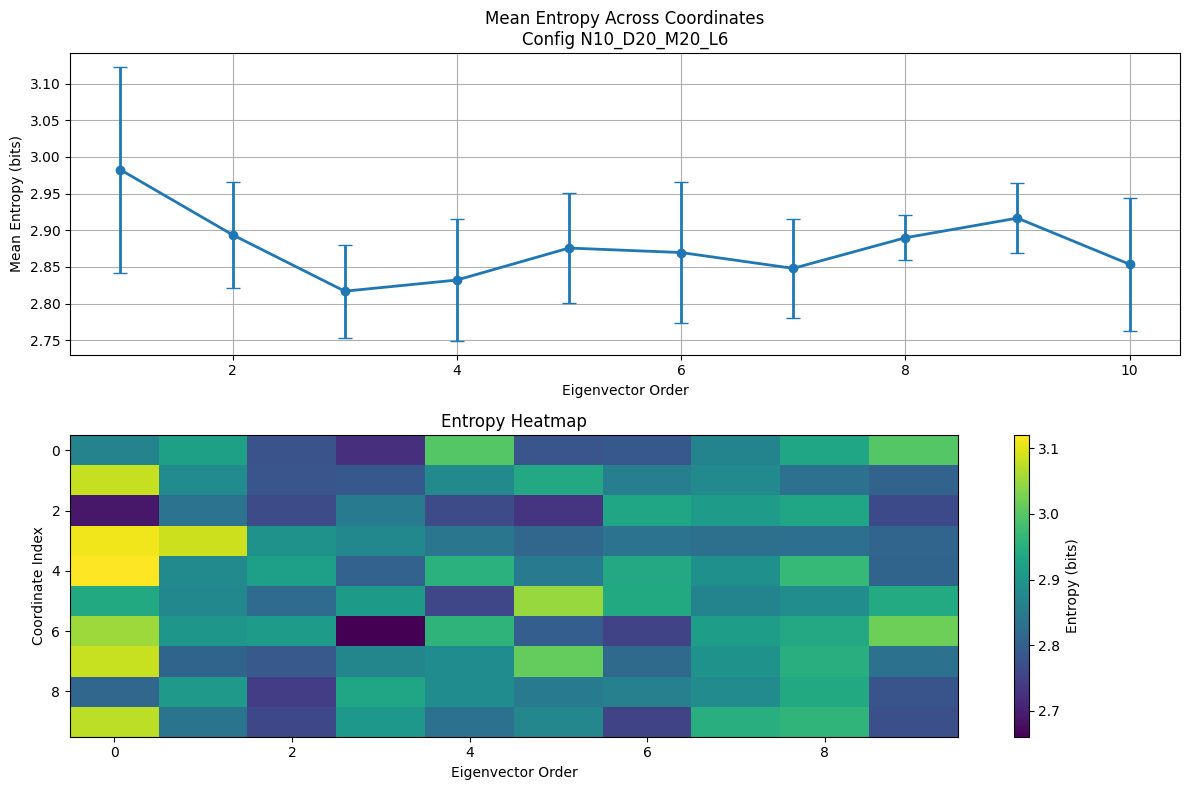

Processing experiment files:  66%|██████▌   | 64/97 [00:40<00:24,  1.32it/s]


Entropy Statistics:
  Overall mean entropy: 2.8778 ± 0.0768 bits
  Max entropy: 3.1199 bits
  Min entropy: 2.6605 bits

Most random eigenvector: 1st
  Mean entropy: 2.9824 ± 0.1403 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8169 ± 0.0635 bits
Computing entropy for all eigenvector distributions - N10_D20_M10_L6


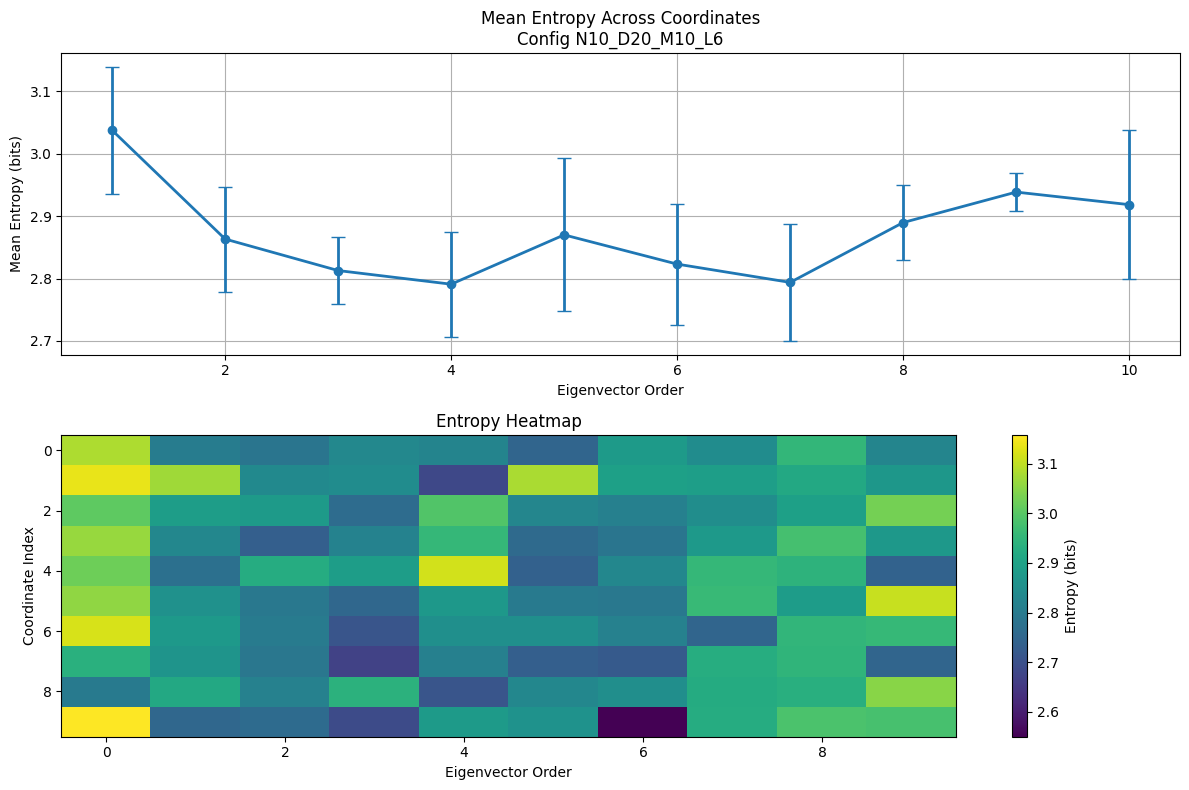

Processing experiment files:  67%|██████▋   | 65/97 [00:41<00:23,  1.38it/s]


Entropy Statistics:
  Overall mean entropy: 2.8739 ± 0.0848 bits
  Max entropy: 3.1570 bits
  Min entropy: 2.5499 bits

Most random eigenvector: 1st
  Mean entropy: 3.0377 ± 0.1017 bits

Least random eigenvector: 4th
  Mean entropy: 2.7910 ± 0.0844 bits
Computing entropy for all eigenvector distributions - N10_D20_M50_L2


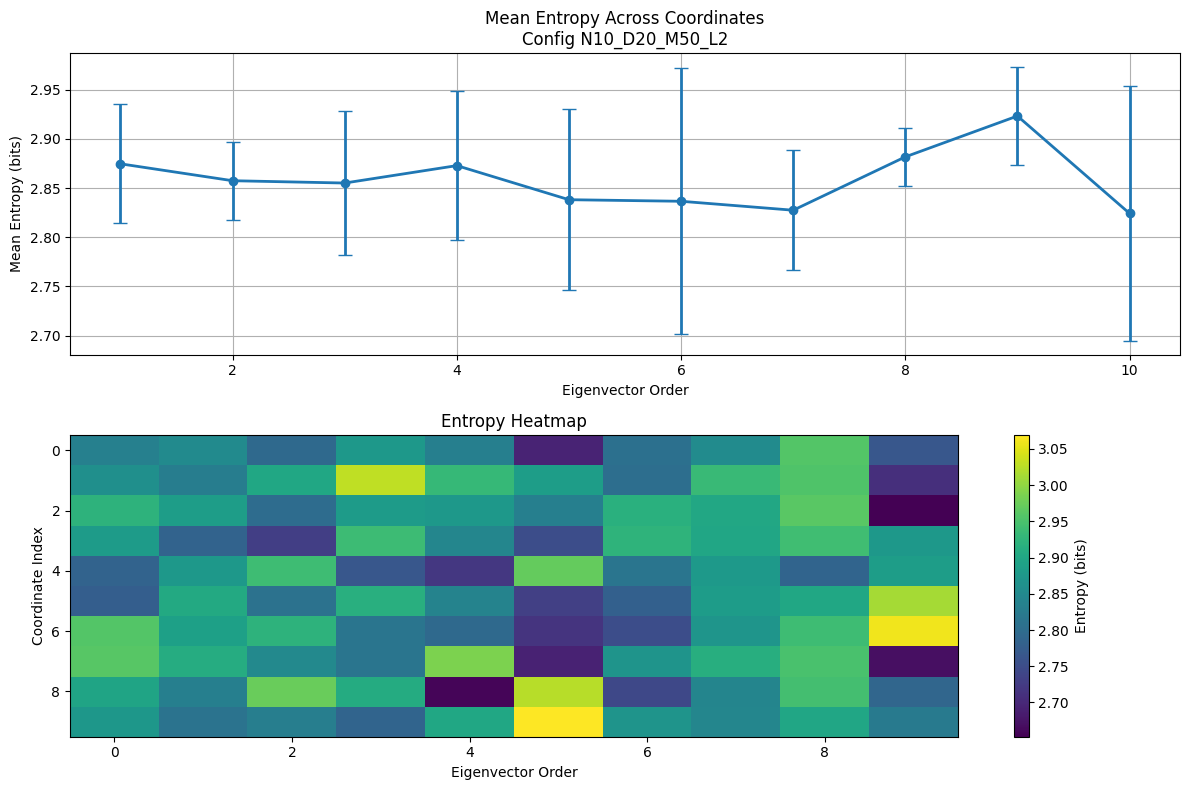

Processing experiment files:  68%|██████▊   | 66/97 [00:42<00:21,  1.44it/s]


Entropy Statistics:
  Overall mean entropy: 2.8591 ± 0.0746 bits
  Max entropy: 3.0688 bits
  Min entropy: 2.6528 bits

Most random eigenvector: 9th
  Mean entropy: 2.9232 ± 0.0500 bits

Least random eigenvector: 10th
  Mean entropy: 2.8242 ± 0.1296 bits
Computing entropy for all eigenvector distributions - N10_D200_M10_L2


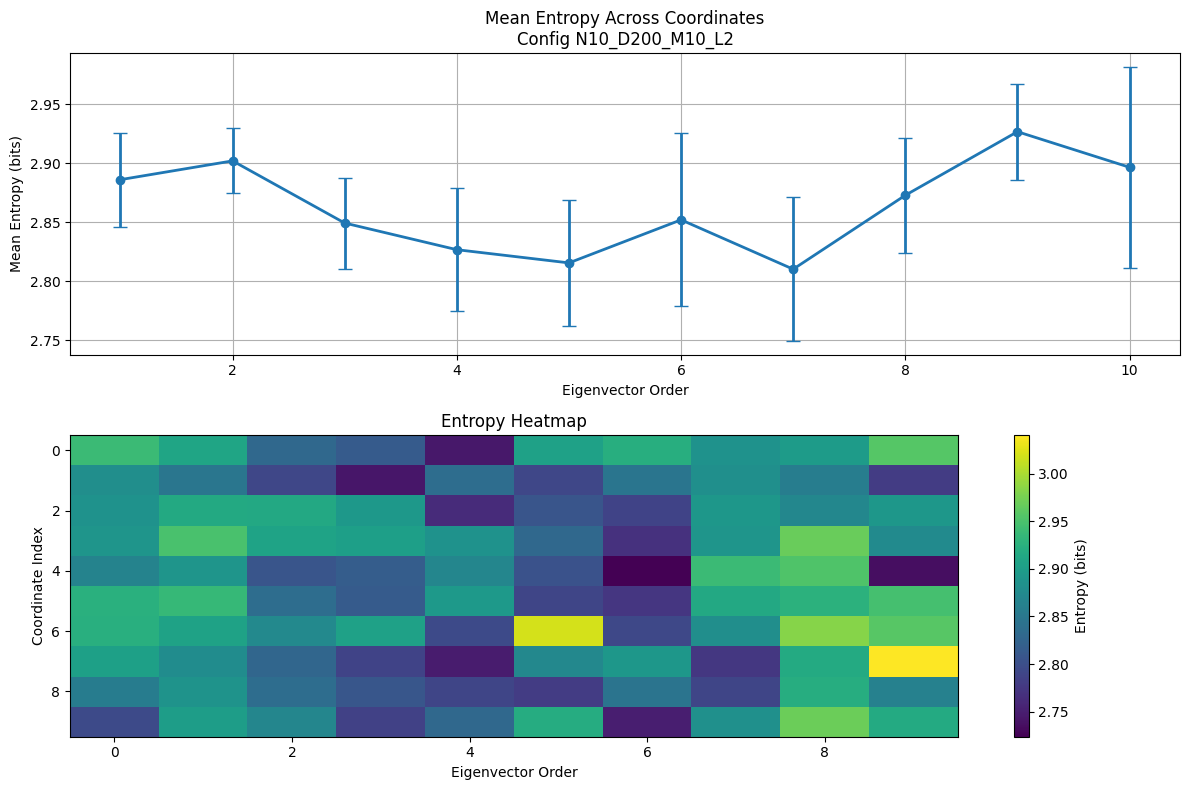

Processing experiment files:  69%|██████▉   | 67/97 [00:42<00:20,  1.47it/s]


Entropy Statistics:
  Overall mean entropy: 2.8638 ± 0.0520 bits
  Max entropy: 3.0405 bits
  Min entropy: 2.7236 bits

Most random eigenvector: 9th
  Mean entropy: 2.9266 ± 0.0405 bits

Least random eigenvector: 7th
  Mean entropy: 2.8102 ± 0.0607 bits
Computing entropy for all eigenvector distributions - N10_D50_M10_L8


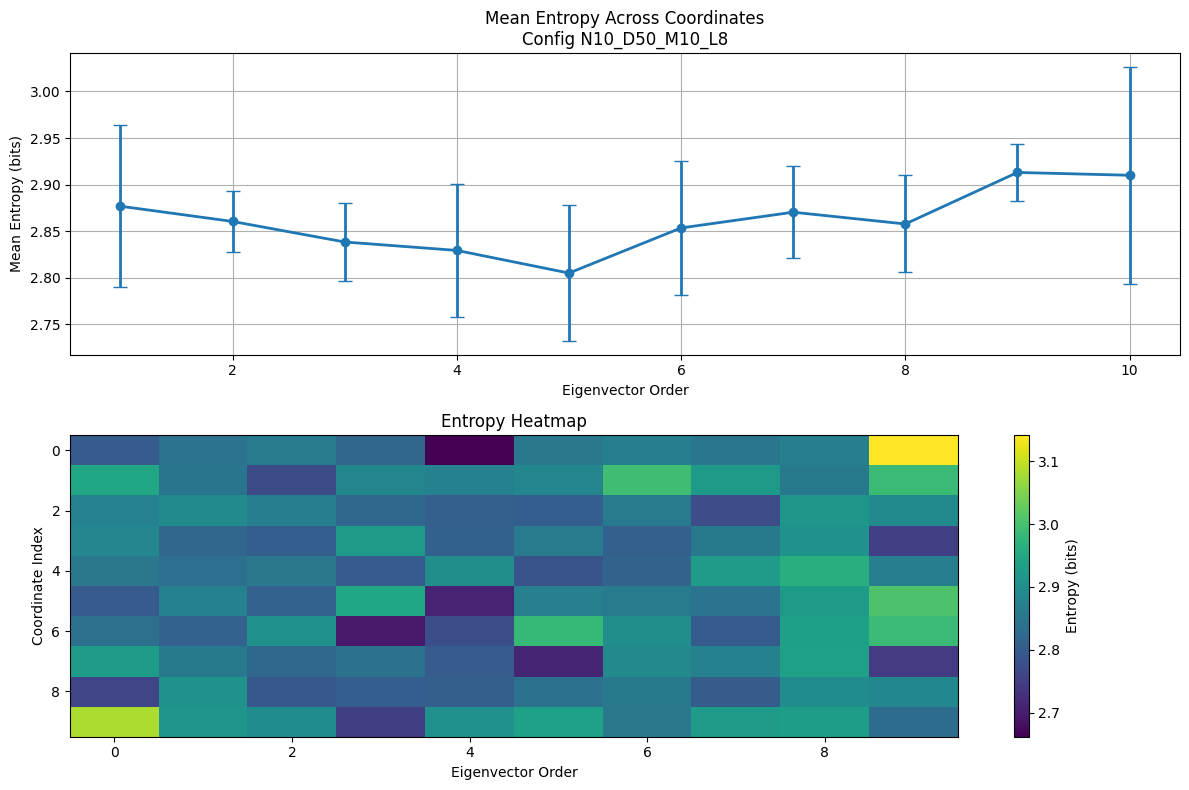

Processing experiment files:  70%|███████   | 68/97 [00:43<00:19,  1.51it/s]


Entropy Statistics:
  Overall mean entropy: 2.8613 ± 0.0627 bits
  Max entropy: 3.1412 bits
  Min entropy: 2.6620 bits

Most random eigenvector: 9th
  Mean entropy: 2.9130 ± 0.0308 bits

Least random eigenvector: 5th
  Mean entropy: 2.8048 ± 0.0729 bits
Computing entropy for all eigenvector distributions - N10_D20_M20_L4


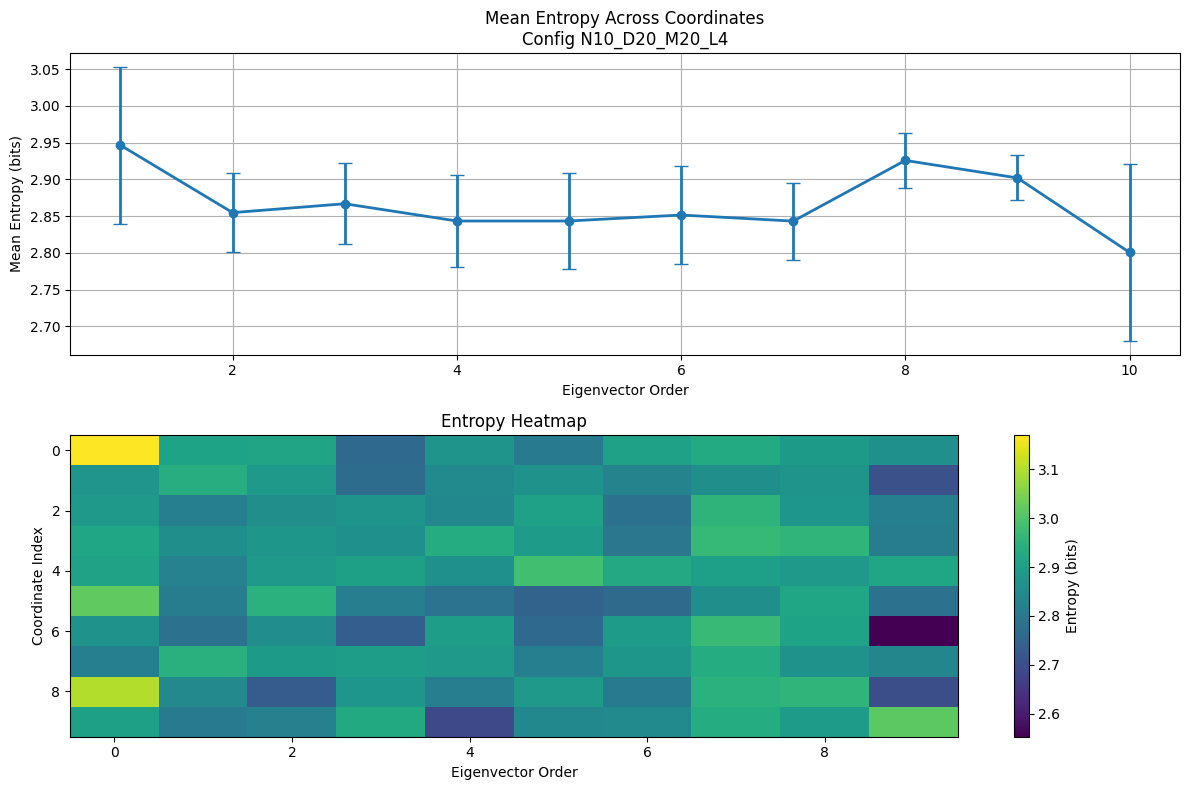

Processing experiment files:  71%|███████   | 69/97 [00:44<00:18,  1.52it/s]


Entropy Statistics:
  Overall mean entropy: 2.8678 ± 0.0651 bits
  Max entropy: 3.1696 bits
  Min entropy: 2.5529 bits

Most random eigenvector: 1st
  Mean entropy: 2.9465 ± 0.1067 bits

Least random eigenvector: 10th
  Mean entropy: 2.8006 ± 0.1204 bits
Computing entropy for all eigenvector distributions - N10_D100_M20_L2


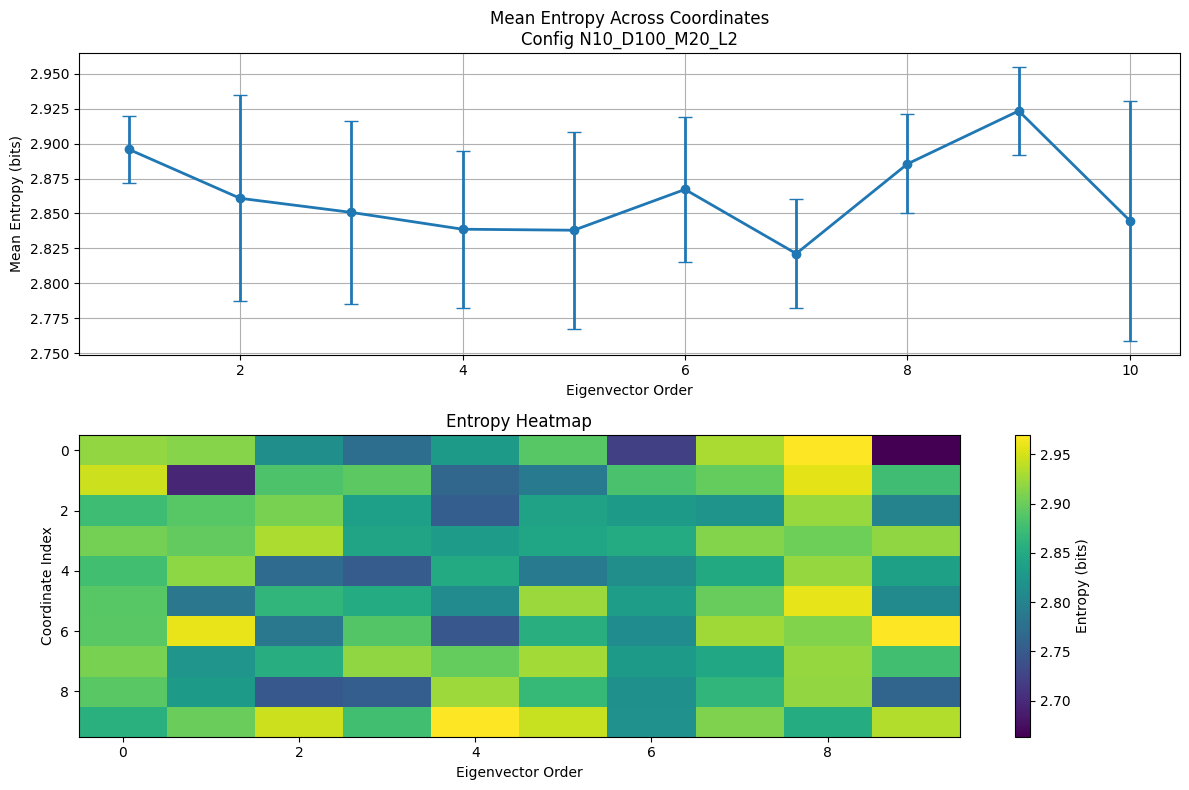

Processing experiment files:  72%|███████▏  | 70/97 [00:44<00:17,  1.53it/s]


Entropy Statistics:
  Overall mean entropy: 2.8626 ± 0.0534 bits
  Max entropy: 2.9694 bits
  Min entropy: 2.6632 bits

Most random eigenvector: 9th
  Mean entropy: 2.9235 ± 0.0316 bits

Least random eigenvector: 7th
  Mean entropy: 2.8212 ± 0.0388 bits
Computing entropy for all eigenvector distributions - N10_D20_M20_L8


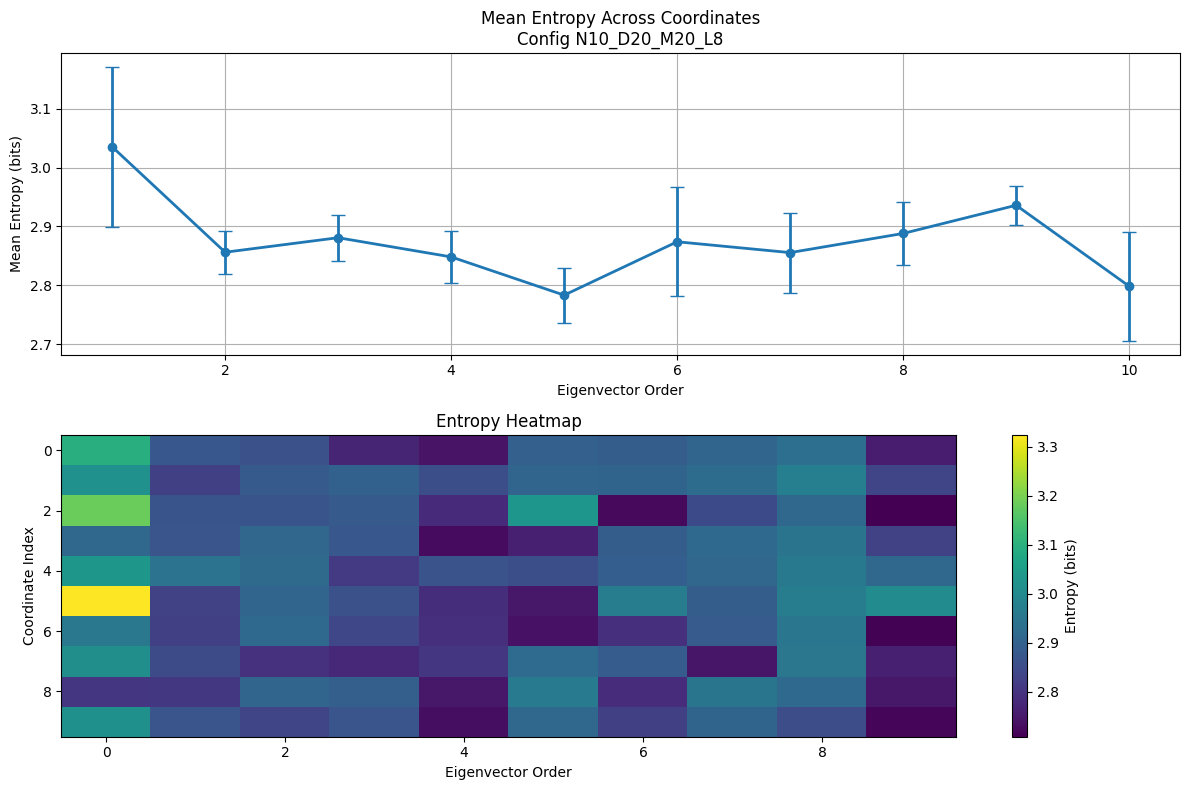

Processing experiment files:  73%|███████▎  | 71/97 [00:45<00:16,  1.54it/s]


Entropy Statistics:
  Overall mean entropy: 2.8757 ± 0.0644 bits
  Max entropy: 3.3232 bits
  Min entropy: 2.7077 bits

Most random eigenvector: 1st
  Mean entropy: 3.0355 ± 0.1359 bits

Least random eigenvector: 5th
  Mean entropy: 2.7833 ± 0.0468 bits
Computing entropy for all eigenvector distributions - N10_D20_M100_L4


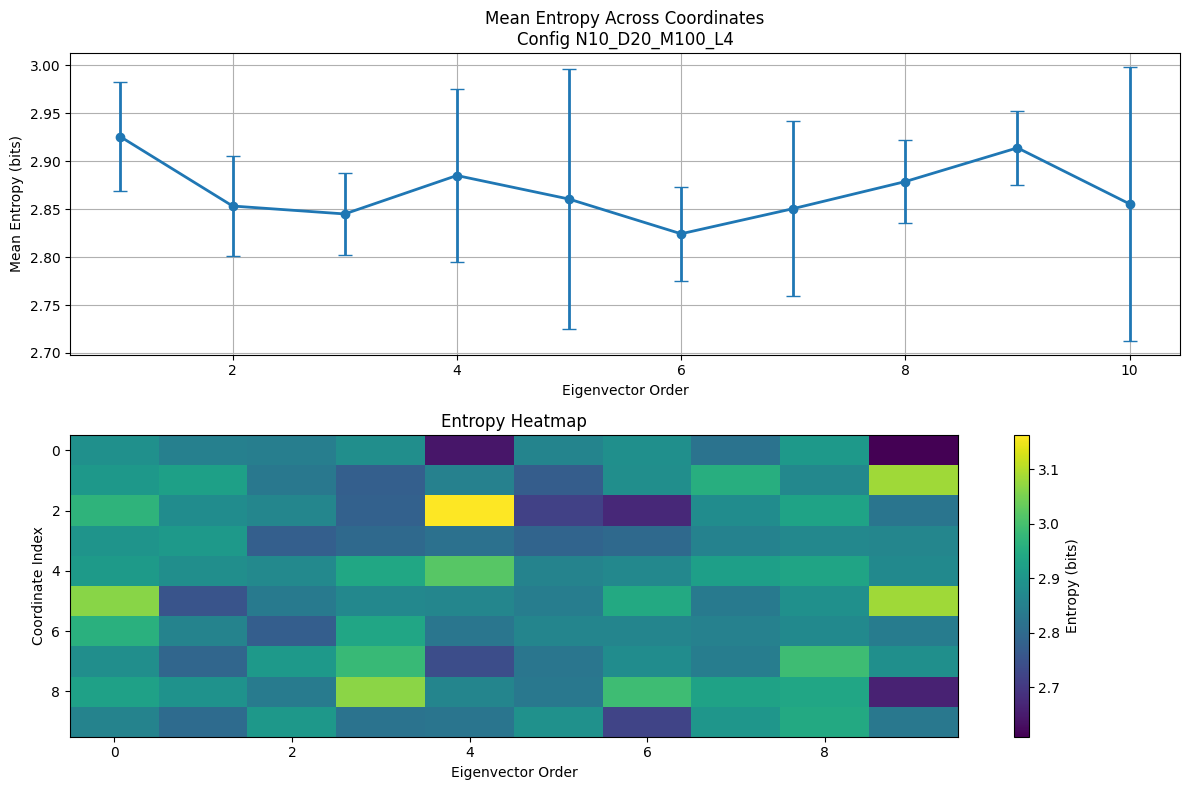

Processing experiment files:  74%|███████▍  | 72/97 [00:46<00:16,  1.51it/s]


Entropy Statistics:
  Overall mean entropy: 2.8693 ± 0.0742 bits
  Max entropy: 3.1622 bits
  Min entropy: 2.6094 bits

Most random eigenvector: 1st
  Mean entropy: 2.9255 ± 0.0567 bits

Least random eigenvector: 6th
  Mean entropy: 2.8243 ± 0.0489 bits
Computing entropy for all eigenvector distributions - N10_D50_M10_L2


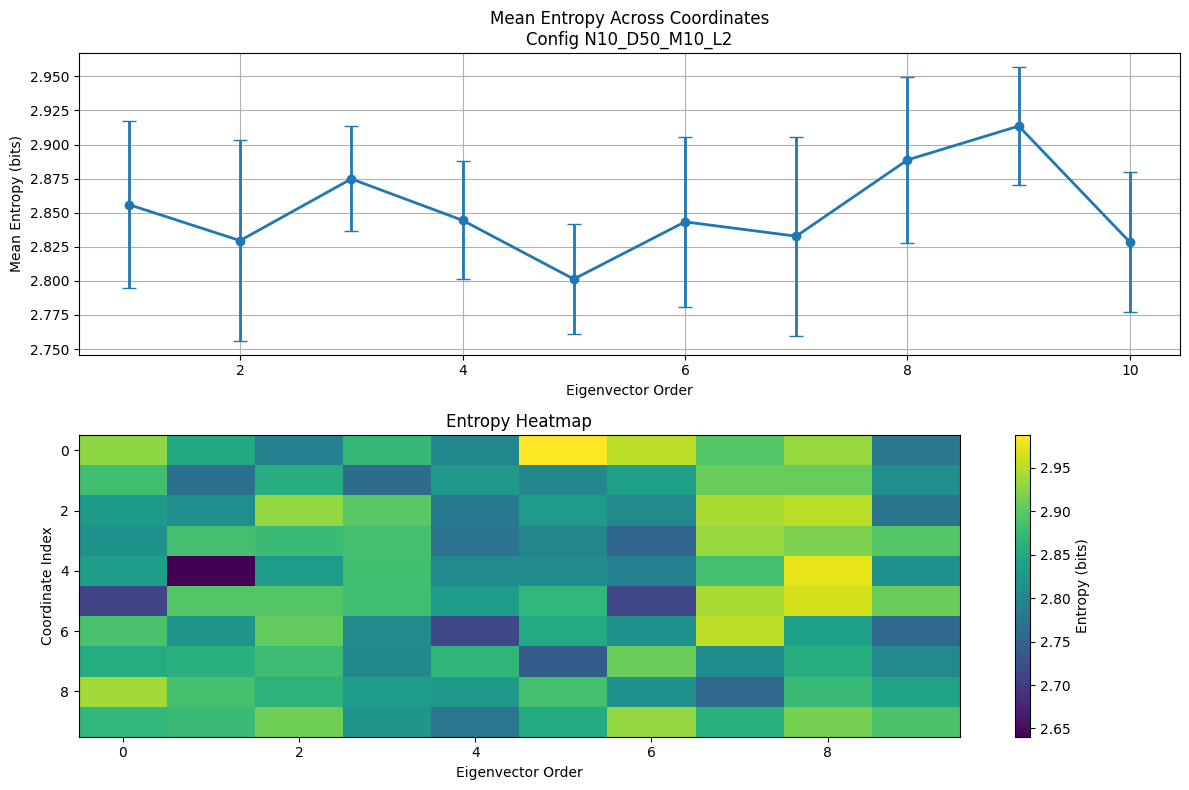

Processing experiment files:  75%|███████▌  | 73/97 [00:46<00:15,  1.51it/s]


Entropy Statistics:
  Overall mean entropy: 2.8513 ± 0.0548 bits
  Max entropy: 2.9877 bits
  Min entropy: 2.6405 bits

Most random eigenvector: 9th
  Mean entropy: 2.9135 ± 0.0434 bits

Least random eigenvector: 5th
  Mean entropy: 2.8013 ± 0.0402 bits
Computing entropy for all eigenvector distributions - N10_D50_M10_L4


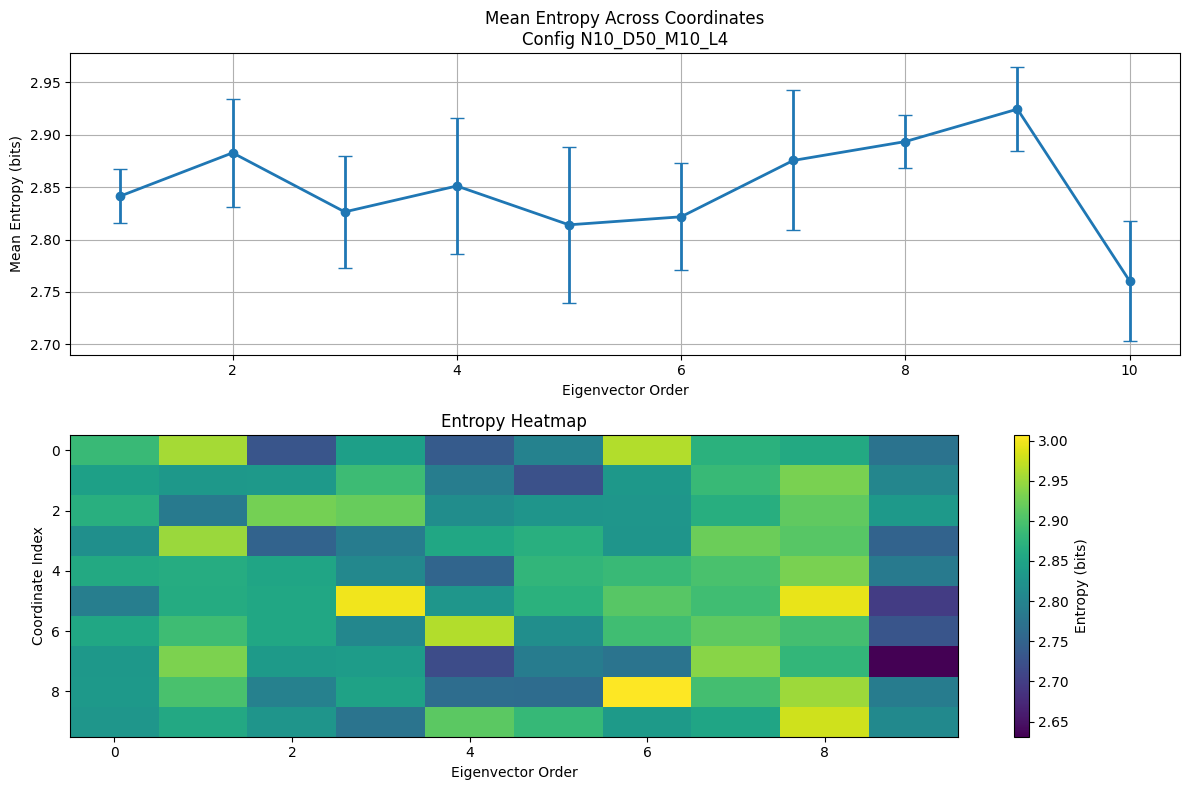

Processing experiment files:  76%|███████▋  | 74/97 [00:47<00:16,  1.40it/s]


Entropy Statistics:
  Overall mean entropy: 2.8492 ± 0.0510 bits
  Max entropy: 3.0067 bits
  Min entropy: 2.6310 bits

Most random eigenvector: 9th
  Mean entropy: 2.9245 ± 0.0404 bits

Least random eigenvector: 10th
  Mean entropy: 2.7605 ± 0.0573 bits
Computing entropy for all eigenvector distributions - N10_D100_M10_L4


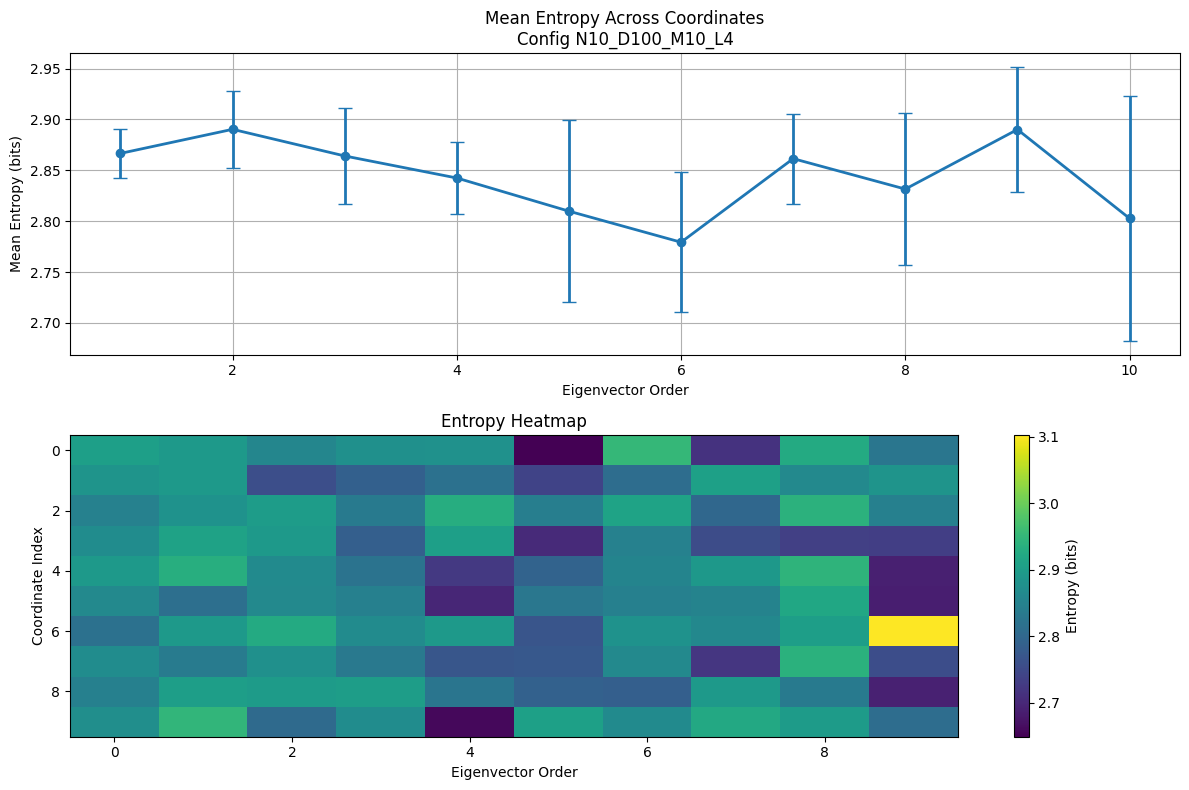

Processing experiment files:  77%|███████▋  | 75/97 [00:48<00:16,  1.34it/s]


Entropy Statistics:
  Overall mean entropy: 2.8438 ± 0.0604 bits
  Max entropy: 3.1026 bits
  Min entropy: 2.6486 bits

Most random eigenvector: 2nd
  Mean entropy: 2.8903 ± 0.0377 bits

Least random eigenvector: 6th
  Mean entropy: 2.7793 ± 0.0689 bits
Computing entropy for all eigenvector distributions - N10_D50_M20_L2


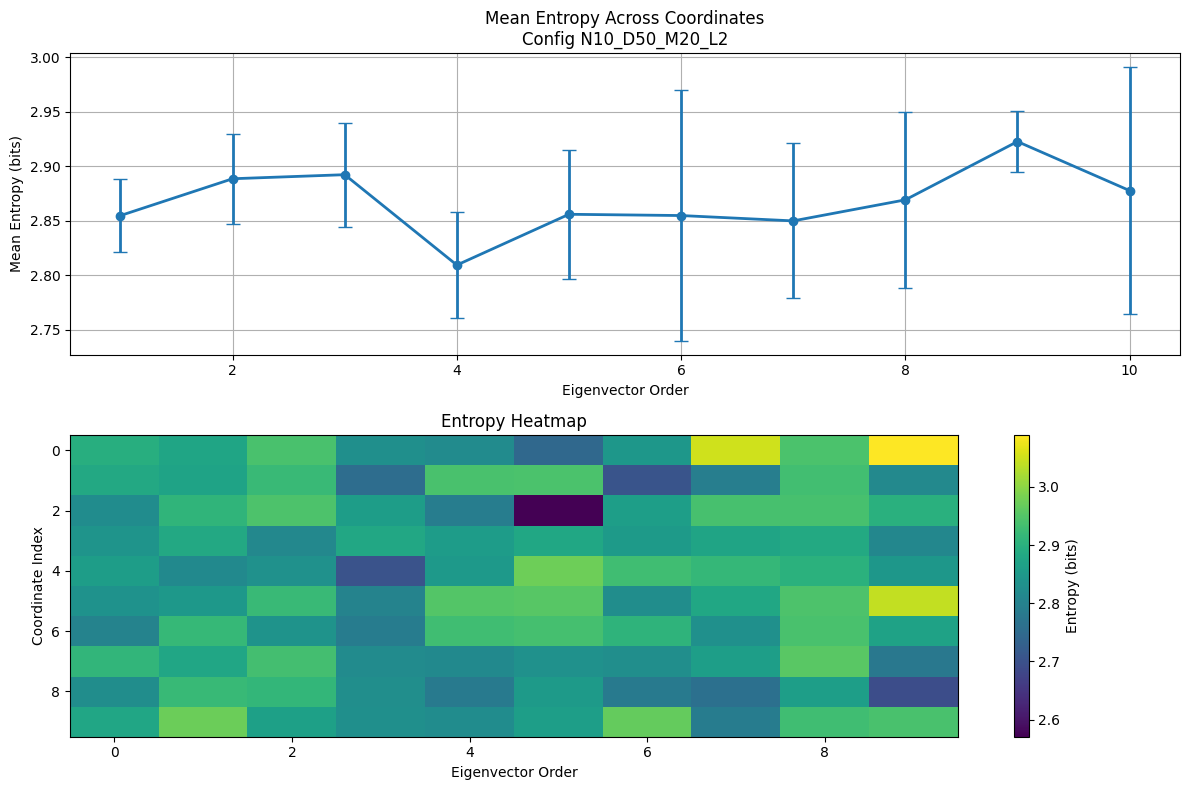

Processing experiment files:  78%|███████▊  | 76/97 [00:49<00:17,  1.19it/s]


Entropy Statistics:
  Overall mean entropy: 2.8675 ± 0.0640 bits
  Max entropy: 3.0887 bits
  Min entropy: 2.5705 bits

Most random eigenvector: 9th
  Mean entropy: 2.9227 ± 0.0283 bits

Least random eigenvector: 4th
  Mean entropy: 2.8093 ± 0.0488 bits
Computing entropy for all eigenvector distributions - N10_D50_M10_L6


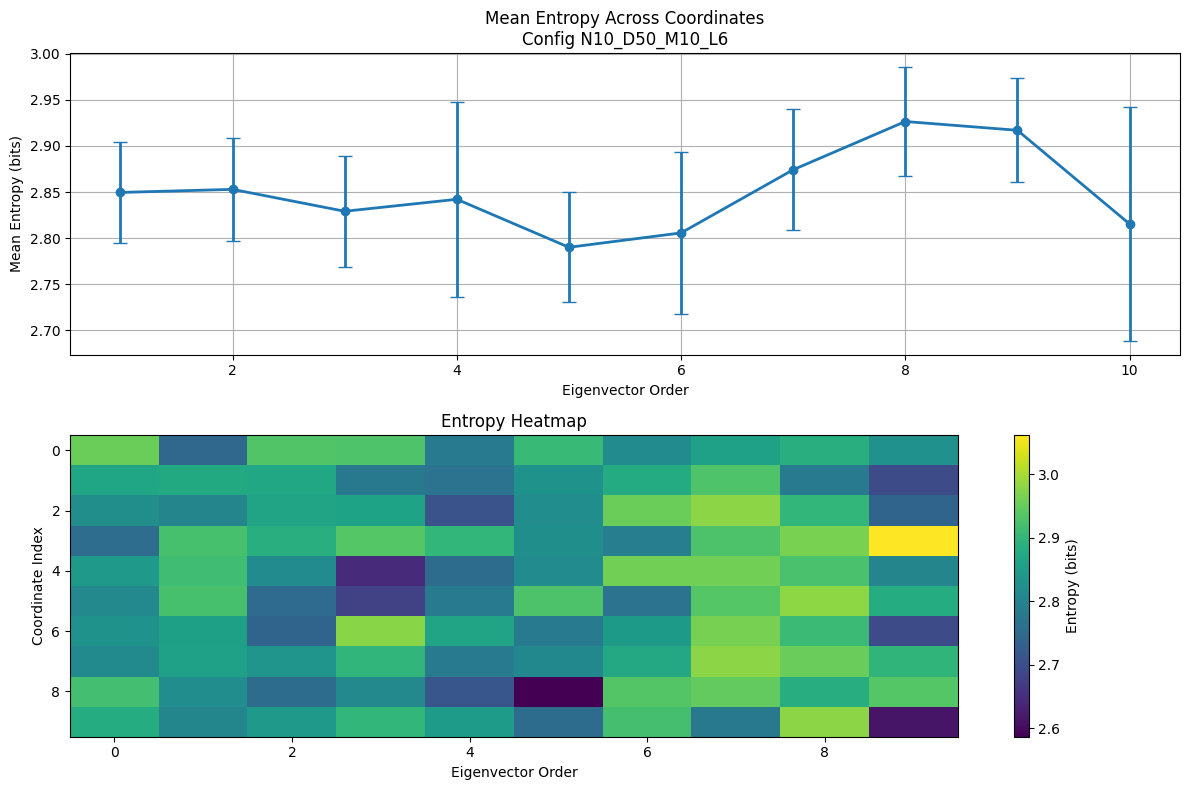

Processing experiment files:  79%|███████▉  | 77/97 [00:50<00:16,  1.24it/s]


Entropy Statistics:
  Overall mean entropy: 2.8503 ± 0.0733 bits
  Max entropy: 3.0617 bits
  Min entropy: 2.5869 bits

Most random eigenvector: 8th
  Mean entropy: 2.9266 ± 0.0593 bits

Least random eigenvector: 5th
  Mean entropy: 2.7900 ± 0.0598 bits
Computing entropy for all eigenvector distributions - N10_D20_M10_L8


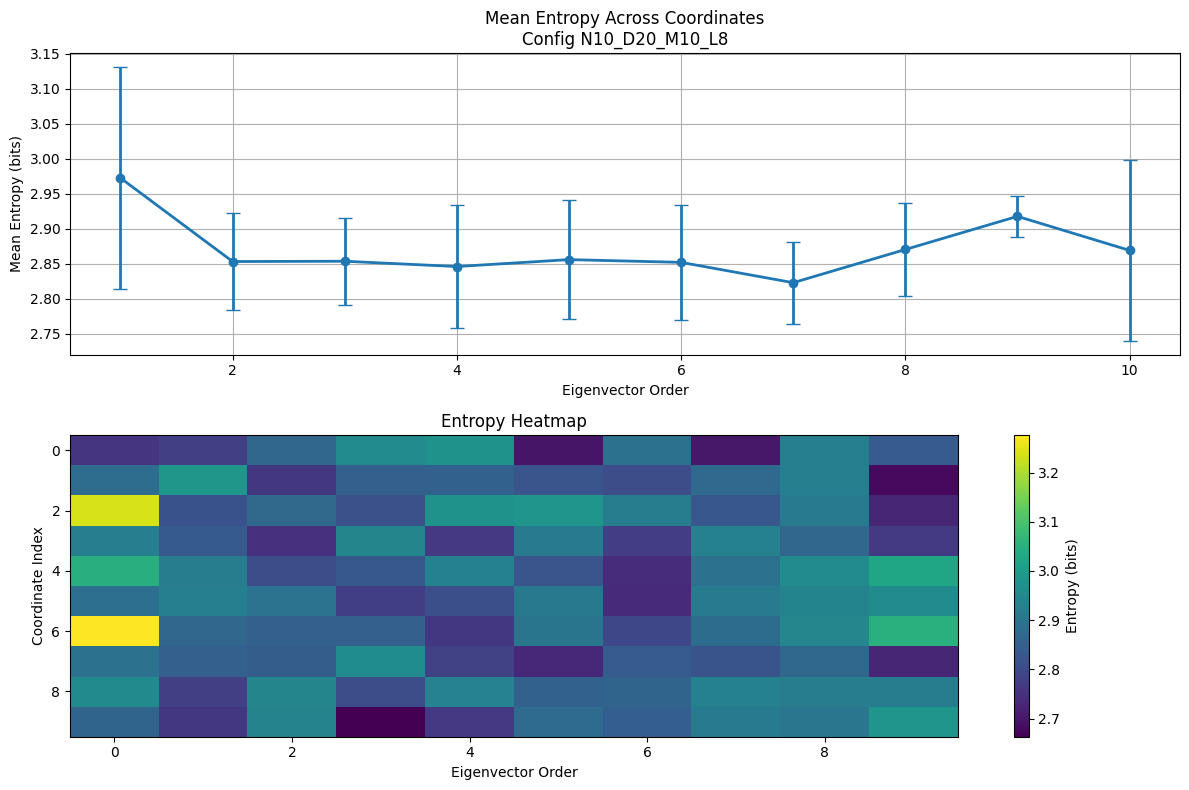

Processing experiment files:  80%|████████  | 78/97 [00:50<00:14,  1.30it/s]


Entropy Statistics:
  Overall mean entropy: 2.8712 ± 0.0831 bits
  Max entropy: 3.2758 bits
  Min entropy: 2.6633 bits

Most random eigenvector: 1st
  Mean entropy: 2.9724 ± 0.1589 bits

Least random eigenvector: 7th
  Mean entropy: 2.8228 ± 0.0588 bits
Computing entropy for all eigenvector distributions - N10_D50_M50_L2


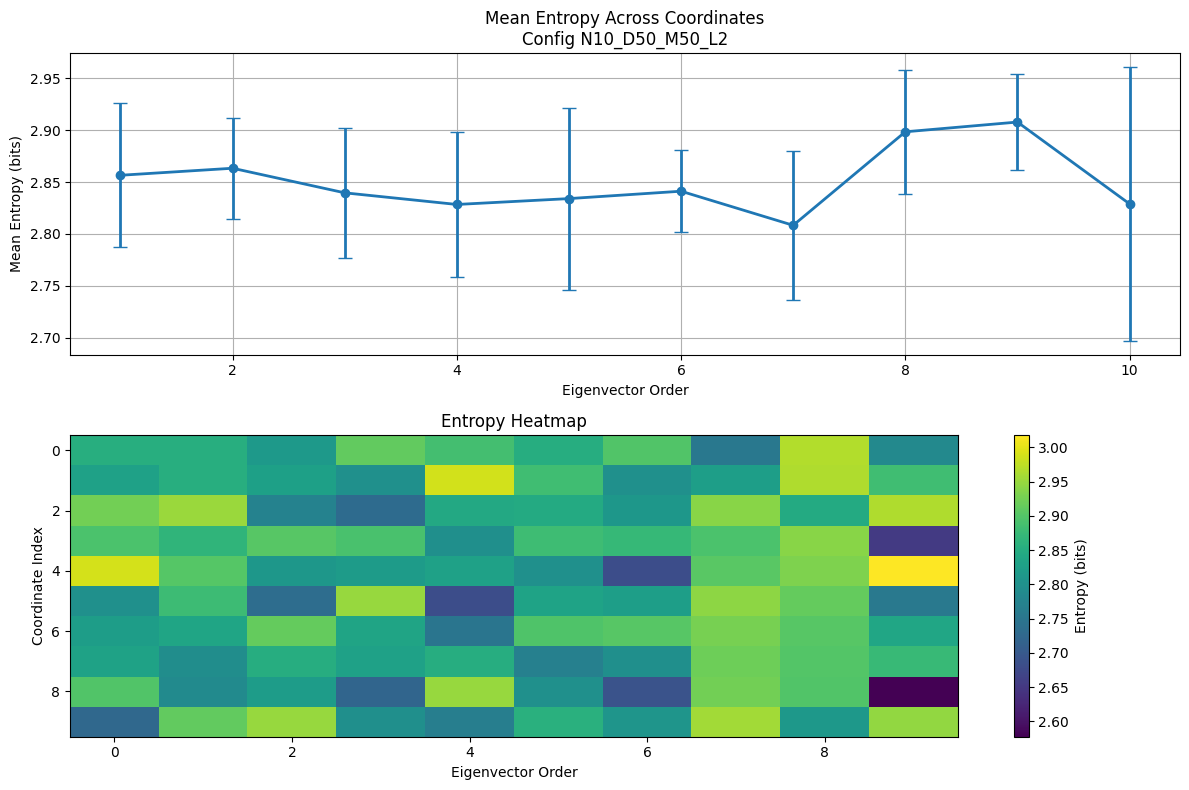


Entropy Statistics:
  Overall mean entropy: 2.8507 ± 0.0687 bits
  Max entropy: 3.0175 bits
  Min entropy: 2.5775 bits

Most random eigenvector: 9th
  Mean entropy: 2.9078 ± 0.0460 bits

Least random eigenvector: 7th
  Mean entropy: 2.8084 ± 0.0718 bits
Computing entropy for all eigenvector distributions - N10_D20_M200_L2


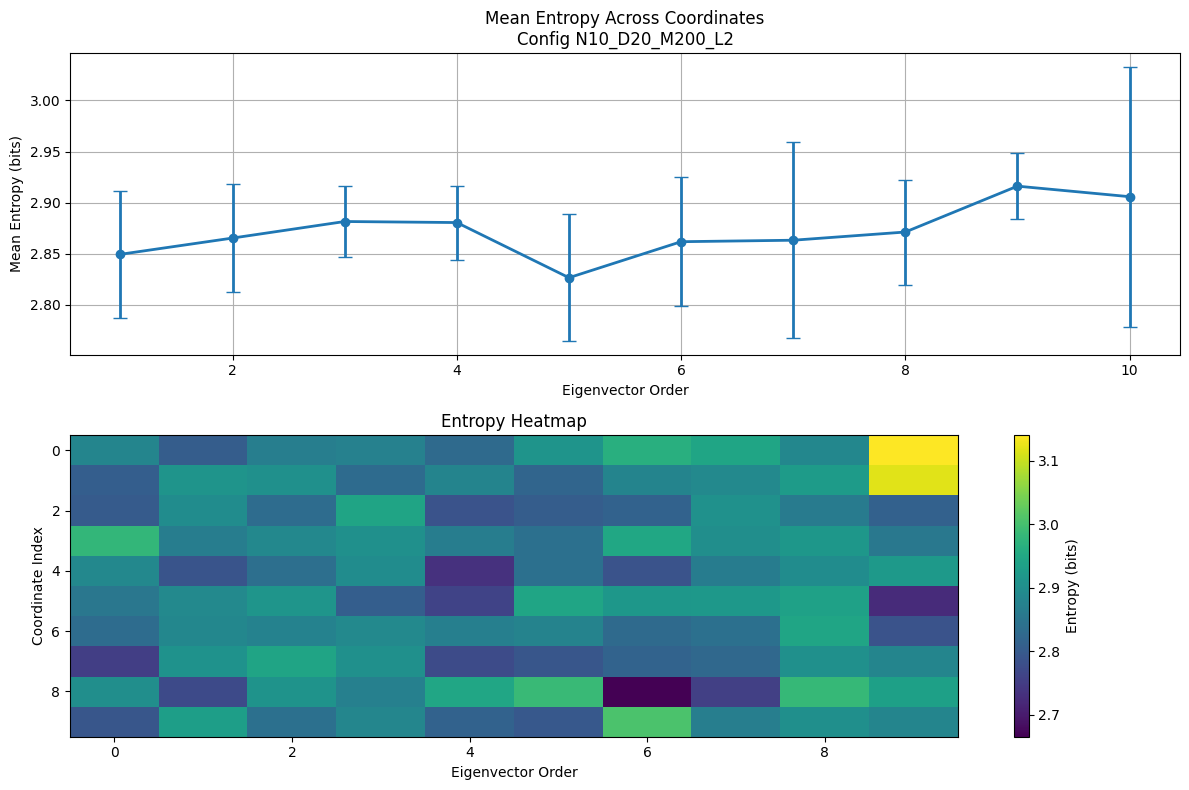

Processing experiment files:  82%|████████▏ | 80/97 [00:51<00:08,  2.06it/s]


Entropy Statistics:
  Overall mean entropy: 2.8721 ± 0.0618 bits
  Max entropy: 3.1406 bits
  Min entropy: 2.6654 bits

Most random eigenvector: 9th
  Mean entropy: 2.9161 ± 0.0324 bits

Least random eigenvector: 5th
  Mean entropy: 2.8265 ± 0.0619 bits
Computing entropy for all eigenvector distributions - N10_D50_M20_L4


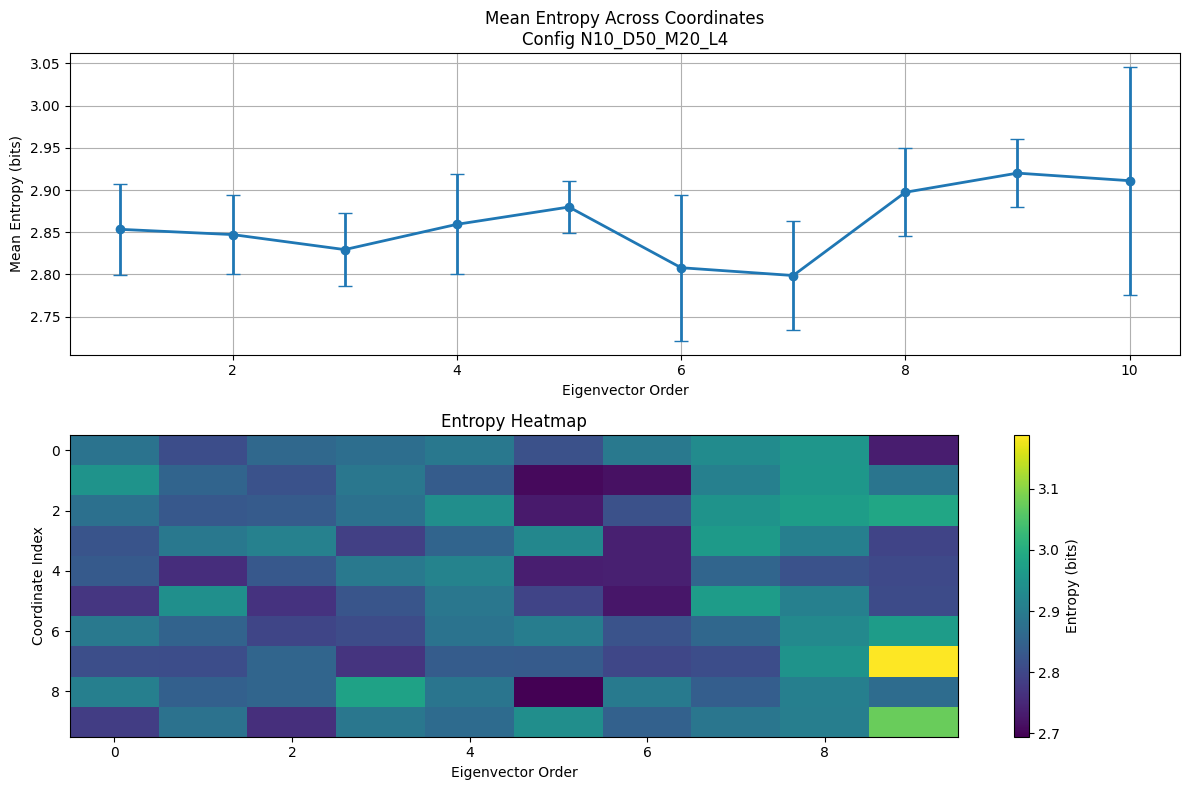

Processing experiment files:  84%|████████▎ | 81/97 [00:51<00:08,  1.95it/s]


Entropy Statistics:
  Overall mean entropy: 2.8604 ± 0.0613 bits
  Max entropy: 3.1877 bits
  Min entropy: 2.6943 bits

Most random eigenvector: 9th
  Mean entropy: 2.9200 ± 0.0407 bits

Least random eigenvector: 7th
  Mean entropy: 2.7987 ± 0.0644 bits
Computing entropy for all eigenvector distributions - N10_D100_M10_L2


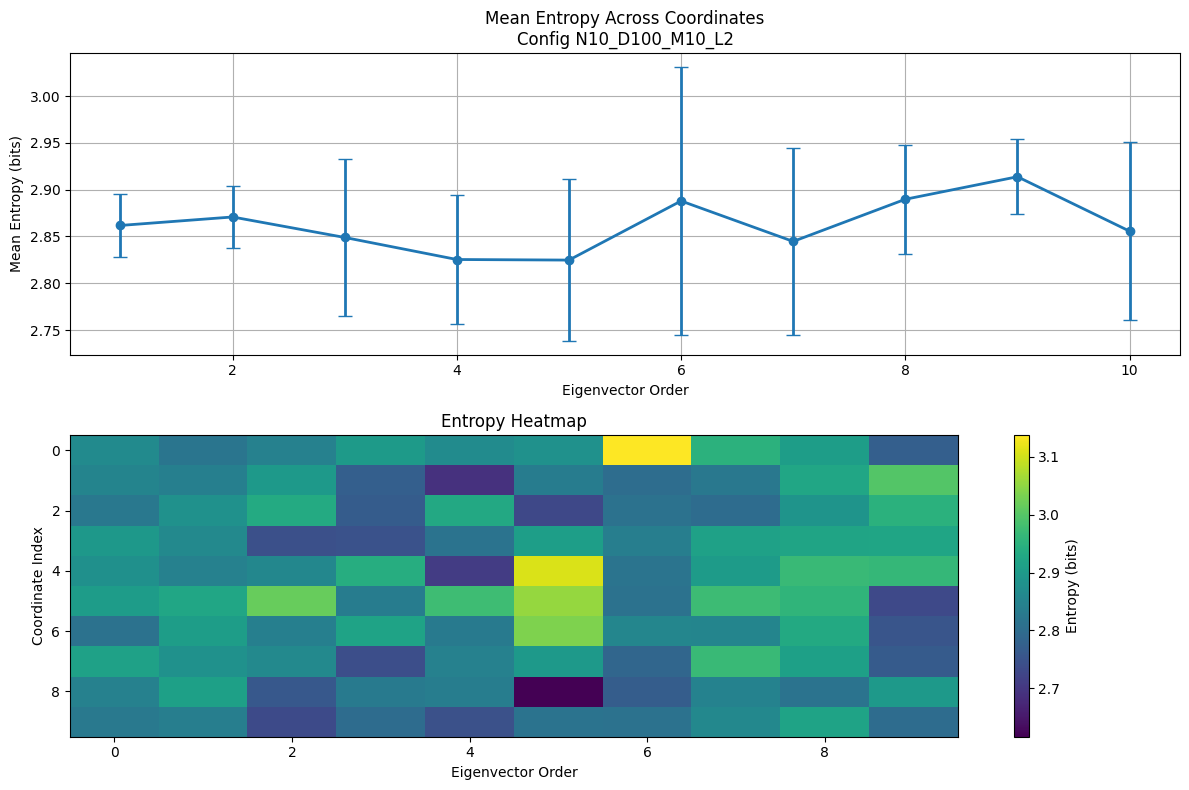

Processing experiment files:  85%|████████▍ | 82/97 [00:52<00:07,  1.89it/s]


Entropy Statistics:
  Overall mean entropy: 2.8624 ± 0.0744 bits
  Max entropy: 3.1372 bits
  Min entropy: 2.6164 bits

Most random eigenvector: 9th
  Mean entropy: 2.9139 ± 0.0402 bits

Least random eigenvector: 5th
  Mean entropy: 2.8248 ± 0.0864 bits
Computing entropy for all eigenvector distributions - N16_D50_M20_L2


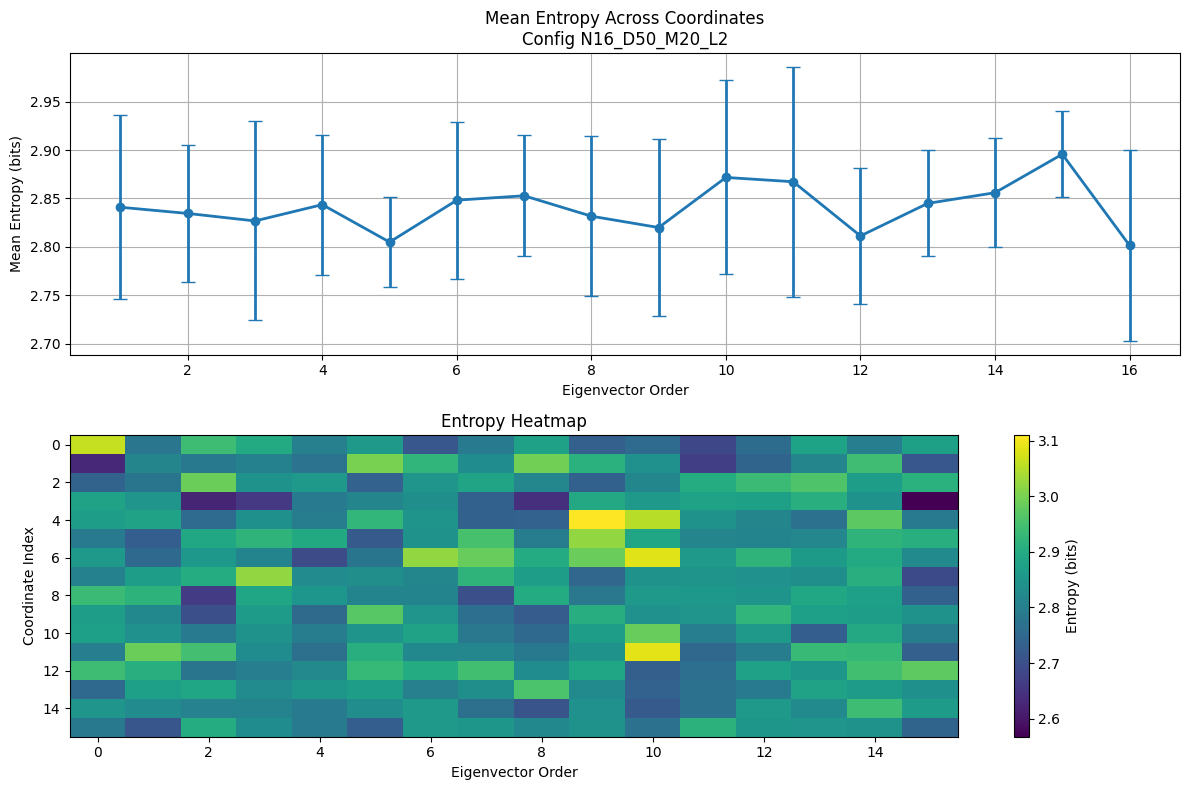

Processing experiment files:  86%|████████▌ | 83/97 [00:53<00:09,  1.46it/s]


Entropy Statistics:
  Overall mean entropy: 2.8408 ± 0.0780 bits
  Max entropy: 3.1097 bits
  Min entropy: 2.5677 bits

Most random eigenvector: 15th
  Mean entropy: 2.8957 ± 0.0445 bits

Least random eigenvector: 16th
  Mean entropy: 2.8015 ± 0.0985 bits
Computing entropy for all eigenvector distributions - N16_D20_M10_L4


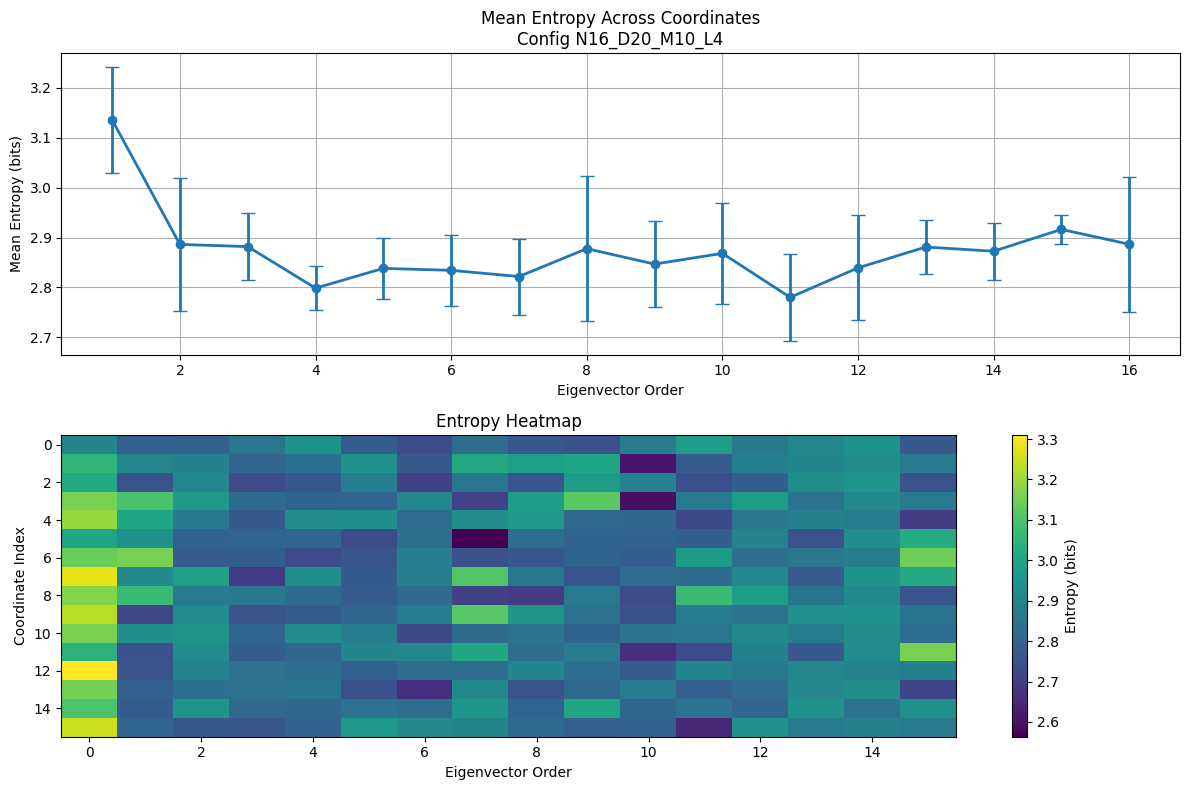

Processing experiment files:  87%|████████▋ | 84/97 [00:54<00:09,  1.31it/s]


Entropy Statistics:
  Overall mean entropy: 2.8728 ± 0.0849 bits
  Max entropy: 3.3095 bits
  Min entropy: 2.5635 bits

Most random eigenvector: 1st
  Mean entropy: 3.1355 ± 0.1063 bits

Least random eigenvector: 11th
  Mean entropy: 2.7803 ± 0.0873 bits
Computing entropy for all eigenvector distributions - N16_D50_M10_L2


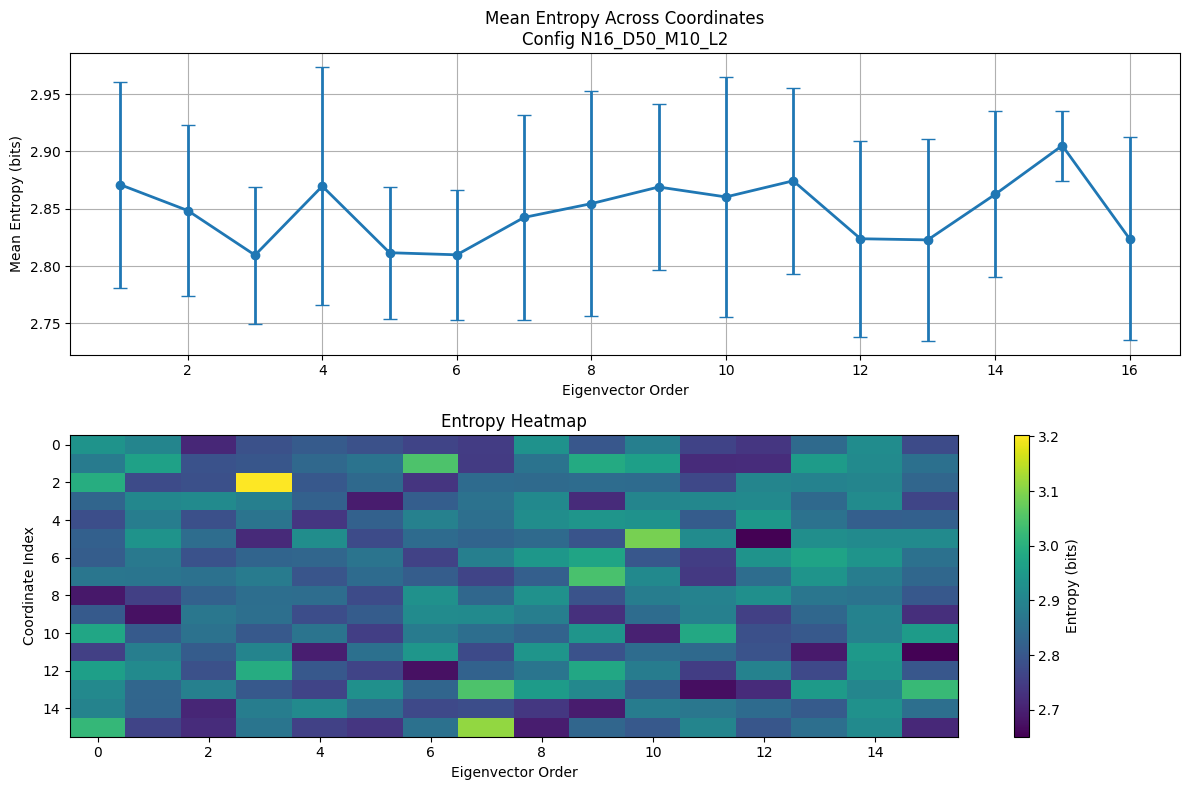

Processing experiment files:  88%|████████▊ | 85/97 [00:55<00:10,  1.16it/s]


Entropy Statistics:
  Overall mean entropy: 2.8474 ± 0.0784 bits
  Max entropy: 3.2023 bits
  Min entropy: 2.6507 bits

Most random eigenvector: 15th
  Mean entropy: 2.9052 ± 0.0306 bits

Least random eigenvector: 3rd
  Mean entropy: 2.8095 ± 0.0598 bits
Computing entropy for all eigenvector distributions - N16_D20_M20_L4


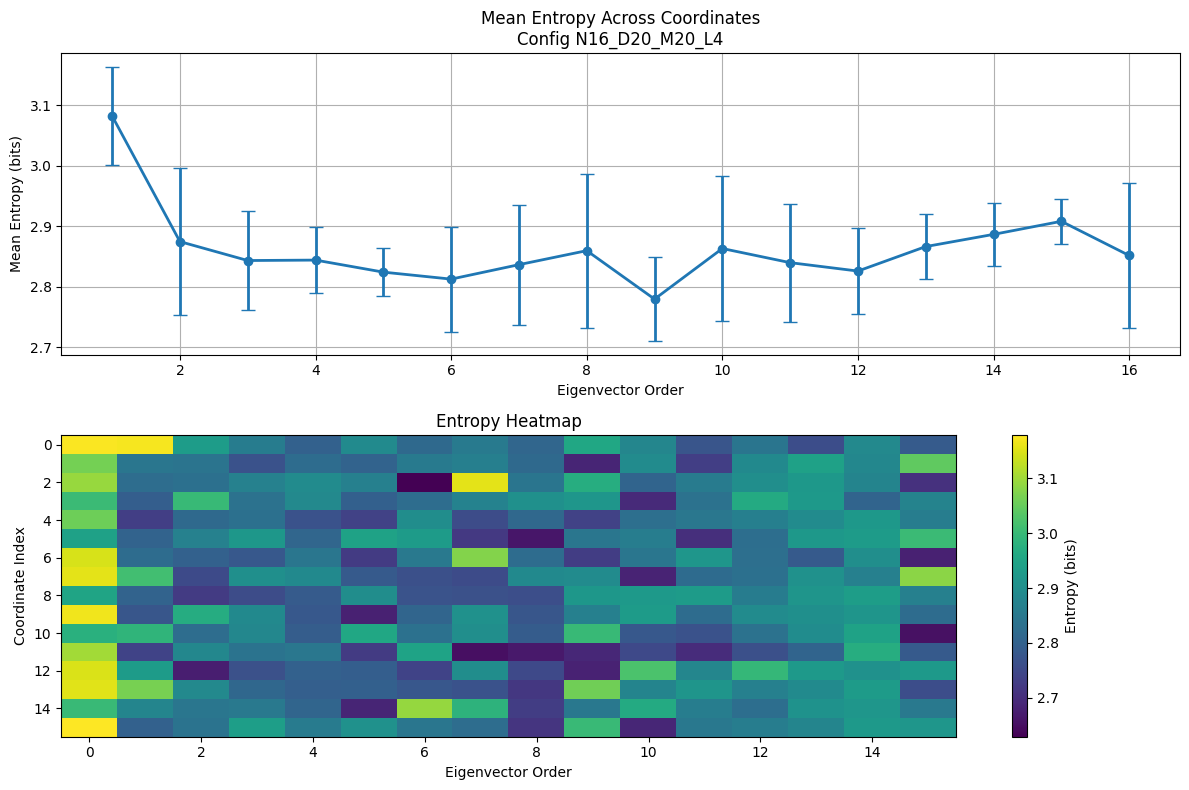

Processing experiment files:  89%|████████▊ | 86/97 [00:56<00:09,  1.12it/s]


Entropy Statistics:
  Overall mean entropy: 2.8623 ± 0.0822 bits
  Max entropy: 3.1785 bits
  Min entropy: 2.6290 bits

Most random eigenvector: 1st
  Mean entropy: 3.0822 ± 0.0813 bits

Least random eigenvector: 9th
  Mean entropy: 2.7794 ± 0.0692 bits
Computing entropy for all eigenvector distributions - N16_D20_M10_L2


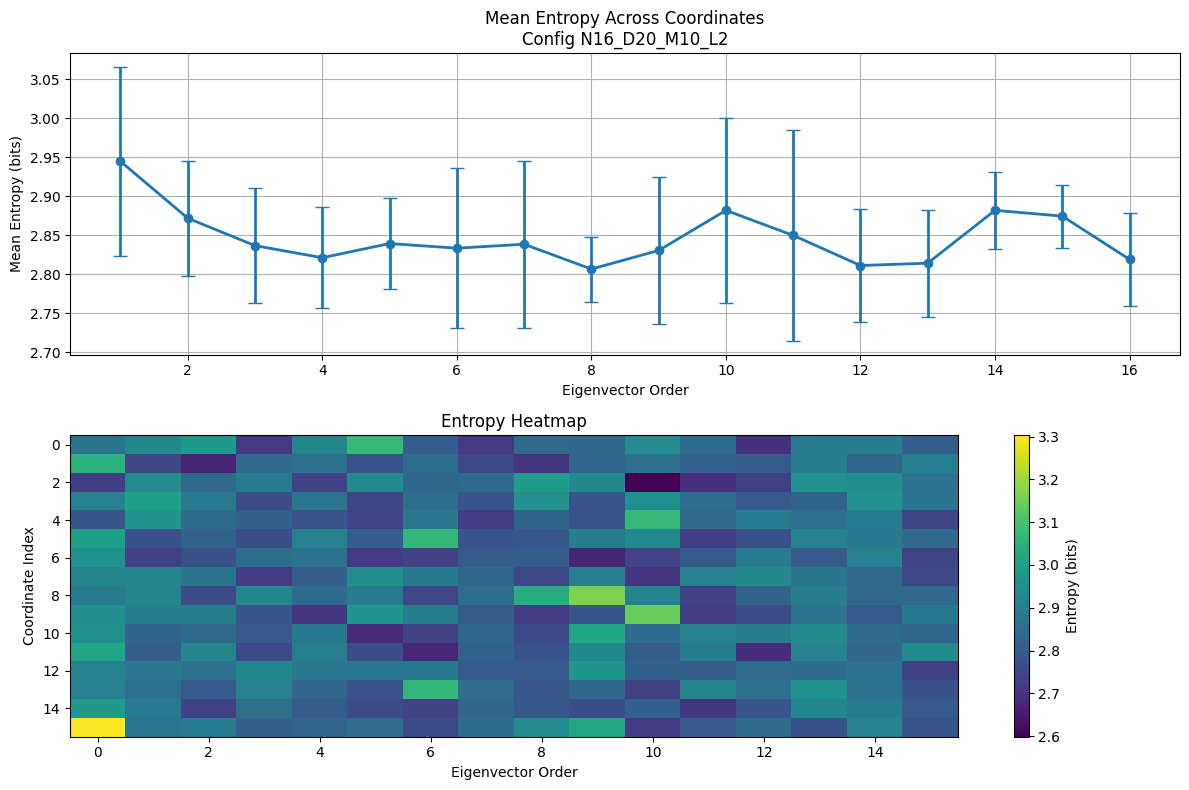

Processing experiment files:  90%|████████▉ | 87/97 [00:57<00:09,  1.03it/s]


Entropy Statistics:
  Overall mean entropy: 2.8472 ± 0.0801 bits
  Max entropy: 3.3030 bits
  Min entropy: 2.5986 bits

Most random eigenvector: 1st
  Mean entropy: 2.9447 ± 0.1211 bits

Least random eigenvector: 8th
  Mean entropy: 2.8066 ± 0.0417 bits
Computing entropy for all eigenvector distributions - N16_D50_M10_L4


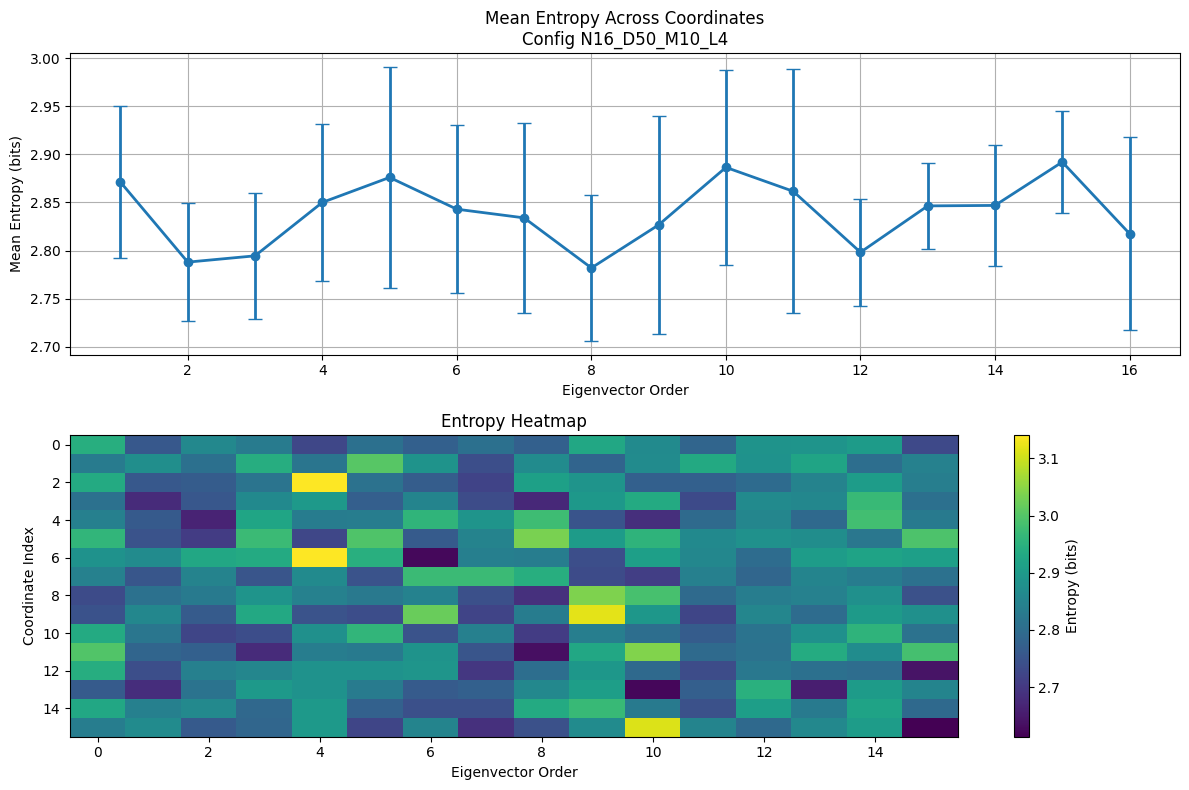

Processing experiment files:  91%|█████████ | 88/97 [00:59<00:09,  1.10s/it]


Entropy Statistics:
  Overall mean entropy: 2.8384 ± 0.0826 bits
  Max entropy: 3.1407 bits
  Min entropy: 2.6132 bits

Most random eigenvector: 15th
  Mean entropy: 2.8920 ± 0.0530 bits

Least random eigenvector: 8th
  Mean entropy: 2.7820 ± 0.0758 bits
Computing entropy for all eigenvector distributions - N16_D20_M10_L6


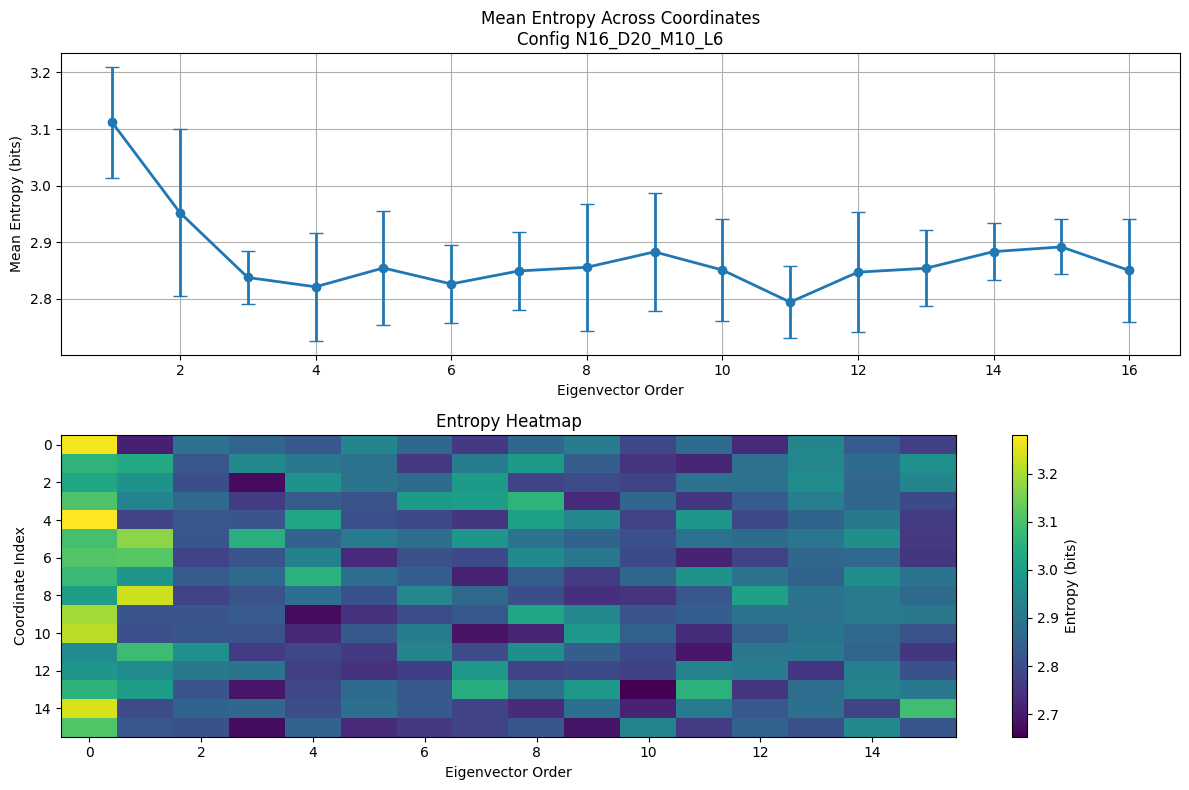

Processing experiment files:  92%|█████████▏| 89/97 [01:00<00:08,  1.10s/it]


Entropy Statistics:
  Overall mean entropy: 2.8728 ± 0.0849 bits
  Max entropy: 3.2797 bits
  Min entropy: 2.6533 bits

Most random eigenvector: 1st
  Mean entropy: 3.1117 ± 0.0981 bits

Least random eigenvector: 11th
  Mean entropy: 2.7942 ± 0.0634 bits
Computing entropy for all eigenvector distributions - N16_D20_M50_L2


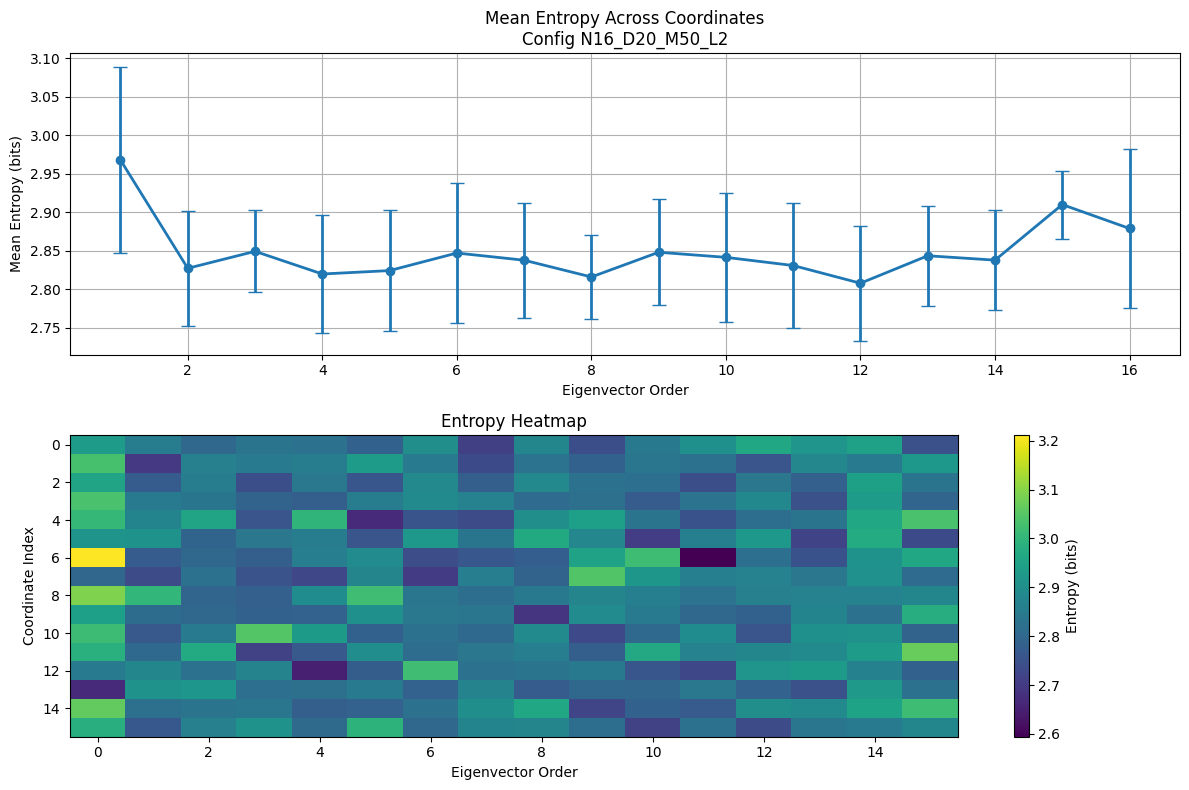

Processing experiment files:  93%|█████████▎| 90/97 [01:01<00:07,  1.05s/it]


Entropy Statistics:
  Overall mean entropy: 2.8489 ± 0.0757 bits
  Max entropy: 3.2112 bits
  Min entropy: 2.5944 bits

Most random eigenvector: 1st
  Mean entropy: 2.9675 ± 0.1210 bits

Least random eigenvector: 12th
  Mean entropy: 2.8075 ± 0.0749 bits
Computing entropy for all eigenvector distributions - N16_D100_M10_L2


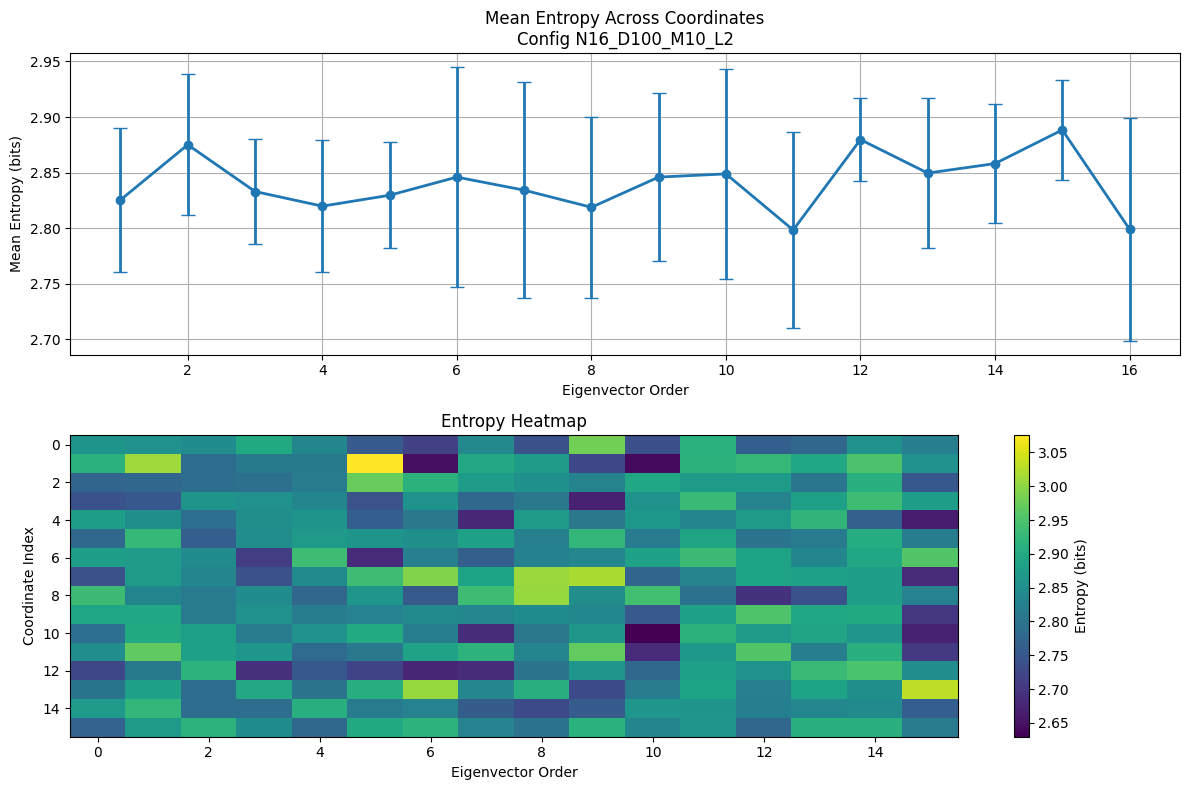

Processing experiment files:  94%|█████████▍| 91/97 [01:02<00:06,  1.04s/it]


Entropy Statistics:
  Overall mean entropy: 2.8406 ± 0.0701 bits
  Max entropy: 3.0754 bits
  Min entropy: 2.6296 bits

Most random eigenvector: 15th
  Mean entropy: 2.8884 ± 0.0451 bits

Least random eigenvector: 11th
  Mean entropy: 2.7983 ± 0.0883 bits
Computing entropy for all eigenvector distributions - N16_D20_M20_L2


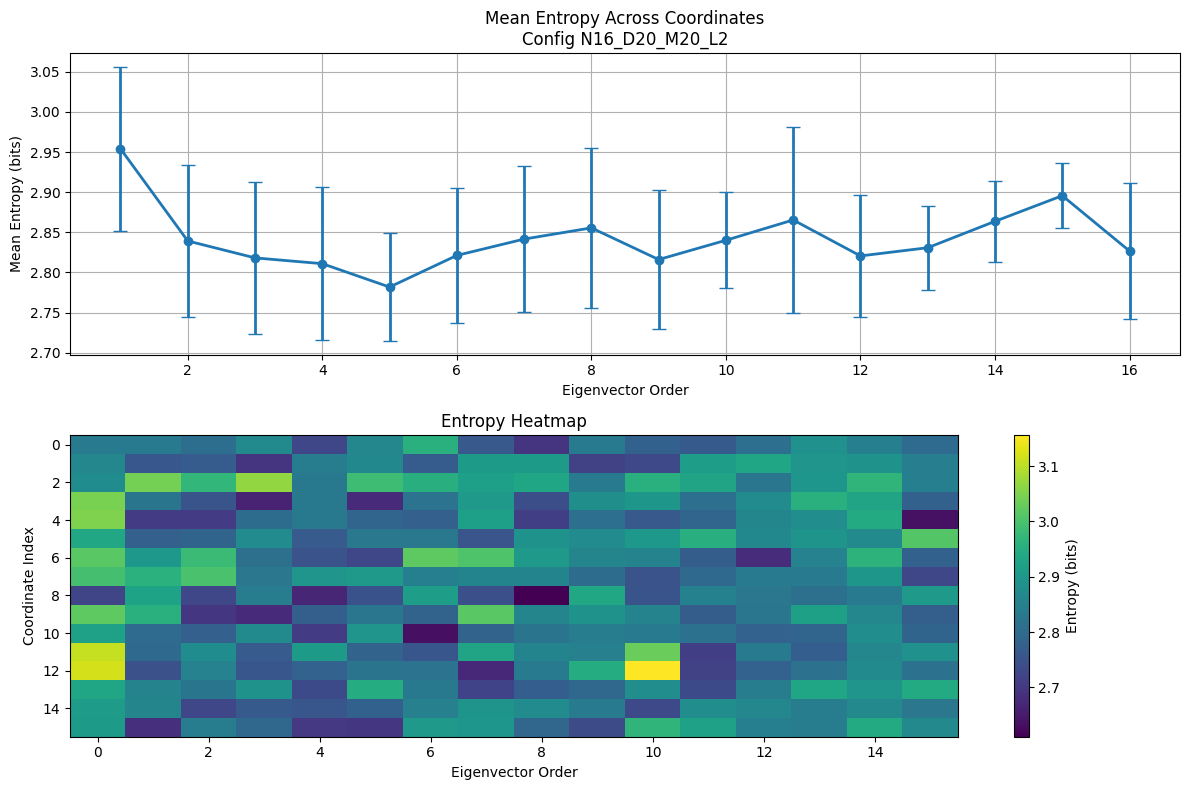

Processing experiment files:  95%|█████████▍| 92/97 [01:03<00:05,  1.04s/it]


Entropy Statistics:
  Overall mean entropy: 2.8425 ± 0.0810 bits
  Max entropy: 3.1559 bits
  Min entropy: 2.6106 bits

Most random eigenvector: 1st
  Mean entropy: 2.9541 ± 0.1020 bits

Least random eigenvector: 5th
  Mean entropy: 2.7817 ± 0.0671 bits
Computing entropy for all eigenvector distributions - N25_D50_M10_L2


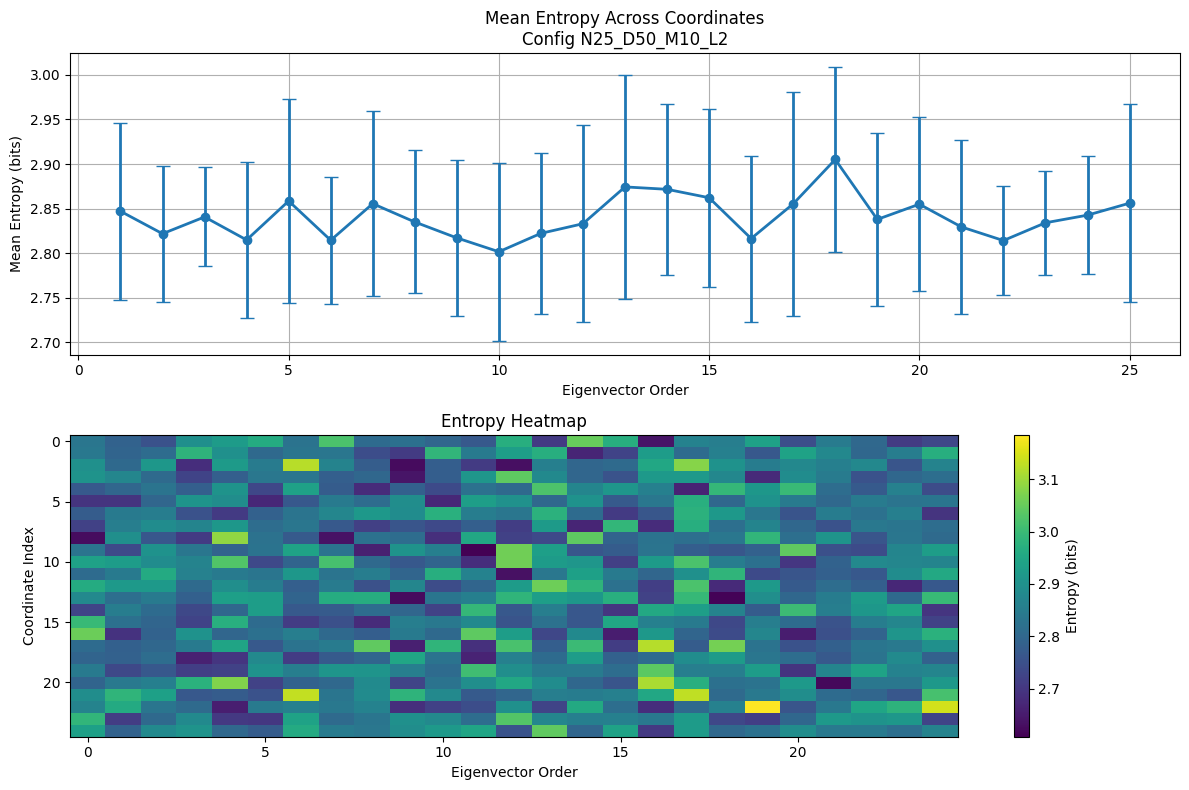

Processing experiment files:  96%|█████████▌| 93/97 [01:05<00:05,  1.31s/it]


Entropy Statistics:
  Overall mean entropy: 2.8405 ± 0.0925 bits
  Max entropy: 3.1839 bits
  Min entropy: 2.6080 bits

Most random eigenvector: 18th
  Mean entropy: 2.9051 ± 0.1040 bits

Least random eigenvector: 10th
  Mean entropy: 2.8014 ± 0.1002 bits
Computing entropy for all eigenvector distributions - N25_D20_M10_L2


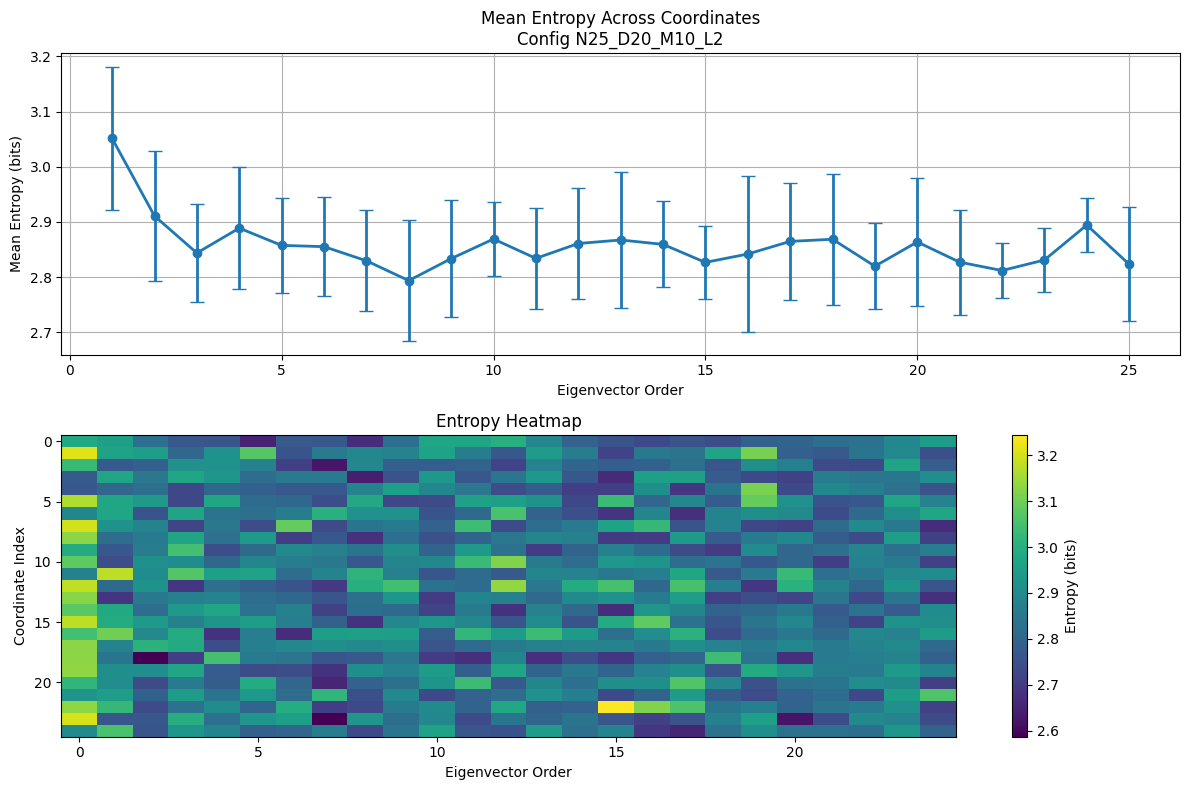

Processing experiment files:  97%|█████████▋| 94/97 [01:06<00:04,  1.42s/it]


Entropy Statistics:
  Overall mean entropy: 2.8572 ± 0.0947 bits
  Max entropy: 3.2437 bits
  Min entropy: 2.5867 bits

Most random eigenvector: 1st
  Mean entropy: 3.0513 ± 0.1297 bits

Least random eigenvector: 8th
  Mean entropy: 2.7939 ± 0.1092 bits
Computing entropy for all eigenvector distributions - N25_D20_M10_L4


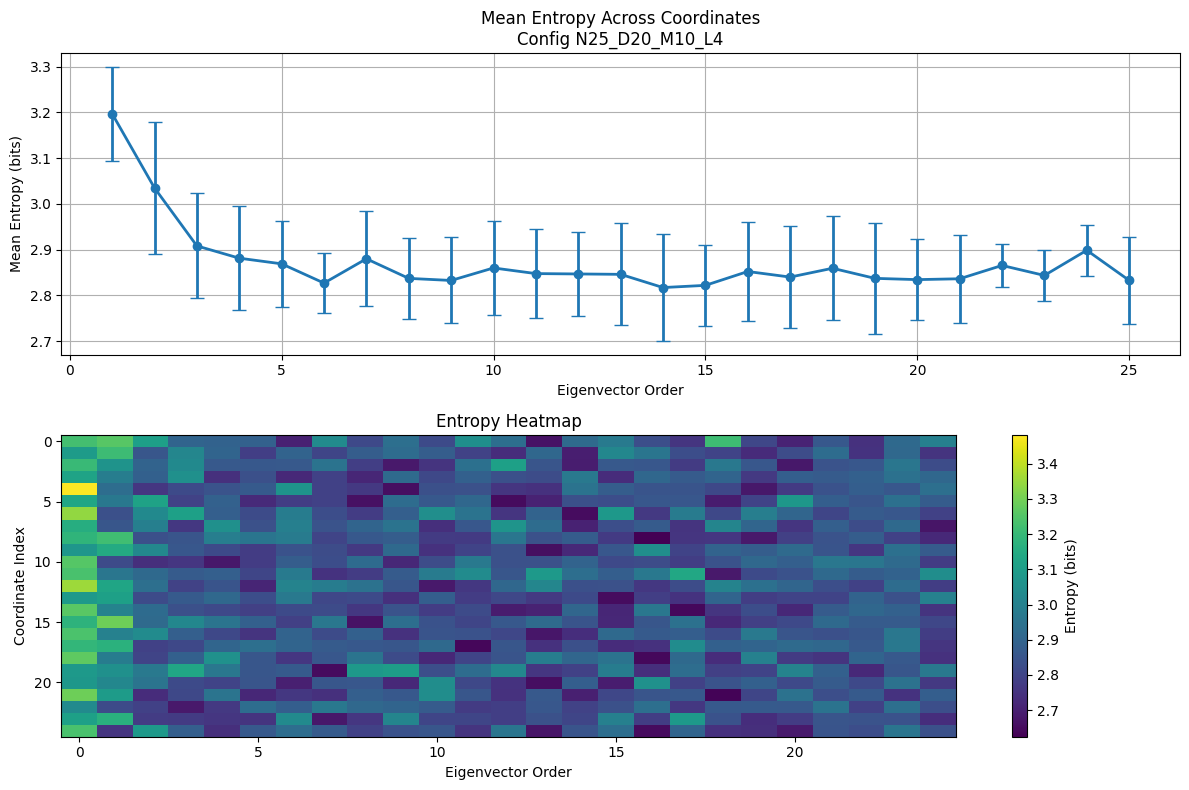

Processing experiment files:  98%|█████████▊| 95/97 [01:08<00:02,  1.47s/it]


Entropy Statistics:
  Overall mean entropy: 2.8721 ± 0.0969 bits
  Max entropy: 3.4804 bits
  Min entropy: 2.6248 bits

Most random eigenvector: 1st
  Mean entropy: 3.1969 ± 0.1024 bits

Least random eigenvector: 14th
  Mean entropy: 2.8170 ± 0.1166 bits
Computing entropy for all eigenvector distributions - N25_D20_M20_L2


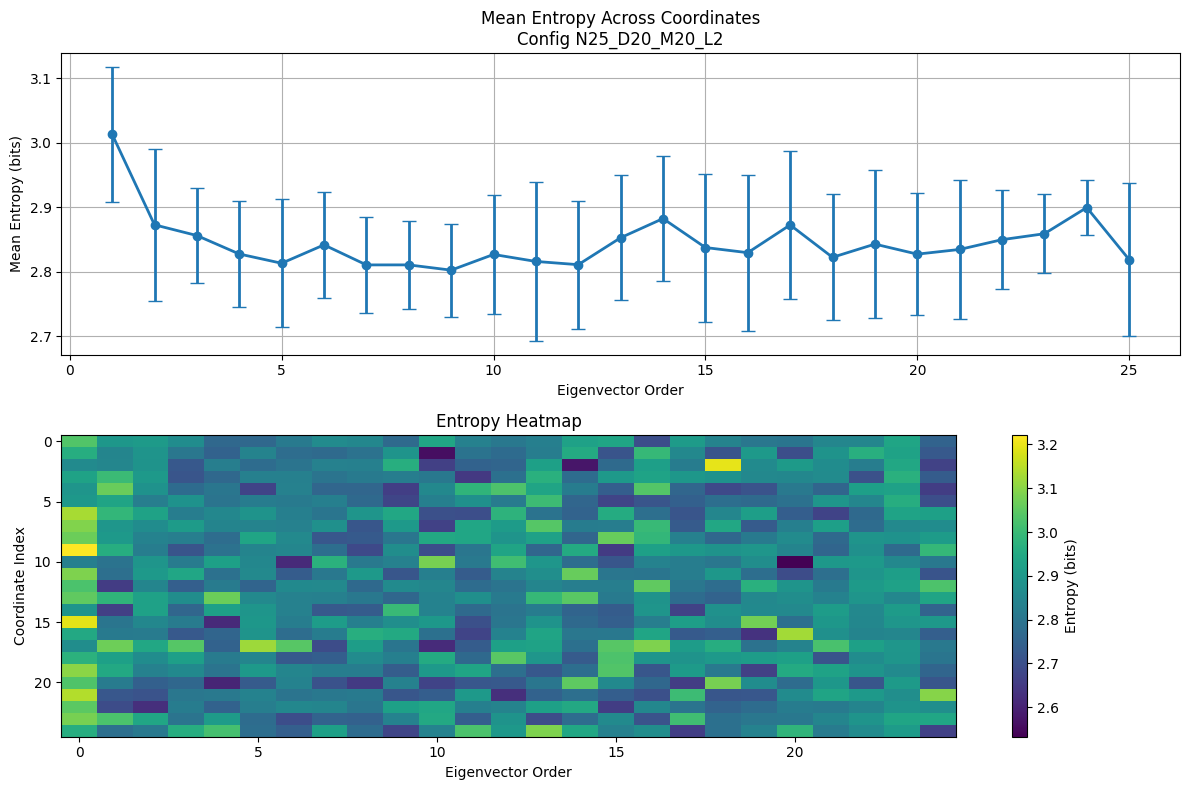

Processing experiment files:  99%|█████████▉| 96/97 [01:09<00:01,  1.43s/it]


Entropy Statistics:
  Overall mean entropy: 2.8450 ± 0.0939 bits
  Max entropy: 3.2210 bits
  Min entropy: 2.5328 bits

Most random eigenvector: 1st
  Mean entropy: 3.0130 ± 0.1045 bits

Least random eigenvector: 9th
  Mean entropy: 2.8022 ± 0.0719 bits
Computing entropy for all eigenvector distributions - N32_D20_M10_L2


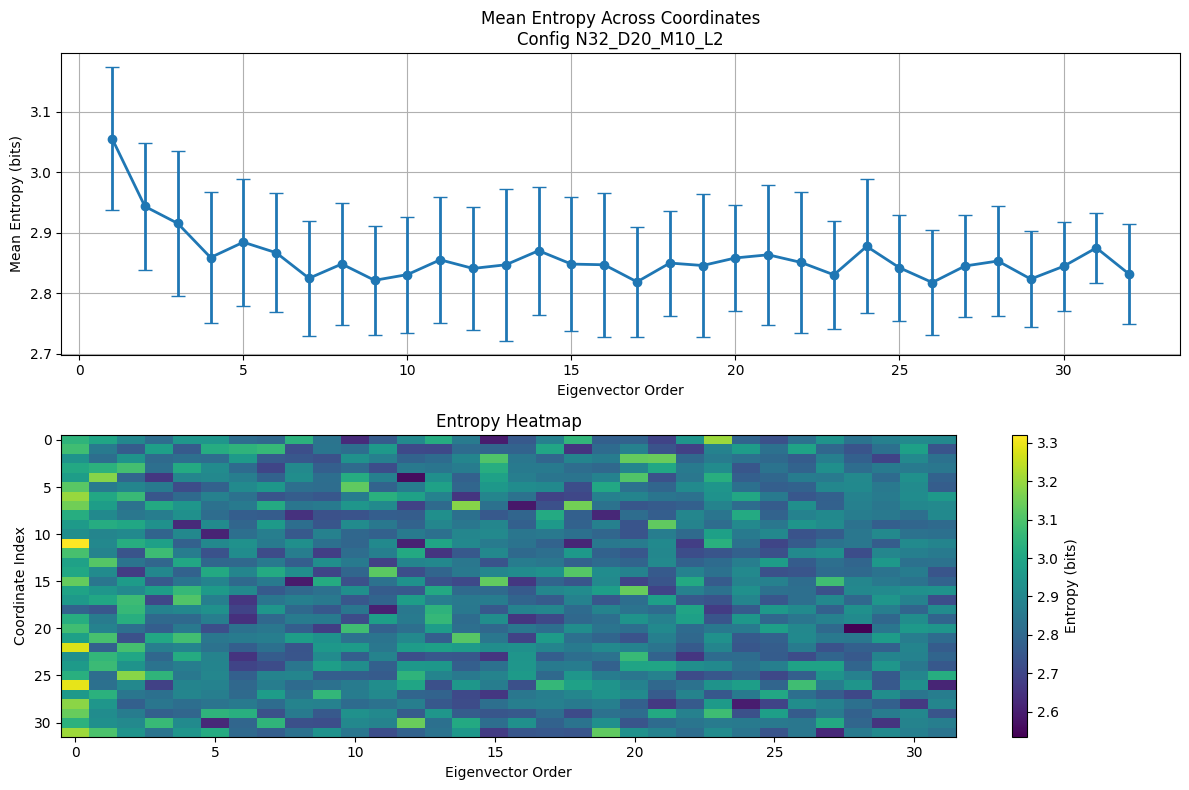

Processing experiment files: 100%|██████████| 97/97 [01:11<00:00,  1.35it/s]


Entropy Statistics:
  Overall mean entropy: 2.8592 ± 0.0986 bits
  Max entropy: 3.3195 bits
  Min entropy: 2.5349 bits

Most random eigenvector: 1st
  Mean entropy: 3.0555 ± 0.1186 bits

Least random eigenvector: 26th
  Mean entropy: 2.8180 ± 0.0864 bits
All eigenvectors analysis complete: coordinates, Gram matrix, last coordinate property, and inverse analysis!


In [ ]:
if __name__ == "__main__":
    # we process all files in the vectors directory
    files = [f for f in os.listdir(os.path.join(PATH_TO_DATA, "vectors")) if f.startswith('ntk_eigenvectors_')]
    
    # we sort files by N
    files = sorted(files, key=lambda x: get_config_from_filename(x)[0])
    
    files = files  # we process only the first file for testing
    print("Processing all experiment files for all eigenvectors coordinate analysis...")
    print("=" * 80)
    
    for file in tqdm(files, desc="Processing experiment files"):
        try:
            # we extract configuration from filename
            N, D_IN, M, L = get_config_from_filename(file)
            
            # we load eigenvectors data
            _, eigenvectors_data = load_experiment_data(N, D_IN, M, L)
            
            # we analyze coordinate distributions for all eigenvectors
            analyze_entropy(
                eigenvectors_data['eigenvectors'].transpose(0, 2, 1), N, D_IN, M, L, PATH_TO_PLOTS
            )
            
        except Exception as e:
            print(f"Error processing {file}: {e}")
    
    print("All eigenvectors analysis complete: coordinates, Gram matrix, last coordinate property, and inverse analysis!")